# **CASO 3 — CREDIT RISK SCORING (FINANZAS)**



**Integrantes del grupo: GATOBYTE**


*   Ivonne Micaela Colque Murillo
*   Adriana Nathalie Rocha Vedia

*   Tania Morelia Pérez Dick
*   Ignacio Retamozo Torrez
*   Dilan Obed Mamani Pamuri

# **ENTENDIMIENTO DEL NEGOCIO**


**Contexto del Caso**


El análisis de riesgo crediticio es una de las tareas más importantes dentro del sector financiero, ya que permite a las entidades evaluar la probabilidad de que un cliente cumpla o no con sus obligaciones de pago. Cuando una institución financiera otorga tarjetas de crédito, asume un riesgo asociado al comportamiento futuro de los clientes. Si este riesgo no se gestiona adecuadamente, puede generar pérdidas económicas debido al incumplimiento de pagos o a una mala estimación del flujo de dinero que los clientes devolverán al banco.

Por esta razón, muchas instituciones utilizan técnicas de análisis de datos y aprendizaje automático para anticipar el comportamiento financiero de los clientes y mejorar la toma de decisiones.

En este contexto, el presente caso de estudio utiliza un dataset proveniente de clientes de tarjetas de crédito en Taiwán durante el año 2005, el cual contiene aproximadamente 30,000 registros. Este conjunto de datos incluye información demográfica, financiera y de comportamiento de pago de los clientes, lo que permite analizar factores que pueden influir en su comportamiento financiero, como el límite de crédito, el historial de pagos y otras características relacionadas con el uso de la tarjeta.

Entre las principales variables del dataset se encuentran:

- LIMIT_BAL: límite de crédito otorgado al cliente

- SEX: sexo del cliente

- EDUCATION: nivel educativo

- MARRIAGE: estado civil

- AGE: edad del cliente

- PAY_0 a PAY_6: historial de pagos en meses anteriores

- BILL_AMT1 a BILL_AMT6: montos facturados en meses anteriores

- PAY_AMT1 a PAY_AMT6: montos pagados en meses anteriores

Estas variables permiten caracterizar el comportamiento financiero de los clientes y analizar patrones asociados al cumplimiento o incumplimiento de pagos.

**Objetivo del caso**

A partir de este conjunto de datos se plantean dos problemas analíticos complementarios.

El primer problema consiste en estimar el flujo de pago futuro del cliente, es decir, predecir cuánto pagará un cliente el próximo mes. En este caso se plantea un problema de regresión, donde la variable objetivo es PAY_AMT.

El segundo problema consiste en anticipar la probabilidad de incumplimiento de pago en el siguiente mes, lo cual corresponde a un problema de clasificación binaria. En este caso la variable objetivo es default.payment.next.month, donde:

- 1 indica que el cliente entra en default (incumplimiento de pago)

- 0 indica que el cliente no presenta incumplimiento

El objetivo general del proyecto es evaluar distintos modelos de Machine Learning que permitan identificar patrones en el comportamiento financiero de los clientes y mejorar la capacidad de predicción del riesgo crediticio.

**Link de dataset:** https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


# **1. Cargado de Librerias y Dataset**

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb
sb.set_style("darkgrid")
sb.set(style="white")
sb.set(style="whitegrid", color_codes=True)

import numpy as np

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn import preprocessing
from scipy import stats
from pandas import Series, DataFrame
from pandas.plotting import autocorrelation_plot
#from pandas.tools.plotting import scatter_matrix
from pylab import rcParams
from matplotlib import collections as collections
from matplotlib.patches import Rectangle
from itertools import cycle

import warnings
warnings.filterwarnings('ignore')

rcParams['figure.figsize'] = 5,4
#sb.set_style('whitegrid')
from numpy import median
from numpy import mean

#Semilla
np.random.seed(42)

**NOTA:** Se procede a hacer la preparación del entorno, la importación de las libreriías y asignar una semilla, ello con el fin de hacer que el modelo sea reprocucible.

In [4]:
import zipfile
import urllib.request
from pathlib import Path

URL_DATOS = "https://archive.ics.uci.edu/static/public/350/default%2Bof%2Bcredit%2Bcard%2Bclients.zip"

def cargar_datos_credito(ruta_base: str | Path = "datasets") -> pd.DataFrame:
    ruta_base = Path(ruta_base)
    ruta_zip = ruta_base / "credit_risk.zip"
    ruta_extraida = ruta_base / "credit_risk"

    # 1) Descargar si no existe
    if not ruta_zip.is_file():
        ruta_base.mkdir(parents=True, exist_ok=True)
        print("Descargando datos desde UCI...")
        urllib.request.urlretrieve(URL_DATOS, ruta_zip)
        print("Descarga completada.")

    # 2) Extraer si no existe la carpeta extraída
    if not ruta_extraida.is_dir():
        print("Extrayendo archivos...")
        with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
            zip_ref.extractall(ruta_extraida)
        print("Extracción completada.")
        # Ver qué archivos se extrajeron
        archivos = list(ruta_extraida.rglob("*"))
        print(f"Archivos encontrados: {[a.name for a in archivos]}")

    # 3) Buscar y cargar el XLS/XLSX (UCI lo entrega en Excel)
    archivos_excel = list(ruta_extraida.rglob("*.xls*"))
    if not archivos_excel:
        raise FileNotFoundError(f"No se encontró archivo Excel en {ruta_extraida}")

    ruta_excel = archivos_excel[0]
    print(f"Cargando: {ruta_excel.name}")

    # El dataset tiene la fila 0 como descripción y fila 1 como header real
    df = pd.read_excel(ruta_excel, header=1)

    # 4) Limpieza básica de nombres de columnas
    df.columns = df.columns.str.strip()

    # Renombrar columna target para facilidad de uso
    if 'default payment next month' in df.columns:
        df = df.rename(columns={'default payment next month': 'default'})

    return df

df = cargar_datos_credito()

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Descargando datos desde UCI...
Descarga completada.
Extrayendo archivos...
Extracción completada.
Archivos encontrados: ['default of credit card clients.xls']
Cargando: default of credit card clients.xls

Dimensiones del dataset: (30000, 25)
Filas: 30,000 | Columnas: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**NOTA: **Se procede a verificar si es que el dataset fue cargado de manera correcta. Como se puede evidenciar el dataset fue cargado de manera correcta mostrandose así que este cuenta con 30000 filas y 25 features o columnas.

# **2. EDA - Entendimiento de los Datos**

## **2.1. Conteo de variables objetivo**

### **Regresión**

In [5]:
df['PAY_AMT1'].value_counts()

,count
PAY_AMT1,
0,5249
2000,1363
3000,891
5000,698
1500,507
...,...
30700,1
423903,1
40003,1


**NOTA:** Se procede a hacer el conteo de los valores del target de regresión, en este caso el target PAY_AMT1 presenta 7943 valores únicos, lo que confirma su naturaleza continua y la adecuación de un modelo de regresión. Asimismo, como se puede evidenciar existen 5249 registros que tiene el valor de 0, lo que representa que esa cantidad de clientes no realizaron ningún pago ese mes. Esa concentración de ceros sugiere una distribución fuertemente sesgada a la derecha, lo que nos servirá mas adelante para analizar la distribución de esa variable.

### **Clasificación**

In [6]:
df['default'].value_counts()

,count
default,
0,23364
1,6636


**NOTA:** Se procede a hacer el conteo de los valores del target de clasificación, en este caso el target default puede tomar dos valores: 0 (no default) y 1 (default). Como se puede evidenciar se encuentra desbalanceado, es decir, 23364 clientes no entraron en default lo que equivale al 77.9% y 6636 si lo hicieron, el 22.1%. Esta diferencia significativa entre clases sugiere que el modelo podría tender a favorecer a la clase mayoritaria.

## **2.2. Información del Dataset**

In [7]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**NOTA:** Se visualizan los primeros 5 registros del dataset para tener una primera impresión de la estructura de los datos, los tipos de variables y los valores que toman. Asimismo, se puede observar que el dataset contiene variables numéricas enteras
correspondientes a montos de pago, estados de cuenta y características demográficas del cliente.

In [8]:
df.shape

(30000, 25)

**NOTA:** Como se puede evidenciar, el dataset cuenta con 30,000 registros y 25 features (incluyendo las variables objetivo o los targets). Esto representa una muestra suficientemente grande para entrenar modelos de clasificación y regresión.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

**NOTA:** Todas las variables son de tipo entero , lo que indica que no existen variables categóricas. Sin embargo, variables como SEX,
EDUCATION, MARRIAGE y PAY_0 a PAY_6 son categóricas codificadas numéricamente o mapeadas.

In [10]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


**NOTA:** Se analizan las estadísticas descriptivas de las variables numéricas continuas.
Se destacan los siguientes puntos:
- ***LIMIT_BAL***: el límite de crédito varía entre 10,000 y 1,000,000 NTS, con una media de 167484 NTS, lo que sugiere alta variabilidad entre clientes.
- ***BILL_AMT1 a BILL_AMT6***: presentan valores negativos, lo que corresponde a créditos a favor del cliente (pagos en exceso). Esto es válido y no representa un error en los datos.
- ***PAY_AMT1 a PAY_AMT6***: presentan una distribución fuertemente sesgada a la derecha, con valores mínimos de 0 (sin pago) y máximos que superan los 800000 NTS. Esto anticipa la necesidad de escalado en el pipeline.
- **AGE** *texto en cursiva*: los clientes tienen entre 21 y 79 años, con una media de 35 años.

### **Valores faltantes**

In [11]:
df.isna().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


**NOTA:** Verificamos si el dataset se encuentra completo. En este caso, no se detectan valores nulos en ninguna columna, lo que
simplifica la etapa de imputación. Es decir, el dataset se encuentra completo.

### **Verificar filas y columnas repetidas**

In [12]:
print(df.duplicated().sum())

0


**NOTA:** Se verifica si existen filas duplicadas, en este caso, el dataset no presenta filas duplicadas. Por tanto, en el procesamiento no será necesario eliminar filas duplicadas.

In [13]:
print(df.columns.duplicated().sum())

0


**NOTA:** Se verifica si existen columnas duplicadas, en este caso, el dataset no presenta columnas duplicadas. Por tanto, en el procesamiento no será necesario eliminar columnas duplicadas.

## **2.3. Matriz de Correlación**

In [14]:
# Select only numerical features for correlation analysis
numerical_features = df.select_dtypes(include=np.number).columns
irisCorr = df[numerical_features].corr(method='pearson')
irisCorr

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
ID,1.000000,0.026179,0.018497,0.039177,-0.029079,0.018678,-0.030575,-0.011215,-0.018494,-0.002735,...,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
LIMIT_BAL,0.026179,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.018497,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,0.039177,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.029079,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.018678,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.030575,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,...,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.011215,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,...,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.018494,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,...,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.002735,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,...,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614


(25.5, -0.5)

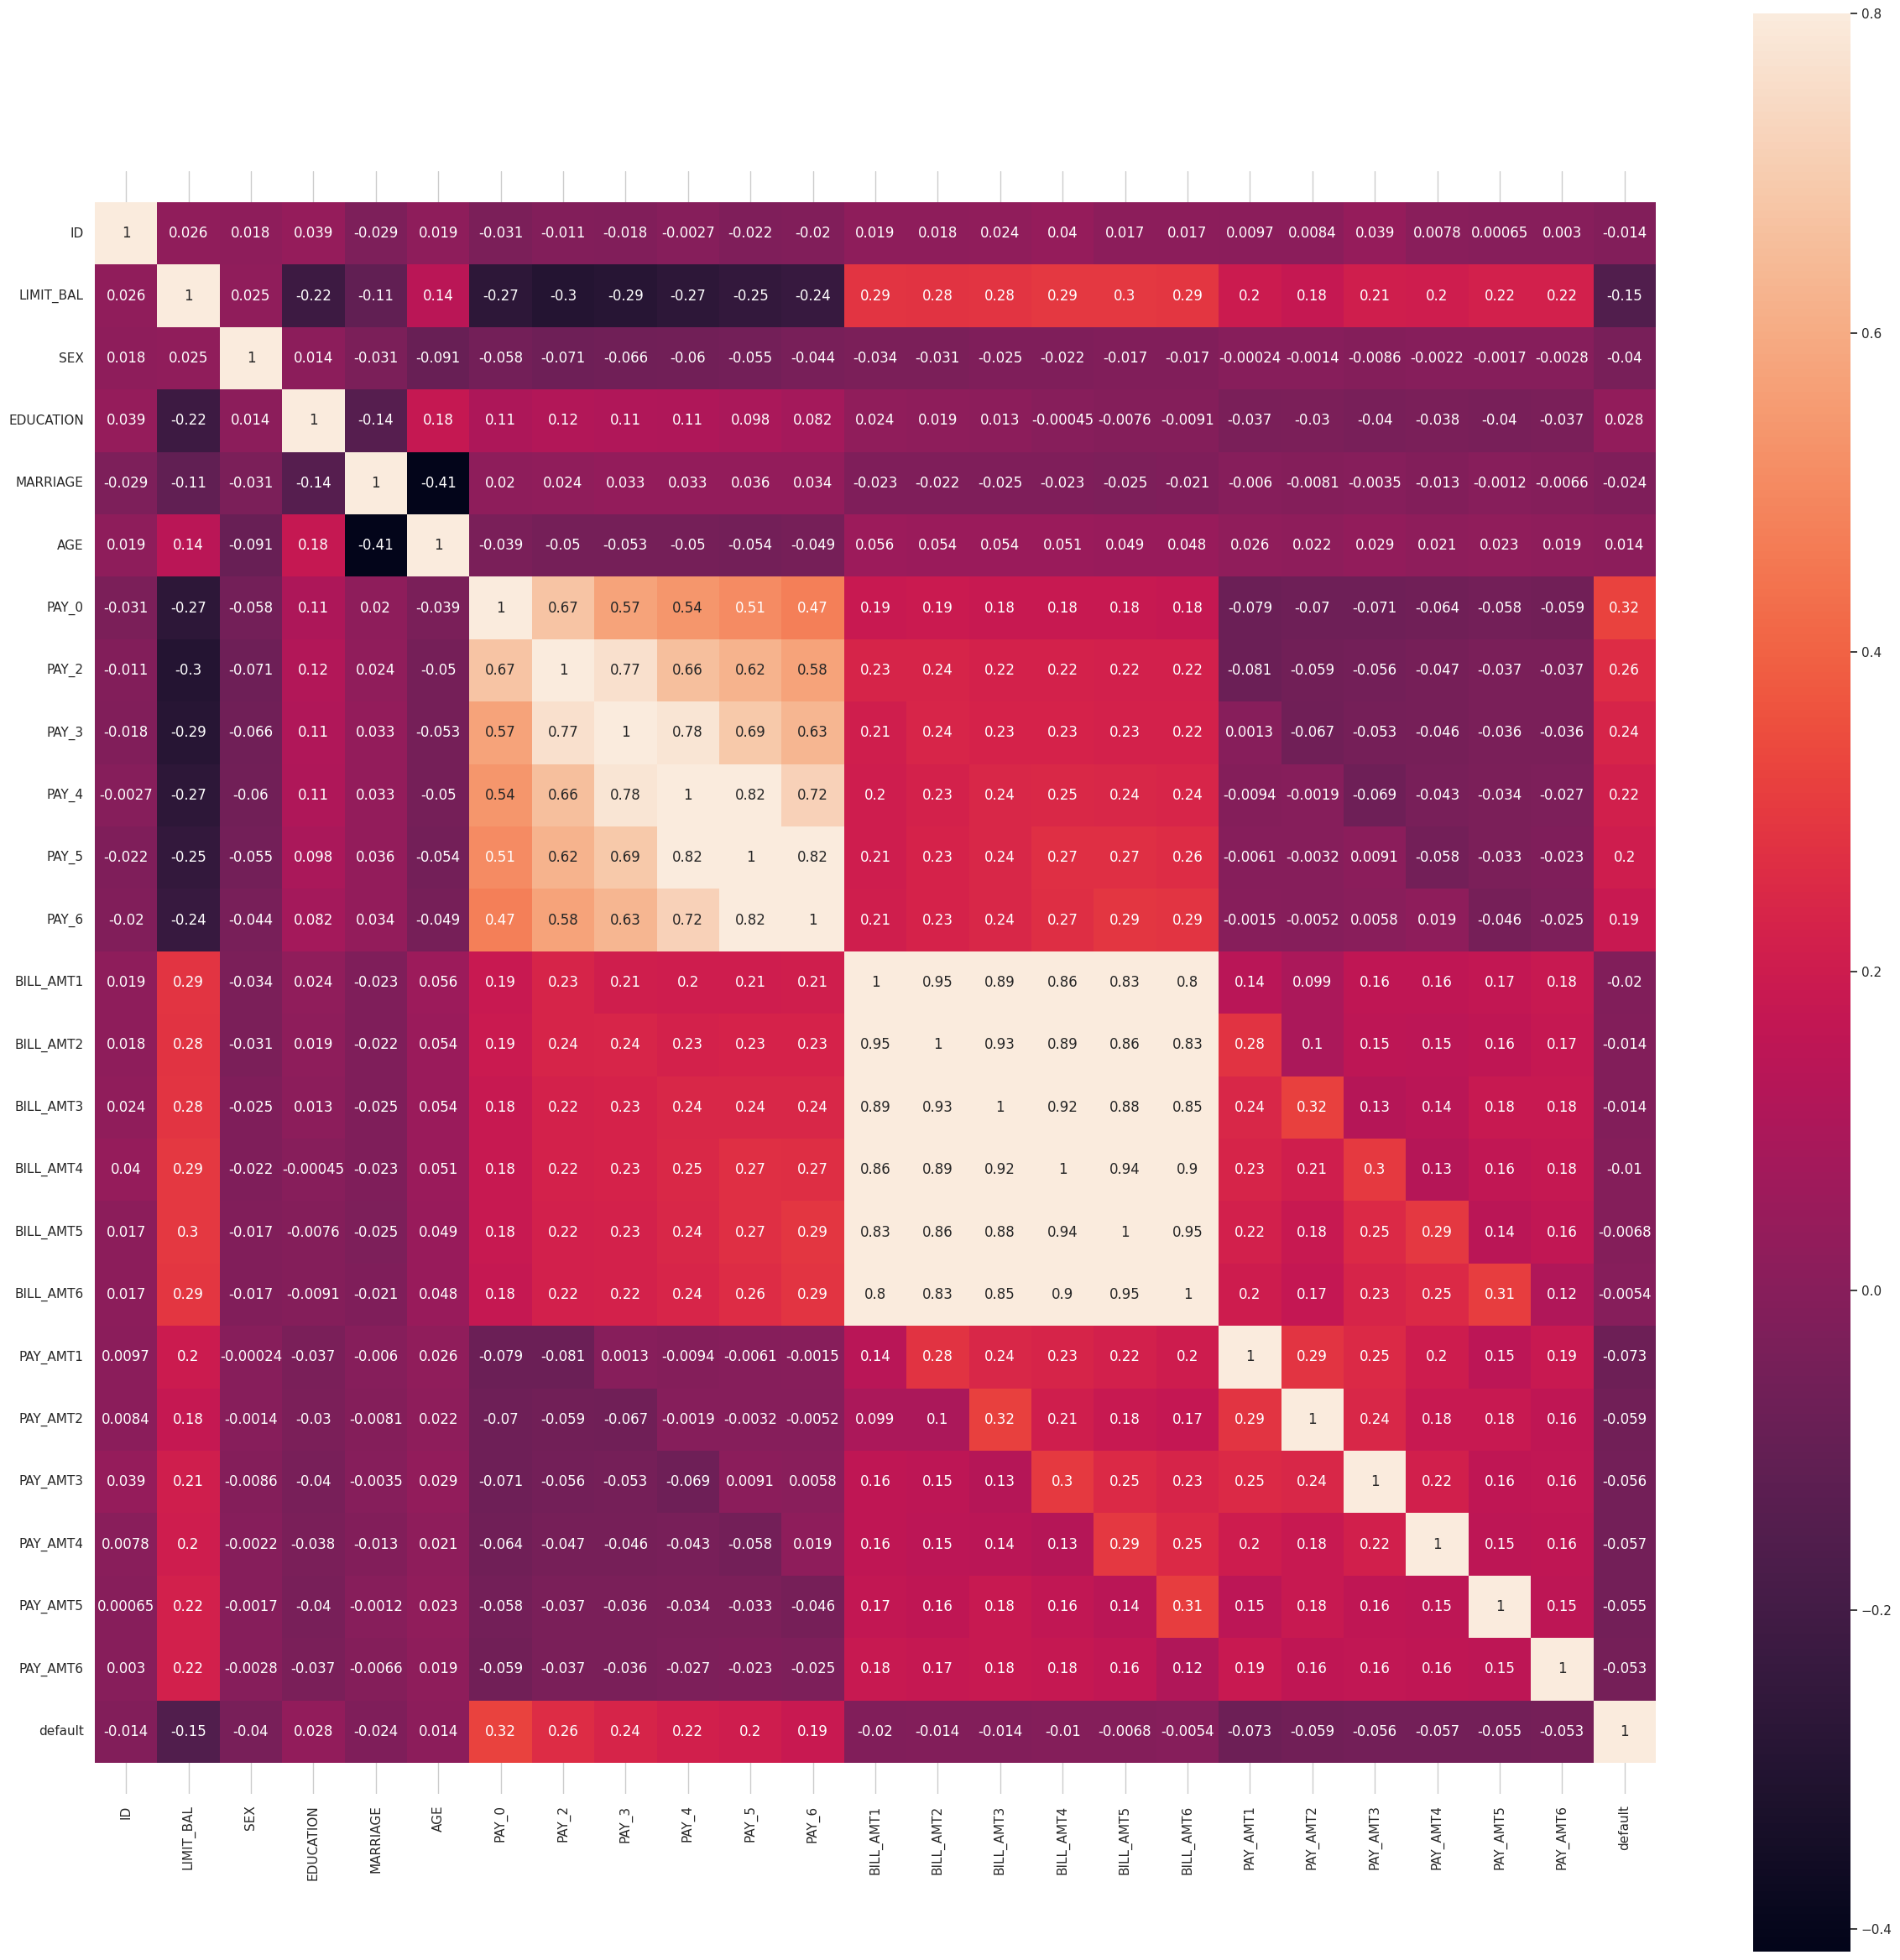

In [15]:
# Correlation
# Select only numerical features for correlation analysis
numerical_features = df.select_dtypes(include=np.number).columns
corrmat = df[numerical_features].corr()

f, ax = plt.subplots(figsize=(30, 30))
ax=sb.heatmap(corrmat, vmax=.8, square=True, annot = True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom+0.5, top-0.5)

**NOTA:** El mapa de calor muestra la correlación entre los features que presenta el dataset. Se observa que la mayoría de las correlaciones son débiles o moderadas, tanto positivas como negativas. Por ejemplo:



**1. Alta multicolinealidad en BILL_AMT (saldos de factura):**
Las variables BILL_AMT1 a BILL_AMT6 presentan correlaciones extremadamente altas
entre sí (entre 0.80 y 0.95), lo que indica que el saldo de un mes es muy
predecible a partir del mes anterior. Esto genera multicolinealidad severa y
justifica el uso de Ridge Regression (L2).

**2. Correlación moderada entre PAY_0 a PAY_6 (historial de pagos):**
Las variables de estado de pago presentan correlaciones moderadas entre sí
(entre 0.47 y 0.82), siendo PAY_0 la que mayor correlación tiene con el
target default (0.32), lo que la convierte en la variable más predictiva
del dataset.

**3. Variables sensibles con baja correlación con el target:**
- SEX: correlación con default = -0.04 (prácticamente nula)
- MARRIAGE: correlación con default = -0.024 (prácticamente nula)
- AGE: correlación con default = 0.014 (prácticamente nula)
Esto sugiere que estas variables tienen muy poco poder predictivo sobre
el default.

**4. LIMIT_BAL con correlación negativa con default (-0.15):**
A mayor límite de crédito, menor probabilidad de default. Esto quiere decir que clientes con mayor límite suelen tener mejor historial crediticio.

**5. ID sin correlación relevante:**
La variable ID presenta correlaciones cercanas a 0 con todas las variables,
confirmando que es un identificador sin valor predictivo y debe ser
eliminado en el preprocesamiento.


## **2.4. Gráficos**

In [16]:
sb.set_style("darkgrid")
sb.set(style="white")
sb.set(style="whitegrid", color_codes=True)


### **ID**

<Axes: xlabel='ID', ylabel='Density'>

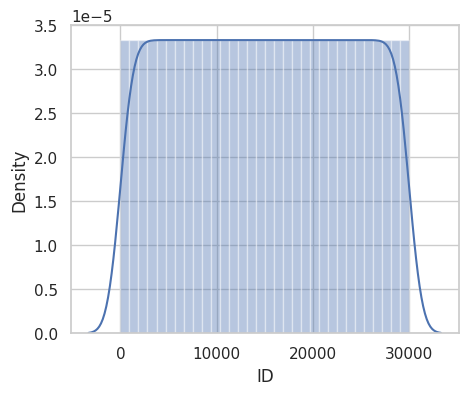

In [17]:
sb.distplot(df['ID'])

**NOTA:** La distribución de la variable ID presenta una distribución uniforme perfecta, con densidad constante de 1 a 30000, lo que confirma que es un identificador secuencial asignado a cada cliente y que no contiene información predictiva sobre el comportamiento de pago. Por tanto, esta variable debe ser eliminada en la etapa de preprocesamiento.

### **LIMIT_BAL**

<Axes: xlabel='LIMIT_BAL', ylabel='Density'>

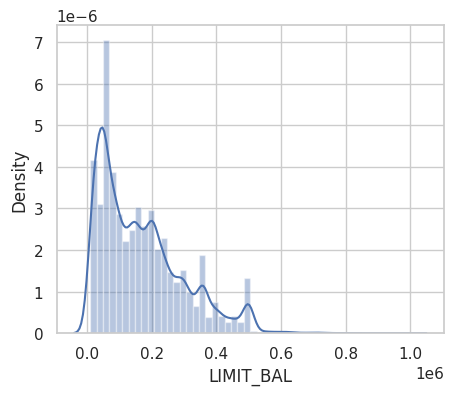

In [18]:
sb.distplot(df['LIMIT_BAL'])

**NOTA:** La variable LIMIT_BAL presenta una distribución sesgada a la derecha, con la mayoría de los clientes concentrados en límites bajos, es decir, entre 10.000 y 100.000 NTS y una cola larga hacia valores altos que llegan hasta 1.000.000 NTS. Asimismo, se observan pequeños picos secundarios alrededor de 200.000 y 500.000 NTS.

Por tanto, según su distribución esta variable requiere StandardScaler en el preprocesamineto, debido a su alta variabilidad y sesgo, ello para evitar que su escala domine el modelo.

### **SEX**

In [19]:
df['SEX'].value_counts()

,count
SEX,
2,18112
1,11888


<Axes: xlabel='SEX', ylabel='Density'>

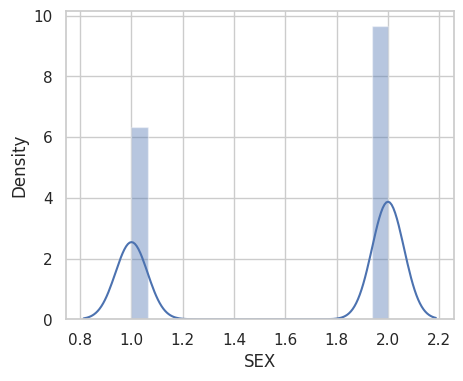

In [20]:
sb.distplot(df['SEX'])

**NOTA:** La variable SEX presenta una distribución bimodal, ya que solo toma dos valores: 1 (hombre) y 2 (mujer). Este comportamiento es característico de las variables categóricas binarias, aunque en este caso está codificada como numérica. La gráfica confirma que existe mayor cantidad de mujeres en el dataset (18.112 a 11.888), lo que indica un desbalance demográfico en el dataset.

**Nota ética**: Dado que la correlación de SEX con el target default es prácticamente nula, -0.04, su inclusión en el modelo no mejora significativamente el poder predictivo pero sí podría introducirriesgo de sesgo de género. Esta variable será evaluada en el análisis con/sin variables sensibles antes de decidir su inclusión final.

### **EDUCATION**

In [21]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


<Axes: xlabel='EDUCATION', ylabel='Density'>

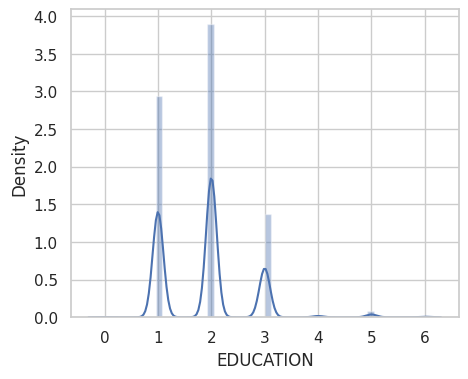

In [22]:
sb.distplot(df['EDUCATION'])

**NOTA:** La variable EDUCATION que esta codificada como 1 (posgrado), 2 (universidad), 3 (secundaria)
y 4 (otros), 5 (desconocido) y 6 (desconocido). En su distribución demuestra que la categoría 2 (universidad) es la más frecuente con 14.030, seguida de la categoría 1 con 10.585 y la categoría 3 con 4917. Asimismo, se detectan valor de 0, 5 y 6 que no  corresponden a categorías válidas según el diccionario de datos original, representando registros con información desconocida o no documentada.

En el preprocesamiento, se deben agrupar los valores de 0, 5 y 6 dentro de la categoría 4, ello con el fin de consolidar todas las categorías no definidas en una sola para poder reducir el ruido en esta variable

### **MARRIAGE**

In [23]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


<Axes: xlabel='MARRIAGE', ylabel='Density'>

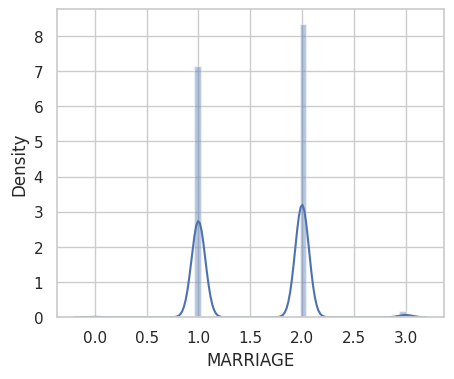

In [24]:
sb.distplot(df['MARRIAGE'])

**NOTA:** La variable MARRIAGE está codificada como como 1 (casado), 2 (soltero) y 3 (otros). Asimismo, la distribución muestra que las categorías 1 y 2 concentran prácticamente todos los registros, siendo la categoría 2 ligeramente mas frecuente que la categoría 1. Lo que quiere decir que existen mas personas solteras que casadas registradas.

**Nota ética**: Al igual que SEX, la correlación de MARRIAGE con el target default es prácticamente nula (-0.024). Su inclusión será evaluada en el análisis de variables sensibles antes de decidir si se incorpora al modelo final.

### **AGE**

In [25]:
df['AGE'].value_counts()

,count
AGE,
29,1605
27,1477
28,1409
30,1395
26,1256
31,1217
25,1186
34,1162
32,1158


<Axes: xlabel='AGE', ylabel='Density'>

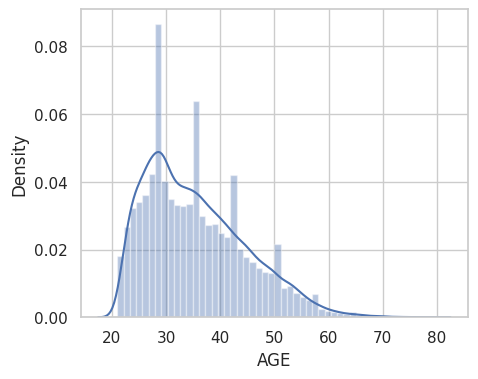

In [26]:
sb.distplot(df['AGE'])

**NOTA:** La variable AGE muestra una distribución normal sesgada a la derecha con concentración principal entre los 25 y 35 años, siendo 29 años el valor mas frecuente (1605 clientes tienen esa edad). La cola se extiende hasta los 79 años con muy pocos registros de personas mayores de 60. Esto refleja que la cartera de clientes del banco es predominantemente joven.

**Nota ética**: AGE tiene correlación prácticamente nula con default (0.014). La discriminación por edad está prohibida en muchos marcosregulatorios, por lo que su inclusión será evaluada cuidadosamenteen el análisis de variables sensibles.

### **PAY_0**

<Axes: xlabel='PAY_0', ylabel='Density'>

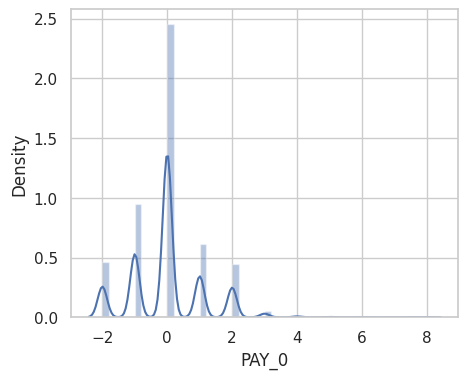

In [27]:
sb.distplot(df['PAY_0'])

**NOTA:** La variable PAY_0 representa el estado de pago del mes más reciente (septiembre 2005), codificado como -2 (sin consumo), -1 (pagó a tiempo), 0 (uso de crédito rotativo) y valores positivos 1-8 que indican meses de retraso en el pago.

La distribución muestra una fuerte concentración en 0 y -1, lo que indica que la mayoría de los clientes pagaron a tiempo o usaron crédito rotativo.
La cola hacia valores positivos (retrasos) es corta pero relevante, ya que como se observó en la matriz de correlación, PAY_0 es la variable con mayor correlación con el target default (0.32)

Asimismo, PAY_0 será tratada como variable categórica
ordinal en el pipeline, dado que sus valores representan niveles de retraso con un orden natural.

### **PAY_2**

<Axes: xlabel='PAY_2', ylabel='Density'>

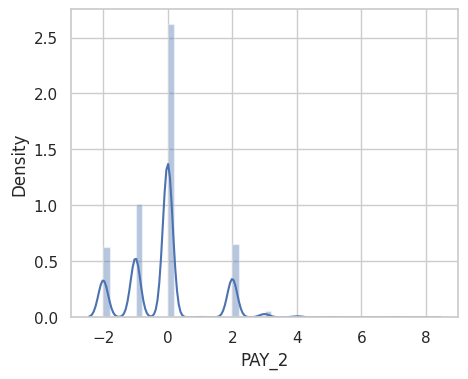

In [28]:
sb.distplot(df['PAY_2'])

### **PAY_3**

<Axes: xlabel='PAY_3', ylabel='Density'>

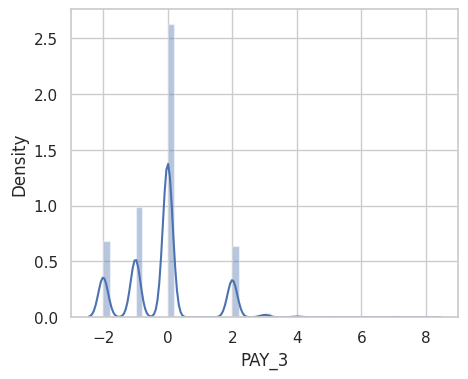

In [29]:
sb.distplot(df['PAY_3'])

### **PAY_4**

<Axes: xlabel='PAY_4', ylabel='Density'>

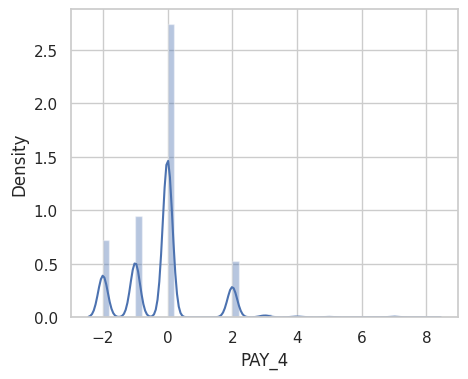

In [30]:
sb.distplot(df['PAY_4'])

### **PAY_5**

<Axes: xlabel='PAY_5', ylabel='Density'>

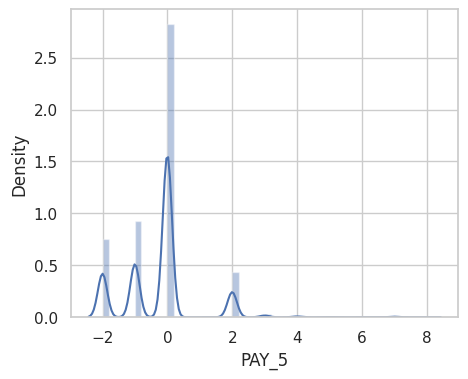

In [31]:
sb.distplot(df['PAY_5'])

### **PAY_6**

<Axes: xlabel='PAY_6', ylabel='Density'>

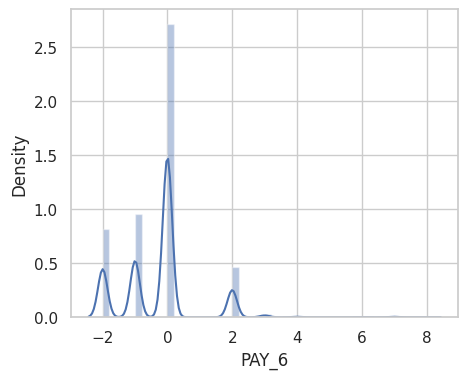

In [32]:
sb.distplot(df['PAY_6'])

**NOTA:** Las variables PAY_2 a PAY_6 representan el estado de pago de los meses anteriores (de abril a agosto de 2005) y presentan distribuciones muy similares a PAY_0, con fuerte concentración en los valores 0 y -1 (pago puntual o crédito rotativo) y colas cortas hacia valores positivos que indican retraso.

A medida que nos alejamos en el tiempo (de PAY_2 a PAY_6), la concentración en valores negativos tiende a aumentar ligeramente, lo que es consistente con el hecho de que clientes que eventualmente entraron en default comenzaron a mostrar señales de retraso en meses más recientes.

Asimismo, todas las variables PAY_0 a PAY_6 serán
tratadas como variables categóricas ordinales en el pipeline.

### **BILL_MT1 a BILL_MT6**

Para poder analizar la distribucion de cada una de las variables de manera mas detallada se realizo historigramas sobre las varibles referidas a BILL_AMT. Ademas, debido a que un objetivo es poder realizar un modelo de clasificacion con el feature default.payment.next.month, para las distribuciones se tendra esto es cuenta.
Se hara la comparacion de las dictruciones de los BILL_AMT donde se marque de un color diferente sobre el resultado de los clientes con incumpliento y los que estan al dia.

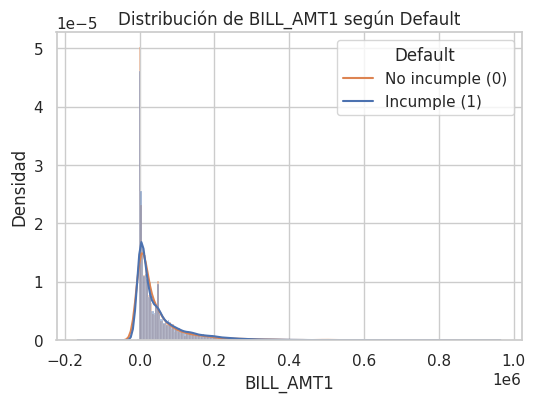

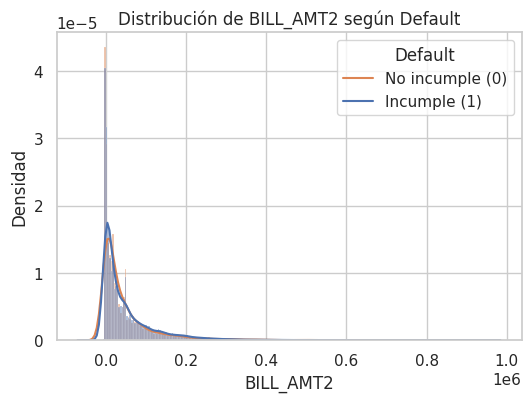

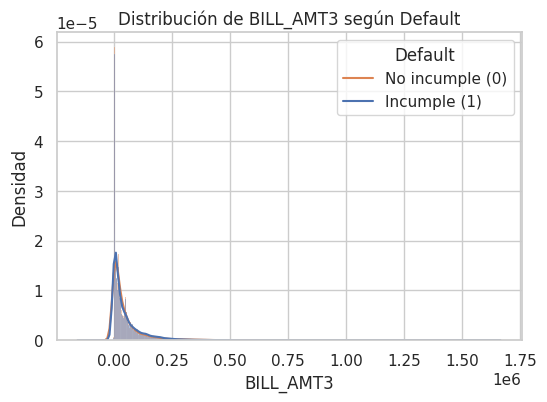

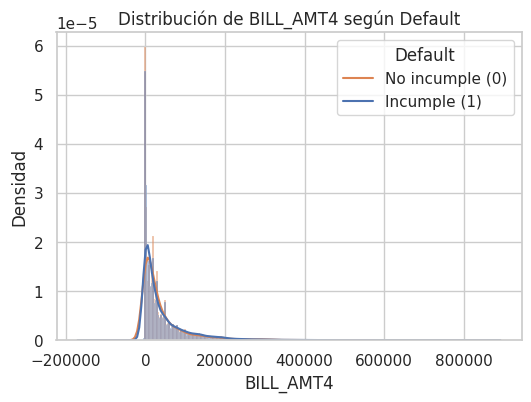

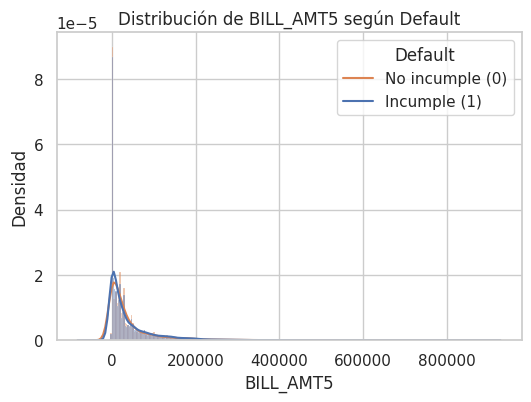

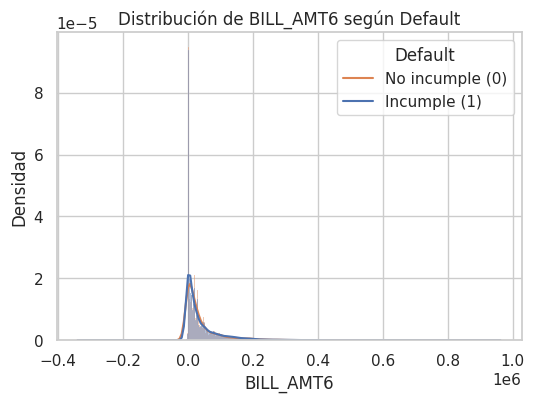

In [33]:
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]

for col in bill_cols:
    plt.figure(figsize=(6,4))

    sb.histplot(data=df, x=col,hue="default", kde=True, stat="density", common_norm=False)

    plt.title(f"Distribución de {col} según Default")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend(title="Default", labels=["No incumple (0)", "Incumple (1)"])

    plt.show()

**NOTA:** Se realizó una gráfica para poder comparar que todas las variables de esta categoría demuestren una distribución similar sesgada hacia los valores mas altos.

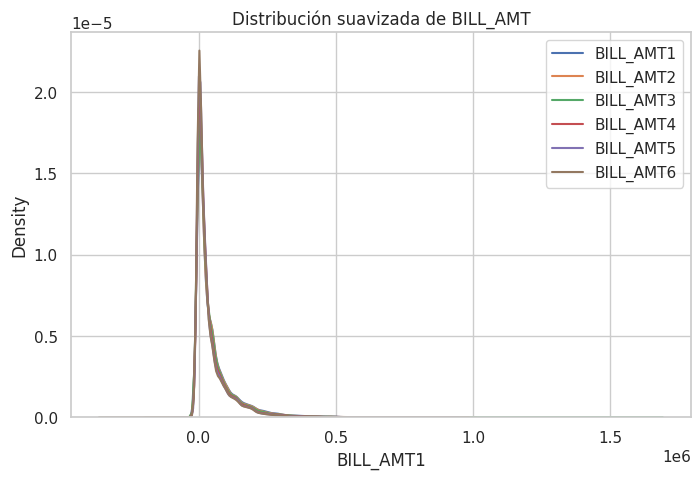

In [34]:
plt.figure(figsize=(8,5))

for col in bill_cols:
    sb.kdeplot(df[col], label=col)

plt.title("Distribución suavizada de BILL_AMT")
plt.legend()
plt.show()

**Observaciones**



*   Las variables tienen una distribución similar
*   Todas las variables de BILL_AMT se encuentran sesgadas a la derecha


*   Debido a que la distribución entre aquellos que tienen incumplimiento y los que no, se superponen se de a entender que esta variable no llega a afectar mucho a predecir si un cliente es incumplido o no

### **PAY_AMT1 a PAY_AMT5**

Se realizó el  mismo procedimiento que con BILL_AMT para PAY_AMT, donde tambien se comparo dlas distribuciones de los PAY_AMT donde se marque de un color diferente sobre el resultado de los clientes con incumpliento y los que estan al dia.

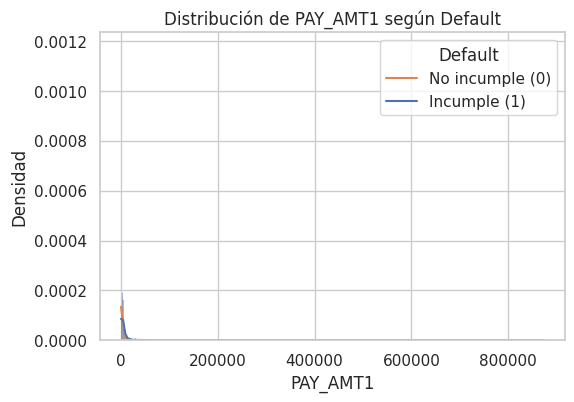

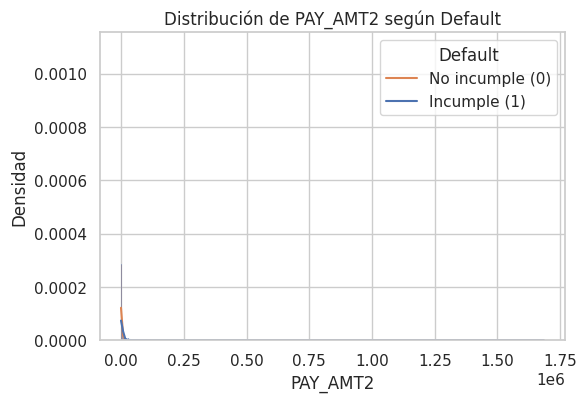

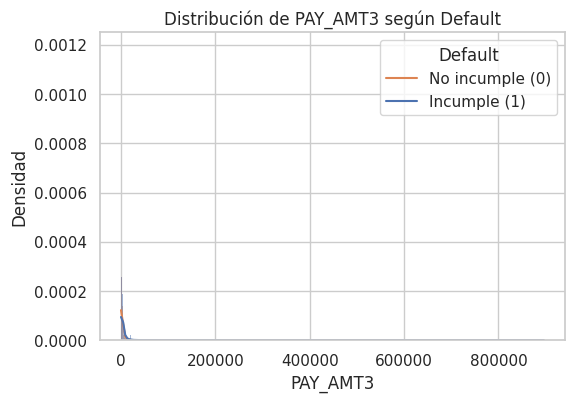

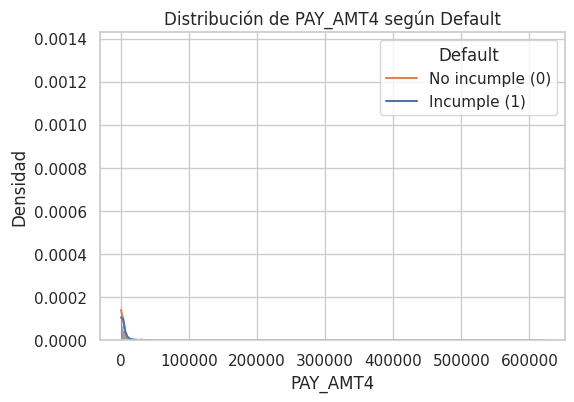

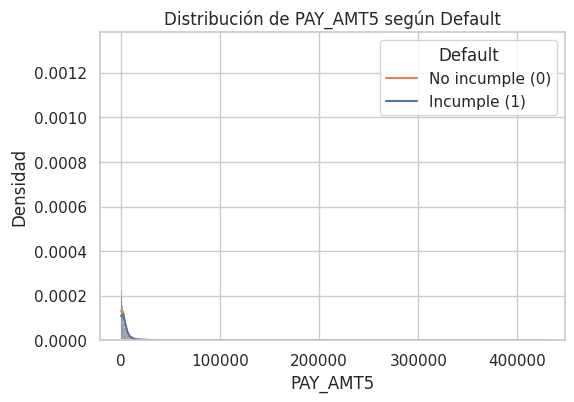

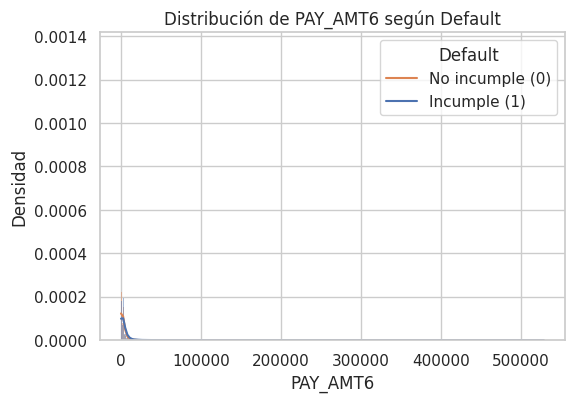

In [35]:
import seaborn as sb
import matplotlib.pyplot as plt

pay_cols = [f"PAY_AMT{i}" for i in range(1,7)]

for col in pay_cols:
    plt.figure(figsize=(6,4))

    sb.histplot(data=df, x=col,hue="default", kde=True, stat="density", common_norm=False)

    plt.title(f"Distribución de {col} según Default")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend(title="Default", labels=["No incumple (0)", "Incumple (1)"])

    plt.show()

**Observaciones**
*   Las varibles tienen una distribución similar
*   Todas las variables de PAY_AMT esta sesgada a la derecha de manera mas radical
*   Debido a que la distribución entre aquellos que tienen incumplimiento y los que no, se superponen se de a entender que esta variable no llega a afectar mucho a predecir si un cliente es incumplido o no

### **2.4.1 BOXPLOT**

**BILL_AMT**

Para poder confirmar el sesgo de estas variables se realizo la grafica de boxplot

**Observaciones**
*   Las varibles tienen una distribucion similar
*   Todas las variables de PAY_AMT esta sesgada a la derecha

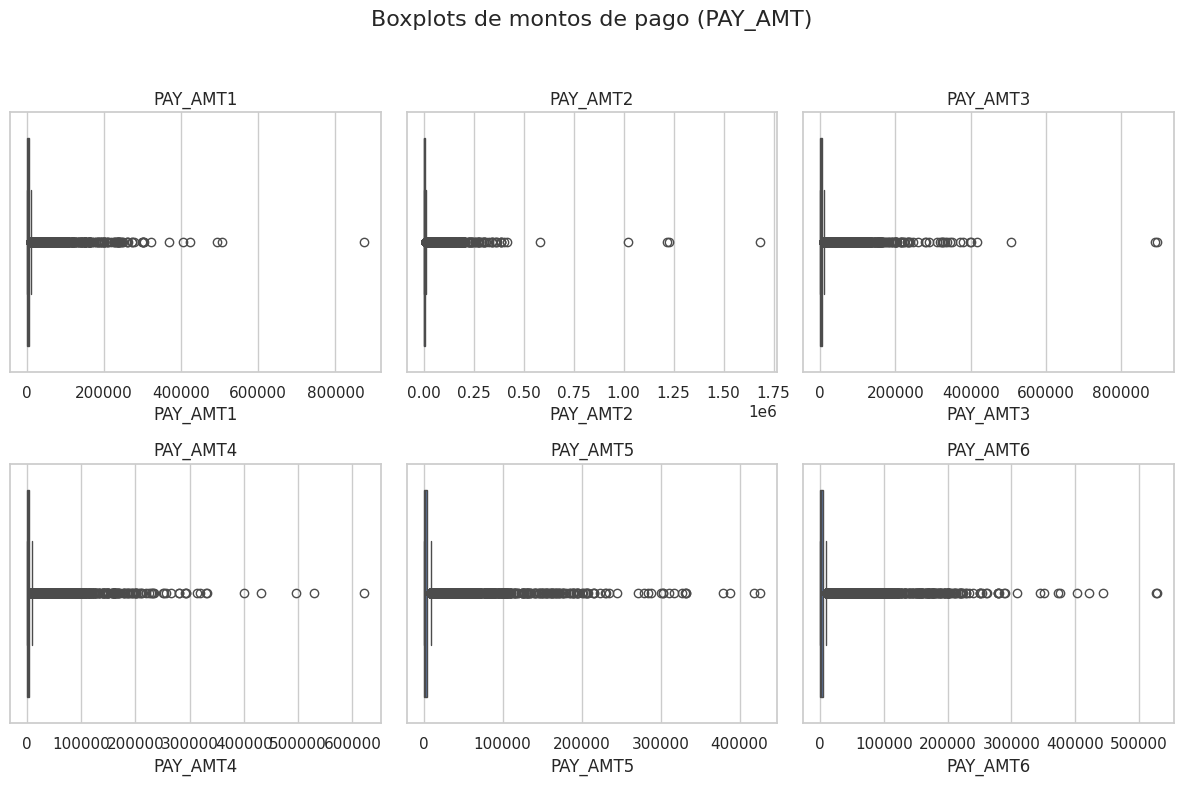

In [36]:
# Crear figura con subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
fig.suptitle('Boxplots de montos de pago (PAY_AMT)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(pay_cols):
    sb.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# eliminar ejes vacíos si hubiera
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**PAY_AMT**

Se realizo el  mismo procedimiento que con BILL_AMT para PAY_AMT
**Observaciones**
*   Las varibles tienen una distribucion similar
*   Todas las variables de PAY_AMT esta sesgada a la derecha de manera mas radical

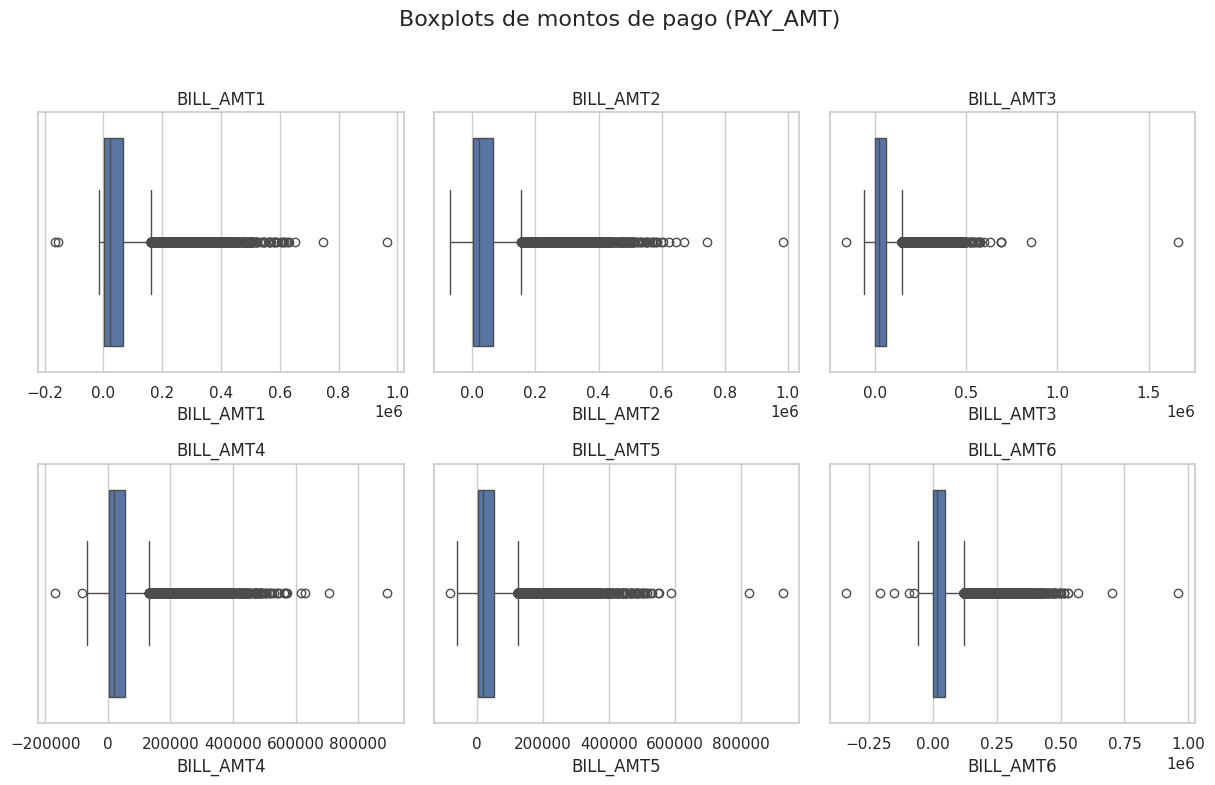

In [37]:
# Crear figura con subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
fig.suptitle('Boxplots de montos de pago (PAY_AMT)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(bill_cols):
    sb.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# eliminar ejes vacíos si hubiera
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**NOTA:** No se realizó el bloxplot ni hisotgrama para la variable "default.payment.next.month", debido a que esta es una varible dicotomica, y no nos provee de información relevante realizar este tipo de gráficos.

### **2.4.2. Tasa de Default por Variables Sensibles (SEX, EDUCATION, MARRIAGE)**

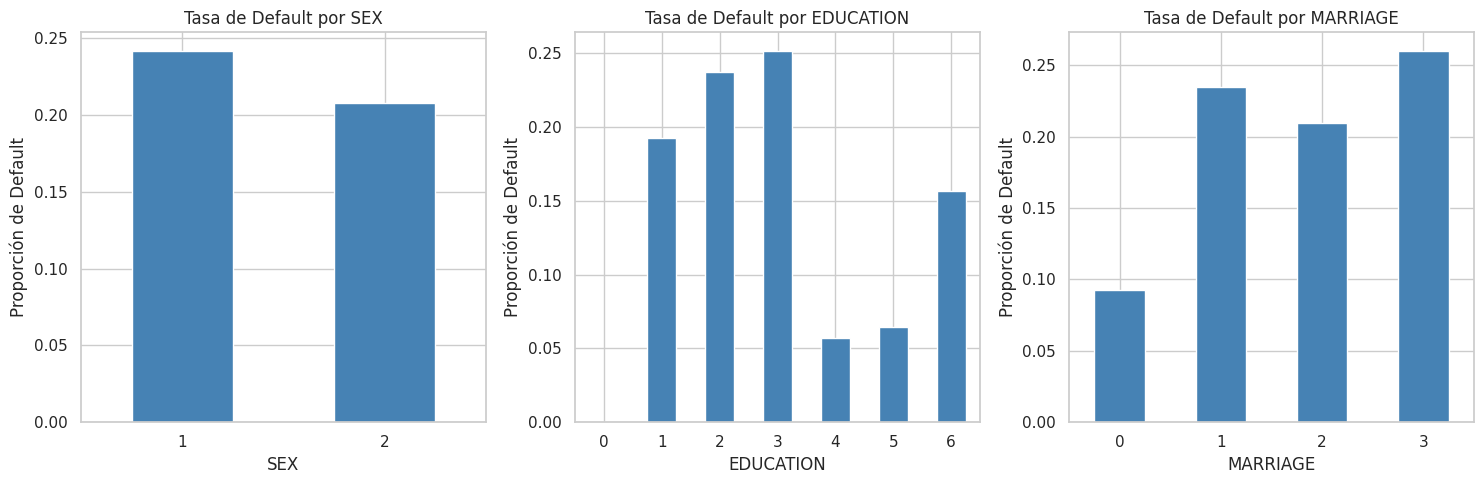

In [38]:
# Tasa de default por SEX, EDUCATION y MARRIAGE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    df.groupby(col)['default'].mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Tasa de Default por {col}')
    ax.set_ylabel('Proporción de Default')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**NOTA:**


**SEX**: Los hombres presentan una tasa de default de 24%, ligeramente superior a las mujeres con 21%. Si bien existe una diferencia de 3 puntos porcentuales. Recordando que
la correlación de SEX con default era de apenas -0.04, esta diferencia visual podría explicarse por otros factores como el límite de crédito o el historial de pagos, y no necesariamente por el género en sí.

**EDUCATION**: Se observa un patrón interesante donde los clientes con educación secundaria (3) presentan la mayor tasa de default (25%), seguidos de universidad (2) con 23% y posgrado (1) con 19%. Las categorías 4 y 5 (otros/desconocido)
muestran tasas anormalmente bajas (6%), lo que refuerza la decisión de agruparestas categorías no documentadas en preprocesamiento, ya que podrían estar introduciendo ruido en el modelo.

**MARRIAGE**: Los clientes con estado civil 3 (otros) presentan la tasa de default más alta (26%), seguidos de casados (1) con 23% y solteros (2) con 21%. Destaca la categoría 0 (no documentada) con una tasa muy baja (~9%), lo que nuevamente sugiere que estas categorías inválidas deben ser tratadas en preprocesamiento.


### **LIMIT_BAL según Default**

<Figure size 800x500 with 0 Axes>

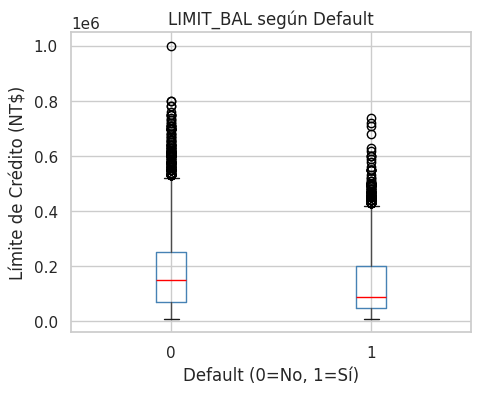

In [39]:
# Boxplot de LIMIT_BAL según default
plt.figure(figsize=(8, 5))
df.boxplot(column='LIMIT_BAL', by='default',
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
plt.title('LIMIT_BAL según Default')
plt.suptitle('')
plt.xlabel('Default (0=No, 1=Sí)')
plt.ylabel('Límite de Crédito (NT$)')
plt.show()

**NOTA:** El boxplot muestra una diferencia clara en el límite de crédito entre clientes que hicieron default (1) y los que no (0). Los clientes sin default presentan una mediana de límite de crédito  más alta  frente a los clientes en default. Esto es consistente con la correlación negativa de -0.15 observada en la matriz de correlación: a mayor límite de crédito, menor probabilidad de default.

Además, se observan múltiples outliers en ambos grupos, especialmente en el grupo sin default. Esto confirma la distribución sesgada a la derecha de LIMIT_BAL y refuerza la necesidad de aplicar StandardScaler en el pipeline para normalizar su escala.

### **Tasa de Default por Estado de Pago (PAY_0)**

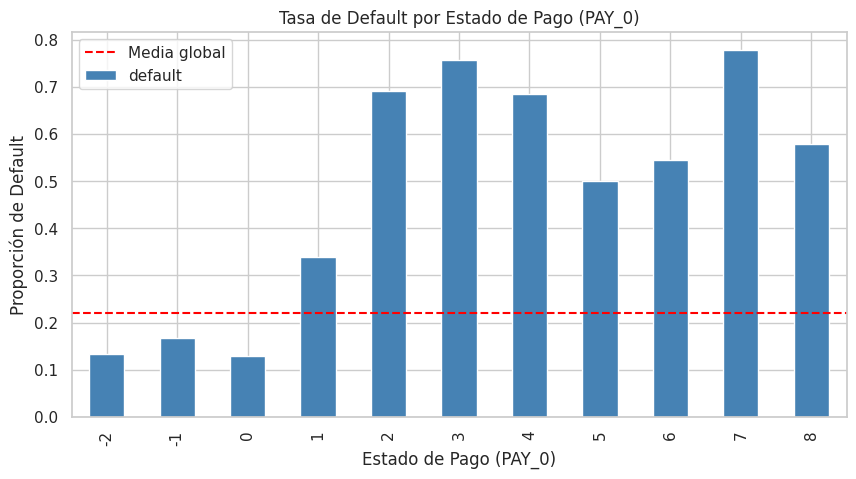

In [40]:
# Tasa de default por estado de pago PAY_0
plt.figure(figsize=(10, 5))
df.groupby('PAY_0')['default'].mean().plot(kind='bar', color='steelblue')
plt.title('Tasa de Default por Estado de Pago (PAY_0)')
plt.xlabel('Estado de Pago (PAY_0)')
plt.ylabel('Proporción de Default')
plt.axhline(df['default'].mean(), color='red', linestyle='--', label='Media global')
plt.legend()
plt.show()

**NOTA:** Se observa que existe una relación clara entre el retraso en los pagos (PAY_0) y la probabilidad de default. Los clientes que pagan a tiempo o no presentan consumo (PAY_0 = -2 o -1) tienen una tasa de default baja, alrededor del 13-16%, por debajo del promedio del dataset. Cuando aparece un mes de retraso (PAY_0 = 1), la probabilidad de default aumenta a aproximadamente 34%. A partir de dos meses de retraso, la probabilidad supera el 69%, lo que indica un riesgo muy alto de incumplimiento. Esto muestra que PAY_0 es una de las variables más importantes para predecir el default, ya que incluso un pequeño retraso puede ser una señal temprana de riesgo para el banco.

### **AGE vs LIMIT_BAL por Default**

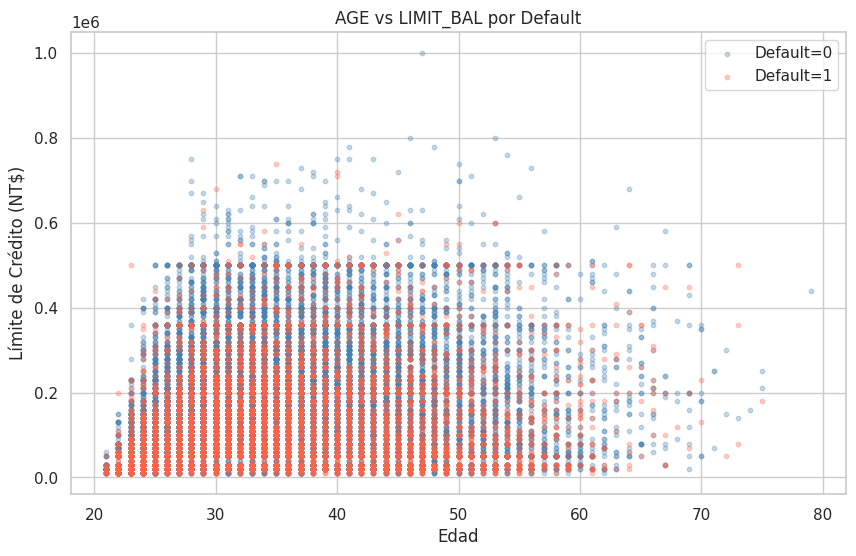

In [41]:
# Scatter plot AGE vs LIMIT_BAL coloreado por default
plt.figure(figsize=(10, 6))
colors = {0: 'steelblue', 1: 'tomato'}
for val, group in df.groupby('default'):
    plt.scatter(group['AGE'], group['LIMIT_BAL'],
                alpha=0.3, s=10,
                color=colors[val],
                label=f'Default={val}')
plt.title('AGE vs LIMIT_BAL por Default')
plt.xlabel('Edad')
plt.ylabel('Límite de Crédito (NT$)')
plt.legend()
plt.show()

**NOTA:** Los puntos rojos (default) y azules (no default) aparecen mezclados, lo que indica que la edad y el límite de crédito por sí solos no permiten distinguir claramente quién hará default. Sin embargo, se observa que los límites de crédito muy altos (más de 600,000 NT$) suelen corresponder a clientes que no presentan incumplimiento, lo que sugiere que un mayor límite de crédito podría estar asociado a clientes con menor riesgo.

### **Tasa de Default por Género y Estado de Pago (PAY_0)**

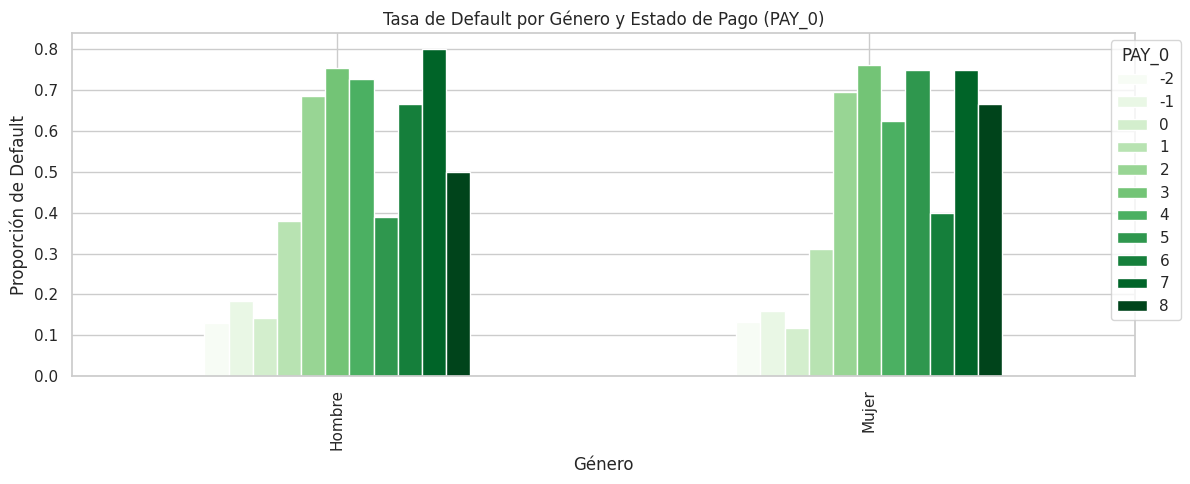

In [42]:
# Retrasos por Género
pivot = df.groupby(['SEX', 'PAY_0'])['default'].mean().unstack()
pivot.index = ['Hombre', 'Mujer']

pivot.plot(kind='bar', figsize=(12, 5), colormap='Greens')
plt.title('Tasa de Default por Género y Estado de Pago (PAY_0)')
plt.xlabel('Género')
plt.ylabel('Proporción de Default')
plt.legend(title='PAY_0', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**NOTA:** Se observa que la proporción de default aumenta a medida que aumenta el retraso en los pagos (PAY_0), tanto en hombres como en mujeres. Es decir, el número de meses de retraso es un factor mucho más importante para explicar el default que el género del cliente. Aunque existen pequeñas diferencias entre hombres y mujeres, el patrón general es el mismo: cuando el retraso supera uno o dos meses, la probabilidad de incumplimiento aumenta considerablemente.

### **Tasa de Default por Educación y Estado de Pago (PAY_0)**

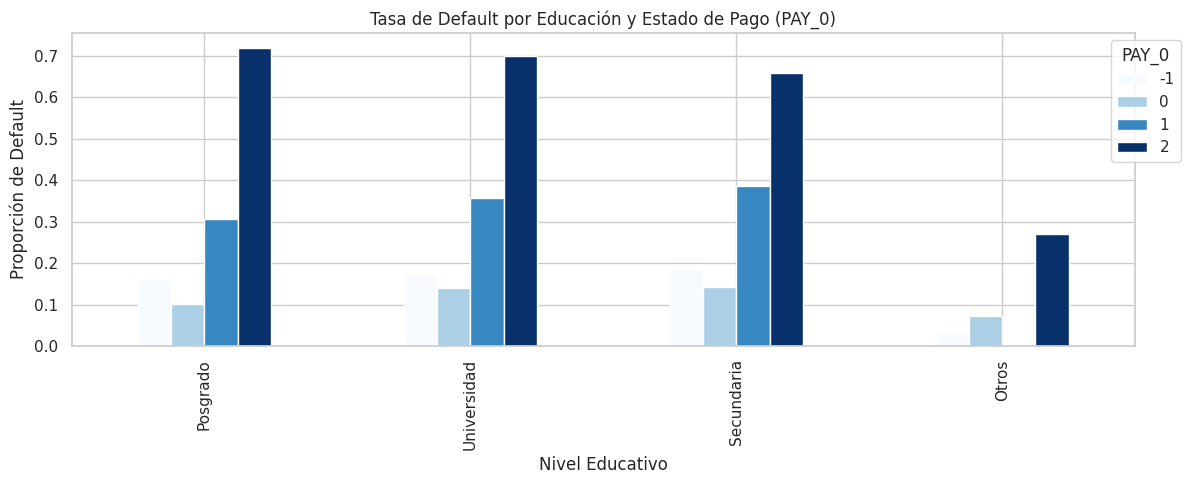

In [43]:
# Copia par la visualizacion por el preprocesamiento
df_viz = df.copy()
df_viz['EDUCATION'] = df_viz['EDUCATION'].replace([0, 5, 6], 4)

pivot2 = df_viz.groupby(['EDUCATION', 'PAY_0'])['default'].mean().unstack()
pivot2.index = ['Posgrado', 'Universidad', 'Secundaria', 'Otros']

pivot2[[-1, 0, 1, 2]].plot(kind='bar', figsize=(12, 5), colormap='Blues')
plt.title('Tasa de Default por Educación y Estado de Pago (PAY_0)')
plt.xlabel('Nivel Educativo')
plt.ylabel('Proporción de Default')
plt.legend(title='PAY_0', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

NOTA: Se observa que, independientemente del nivel educativo, la probabilidad de default aumenta cuando el cliente presenta retrasos en sus pagos (PAY_0). Es decir, el historial de pagos tiene un impacto mucho mayor en el riesgo de incumplimiento que el nivel educativo. Aunque pueden existir ligeras diferencias entre grupos educativos, el patrón general es similar: cuando aparece retraso en los pagos, la tasa de default aumenta notablemente.

## **2.5. HISTOGRAMA DE TODAS LAS VARIABLES**

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'SEX'}>,
        <Axes: title={'center': 'EDUCATION'}>,
        <Axes: title={'center': 'MARRIAGE'}>],
       [<Axes: title={'center': 'AGE'}>,
        <Axes: title={'center': 'PAY_0'}>,
        <Axes: title={'center': 'PAY_2'}>,
        <Axes: title={'center': 'PAY_3'}>,
        <Axes: title={'center': 'PAY_4'}>],
       [<Axes: title={'center': 'PAY_5'}>,
        <Axes: title={'center': 'PAY_6'}>,
        <Axes: title={'center': 'BILL_AMT1'}>,
        <Axes: title={'center': 'BILL_AMT2'}>,
        <Axes: title={'center': 'BILL_AMT3'}>],
       [<Axes: title={'center': 'BILL_AMT4'}>,
        <Axes: title={'center': 'BILL_AMT5'}>,
        <Axes: title={'center': 'BILL_AMT6'}>,
        <Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>],
       [<Axes: title={'center': 'PAY_AMT3'}>,
        <Axes: title={'center': 'PAY_AMT4'}>,
        <A

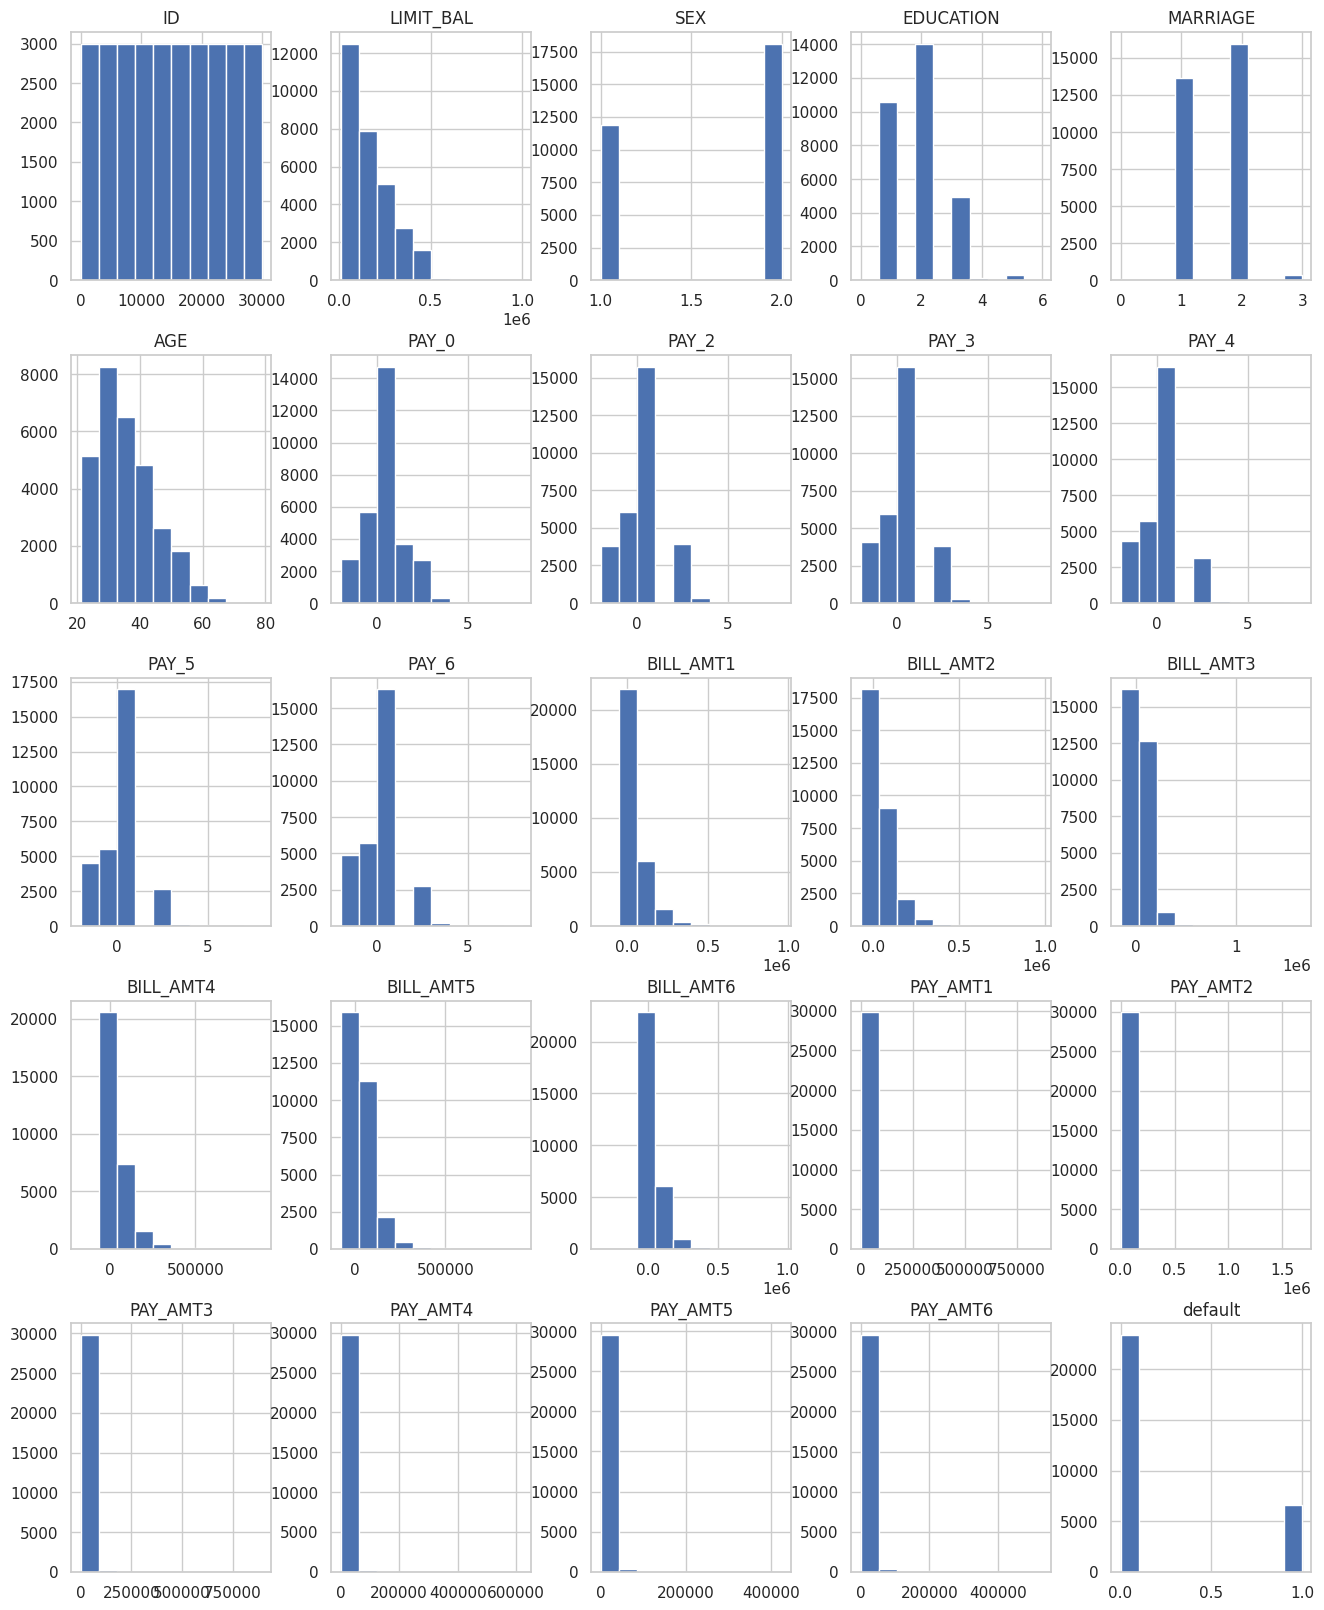

In [44]:
df.hist(figsize=(16, 20))

**NOTA:** Como se peude evidenciar, se muestran los histogramas de las variables confirmando los gráficos y las distribuciones que siguen cada una de las variables anteriormente analizadas.

#**3. PREPROCESAMIENTO**

Despúes de realizar el EDA, se procedió a construir un proceso de preprocesamiento reproducible haciendo uso de Pipeline.

El objetivo de utilizar pipelines es evitar la fuga de información (data leakage) y asegurar que todas las tranformaciones se ajuten únicamente utilizando los datos de entrenamiento. De esta maner las estadísticas necesarias para el preprocesamiento se van a calcular solo en el conjunto de entenamiento para posteriormeten aplicarse en la validación y la prueba.


In [45]:
# Importación de librerías
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [46]:
X = df.drop(columns=['default', 'PAY_AMT1'])

# Target clasificación
y_clf = df['default'].copy()

# Target regresión
y_reg = df['PAY_AMT1'].copy()

print(f"Features:            {X.shape}")
print(f"Target clasificación: {y_clf.shape} | clases: {y_clf.value_counts().to_dict()}")
print(f"Target regresión:     {y_reg.shape} | media: {y_reg.mean():.0f} NT$")

Features:            (30000, 23)
Target clasificación: (30000,) | clases: {0: 23364, 1: 6636}
Target regresión:     (30000,) | media: 5664 NT$


**NOTA:** Dado que este caso de estudio aborda problemas analíticos diferentes, se procede a definir por separado las variables predictoras o variables objetivo. Para clasificación, la variable objetivo ***defaullt***, la cual indica si en cliente incurre o no en incumplimiento de pago del siguiente mes. Por otro lado, para el problema de regresión, la variable objetivo  ***PAY_AMT1***, que representa el monto pagado por el cliente en el periodo mas reciente del dataset proporcionado.

Por tal motivo se procedio a eliminar dichas columnas ya que ambas se emplean como variables objetivo y no deben formar parte de las entradas del modelo. Esto nos permite trabajar con un mismo conjunto de características para construir dos modelos distintos.

Adicionalmente, se realizó una varificación de las dimensiones y distribución de las variables objetivo. En clasificación se reviso la cantidad de observaciones por clase, ello con el fin de poder identificar si existe desbalance entre clientes que hacen default y los que no. En este caso si existe un desbalance notorio ya que una clase cuenta con 23364 que equivale aproximadamente al 78% de los registros del dataset. En el caso de regresión, se verificó el tamaño del target y su valor promedio (5664), ello con el objetivo de tener una referencia inicial sobre la magnitud de los pagos.

### **División del Dataset y Estratificación**

In [47]:
# Separar test (20%)
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
for train_val_idx, test_idx in split1.split(X, y_clf):
    X_train_val      = X.iloc[train_val_idx]
    X_test           = X.iloc[test_idx]
    y_clf_train_val  = y_clf.iloc[train_val_idx]
    y_clf_test       = y_clf.iloc[test_idx]
    y_reg_train_val  = y_reg.iloc[train_val_idx]
    y_reg_test       = y_reg.iloc[test_idx]

In [48]:
# Se divide el primer conjunto
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
for train_idx, val_idx in split2.split(X_train_val, y_clf_train_val):
    X_train      = X_train_val.iloc[train_idx]
    X_val        = X_train_val.iloc[val_idx]
    y_clf_train  = y_clf_train_val.iloc[train_idx]
    y_clf_val    = y_clf_train_val.iloc[val_idx]
    y_reg_train  = y_reg_train_val.iloc[train_idx]
    y_reg_val    = y_reg_train_val.iloc[val_idx]

**NOTA:** Se procede a dividir el dataset en dos partes, un conjunto de entrenamiento (60%), validación (20%) y otro conjunto de prueba (20%). Esta división se la realizó con *StratifiedShuffleSplit*, que nos permite mantener la misma proporción de clases de la variable default en ambos conjuntos.

El objetivo de esta división es reservar el conjunto de test solo para la evaluación final del modelo, mientras que el conjunto de train y validation se utilizarán para entrenar los modelos y ajustar sus parámetros.

In [49]:
# Verificar tamaños y proporciones
print(f"\nTamaños del split:")
print(f"  Train:      {X_train.shape[0]:>6,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]:>6,} ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]:>6,} ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nProporción de default (clase 1) — verificar estratificación:")
print(f"  Train:      {y_clf_train.mean():.3f}")
print(f"  Validation: {y_clf_val.mean():.3f}")
print(f"  Test:       {y_clf_test.mean():.3f}")


Tamaños del split:
  Train:      18,000 (60%)
  Validation:  6,000 (20%)
  Test:        6,000 (20%)

Proporción de default (clase 1) — verificar estratificación:
  Train:      0.221
  Validation: 0.221
  Test:       0.221


NOTA: Se verifica el tamaño de cada subconjunto genrado después de la división del dataset, ello con el fin de confirmar que las proporciones sean aproximadamente 60% para train, 20% para validation y 20% para test. Como se puede evidenciar el dataste se encuentra dividido de manera correcta.

Asimismo, se calcula la proporción de la clase default (valor 1) en cada subconjunto, ello para poder comprobar que la estratificación se haya realizado correctamente y que la distribución de clases sea similar en los conjuntos de entrenamiento, validación y prueba, evitando sesgos en el entrenamiento y evaluación de los modelos.

### **Definición de Tipos de columnas**

En esta etapa se definen los distintos tipos de variables presentes en el dataset con el objetivo de aplicar transformaciones adecuadas durante el preprocesamiento. Separar las columnas por tipo permite utilizar herramientas como ColumnTransformer, que aplica diferentes transformaciones a cada grupo de variables dentro de un mismo pipeline.

In [50]:
# ID excluido (remainder='drop'), ni target
cols_numericas = (
    ['LIMIT_BAL', 'AGE'] +
    [f'BILL_AMT{i}' for i in range(1, 7)] + # BILL_AMT1 a BILL_AMT6
    [f'PAY_AMT{i}' for i in range(2, 7)]   # PAY_AMT2 a PAY_AMT6
)

**NOTA:** Se definen las variables numéricas del dataset, incluyendo el límite de crédito (LIMIT_BAL), la edad (AGE), los montos facturados (BILL_AMT1–BILL_AMT6) y los pagos realizados en meses anteriores (PAY_AMT2–PAY_AMT6).
La columna ID se excluye por ser solo un identificador y PAY_AMT1 no se incluye porque se utiliza como variable objetivo en el problema de regresión.

In [51]:
# Estado de pago  que es ordinal con orden natural (-2 a 8), sin escalar
cols_pay_status = [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]

**NOTA:** Este grupo incluye las variables PAY_0, PAY_2, PAY_3, PAY_4, PAY_5 y PAY_6, que representan el estado de pago del cliente en meses anteriores. Estas variables son ordinales, ya que indican niveles de retraso en los pagos, por lo que se mantienen en su escala original y no se escalan.

In [52]:
# Categóricas demográficas, códigos numéricos nominales
cols_categoricas = ['SEX', 'EDUCATION', 'MARRIAGE']

**NOTA:** Este grupo incluye las variables demográficas que representan características del cliente como género, nivel educativo y estado civil. Aunque están codificadas con números, corresponden a categorías nominales, por lo que se tratan como variables categóricas dentro del preprocesamiento.

### **Feature Engineering**

En esta etapa se crean nuevas variables derivadas a partir de las columnas originales del dataset con el objetivo de capturar mejor el comportamiento financiero del cliente. Estas variables se generan dentro del pipeline mediante un transformador personalizado, lo que garantiza que se calculen de forma consistente en los conjuntos de entrenamiento, validación y prueba, evitando así data leakage.

Para ello se construyeron tres nuevas variables:



**1.   Utilization_Rate = BILL_AMT1 / LIMIT_BAL**

Mide qué proporción del límite de crédito está siendo utilizada por el cliente. Un valor alto o cercano a 1 indica que el cliente está utilizando gran parte de su crédito disponible, lo que puede ser una señal de mayor riesgo financiero. Asimismo, esta variable es más informativa que BILL_AMT1 o LIMIT_BAL por separado porque relativiza el saldo al límite disponible, es decir, no importa cúanto debe, sino qué tan grande es esa deuda respecto a su capacidad de crédito.


**2. ** ** PAY_AMT_Total = suma de PAY_AMT2 a PAY_AMT6**

Representa el total pagado por el cliente en lo últimos cinco meses. Esta variable resume el comportamiento de pago reciente y permite capturar mejor su capacidad de pago acumulada, es decir, brinda mayor información sobre los pagos realiazdos por el cliente.



**3.**   **BILL_AMT_Total = suma de BILL_AMT1 a BILL_AMT6**

Representa el monto total facturado en los último 6 meses, ya que al compararse con el total pagado (PAY_AMT_Total), permite identificar si el cliente está pagando sus deudas o si las está acumulando con el tiempo, es decir, si BILL_AMT_Total es significativamente mayor que PAY_AMT_Total, el cliente acumula deuda, lo que aumenta su probabilidad de default.


Estas variables proporcionan mayor información o nos brindan indicadores más interpretables que pueden mejorar la capacidad predictiva del modelo y capturar patrones financieros relevantes.




In [53]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Tasa de utilización del crédito
        X['Utilization_Rate'] = (
            X['BILL_AMT1'] / X['LIMIT_BAL'].replace(0, np.nan)
        ).fillna(0).clip(-1, 5)

        # Total pagado (PAY_AMT2 a PAY_AMT6, ya que PAY_AMT1 es target)
        X['PAY_AMT_Total'] = sum(X[f'PAY_AMT{i}'] for i in range(2, 7))

        # Total facturado
        X['BILL_AMT_Total'] = sum(X[f'BILL_AMT{i}'] for i in range(1, 7))

        return X

In [54]:
# Tipos de columnas del dataset
cols_engineered = ['Utilization_Rate', 'PAY_AMT_Total', 'BILL_AMT_Total']
print(f"\nGrupos de columnas:")
print(f"  Numéricas ({len(cols_numericas)}):    {cols_numericas}")
print(f"  PAY status ({len(cols_pay_status)}):  {cols_pay_status}")
print(f"  Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"  Engineered ({len(cols_engineered)}):  {cols_engineered}")


Grupos de columnas:
  Numéricas (13):    ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
  PAY status (6):  ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
  Categóricas (3): ['SEX', 'EDUCATION', 'MARRIAGE']
  Engineered (3):  ['Utilization_Rate', 'PAY_AMT_Total', 'BILL_AMT_Total']


**NOTA:** Se pueden observar la cantidad de features por tipo. en ese sentido el dataset presenta 13 features numéricos, 6 de PAY status, 3 categóricos y 3 engineered

### **Pipeline de Preprocesamiento**

Durante el preprocesamiento, las variables numéricas y las variables creadas mediante feature engineering se escalan utilizando StandardScaler. Esto se hace porque estas variables representan montos financieros o valores continuos que pueden tener rangos muy diferentes. Por ejemplo, el límite de crédito (LIMIT_BAL) puede tomar valores muy altos, mientras que otras variables pueden tener valores mucho menores como AGE. Si estas variables se utilizan sin escalado, aquellas con valores más grandes podrían dominar el entrenamiento del modelo, afectando su desempeño. El escalado permite que todas las variables numéricas tengan una escala comparable, lo que ayuda a que los modelos aprendan de forma más estable y eficiente.

Por otro lado, las variables de estado de pago (PAY_*) no se escalan porque son variables ordinales, donde los valores representan niveles de retraso en el pago y su escala ya tiene un significado. De igual forma, las variables categóricas (SEX, EDUCATION, MARRIAGE) se mantienen sin transformación, ya que representan categorías y no magnitudes numéricas.

De esta manera, cada tipo de variable recibe el tratamiento adecuado dentro del pipeline de preprocesamiento.

In [55]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numericas + cols_engineered),
        ('pay', 'passthrough',    cols_pay_status),
        ('cat', 'passthrough',    cols_categoricas),
    ],
    remainder='drop'
)

# Pipeline final con feature engineering
pipeline_completo = Pipeline([
    ('feature_eng',   FeatureEngineering()),
    ('preprocesador', preprocesador),
])

### **Aplicación del pipeline de Preprocesamiento**

Una vez definido el pipeline, se aplica primero al conjunto de entrenamiento utilizando fit_transform. Esto permite que el pipeline aprenda las transformaciones necesarias únicamente a partir de los datos de entrenamiento.

Posteriormente, el mismo pipeline se aplica a los conjuntos de validación y prueba utilizando transform, lo que garantiza que las transformaciones aprendidas en el entrenamiento se utilicen de forma consistente en los demás conjuntos, evitando así fuga de información (data leakage).



In [56]:
X_train_prep = pipeline_completo.fit_transform(X_train)
X_val_prep   = pipeline_completo.transform(X_val)
X_test_prep  = pipeline_completo.transform(X_test)

print(f"Forma final de los datos preprocesados:")
print(f"  X_train_prep: {X_train_prep.shape}")
print(f"  X_val_prep:   {X_val_prep.shape}")
print(f"  X_test_prep:  {X_test_prep.shape}")

# Verificar que el número de columnas es correcto
n_cols_esperadas = (len(cols_numericas) + len(cols_engineered) +
                    len(cols_pay_status) + len(cols_categoricas))
print(f"\nColumnas esperadas: {n_cols_esperadas} | Columnas obtenidas: {X_train_prep.shape[1]}")
assert X_train_prep.shape[1] == n_cols_esperadas, "Número de columnas incorrecto"
print("Pipeline ejecutado correctamente")

Forma final de los datos preprocesados:
  X_train_prep: (18000, 25)
  X_val_prep:   (6000, 25)
  X_test_prep:  (6000, 25)

Columnas esperadas: 25 | Columnas obtenidas: 25
Pipeline ejecutado correctamente


**NOTA:** Asimismo, se procede a verificar la forma de los datos transformados para asegurar que el número de columnas resultante sea el esperado. En este caso, después del preprocesamiento el conjunto de entrenamiento contiene 18,000 observaciones y 25 variables, mientras que los conjuntos de validación y prueba contienen 6,000 observaciones cada uno, manteniendo las mismas 25 variables. Esta verificación confirma que el pipeline se ejecutó correctamente y que todas las transformaciones se aplicaron como se esperaba.

In [57]:
# Ver exactamente qué columnas están en cada grupo
print("=== GRUPOS DE COLUMNAS ===")
print(f"\ncols_numericas ({len(cols_numericas)}): {cols_numericas}")
print(f"\ncols_engineered ({len(cols_engineered)}): {cols_engineered}")
print(f"\ncols_pay_status ({len(cols_pay_status)}): {cols_pay_status}")
print(f"\ncols_categoricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"\nTotal: {len(cols_numericas) + len(cols_engineered) + len(cols_pay_status) + len(cols_categoricas)}")

print("\n=== COLUMNAS EN X ===")
print(list(X.columns))
print(f"Total columnas en X: {X.shape[1]}")

print("\n=== COLUMNAS NO INCLUIDAS EN NINGÚN GRUPO (serán dropeadas) ===")
todas = set(cols_numericas + cols_engineered + cols_pay_status + cols_categoricas)
dropeadas = [c for c in X.columns if c not in todas]
print(dropeadas)

=== GRUPOS DE COLUMNAS ===

cols_numericas (13): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cols_engineered (3): ['Utilization_Rate', 'PAY_AMT_Total', 'BILL_AMT_Total']

cols_pay_status (6): ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

cols_categoricas (3): ['SEX', 'EDUCATION', 'MARRIAGE']

Total: 25

=== COLUMNAS EN X ===
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Total columnas en X: 23

=== COLUMNAS NO INCLUIDAS EN NINGÚN GRUPO (serán dropeadas) ===
['ID']


NOTA: Se procede a verificar que todas las variables del dataset estén correctamente asignadas a alguno de los grupos definidos para el preprocesamiento: numéricas, estado de pago, categóricas y variables creadas mediante feature engineering. En este caso, los resultados muestran que el pipeline utilizará 25 variables en total, correspondientes a las variables numéricas originales, las variables de estado de pago, las variables categóricas y las nuevas variables generadas. Además, se confirma que la única columna que no pertenece a ningún grupo es ID, la cual se elimina automáticamente durante el preprocesamiento, ya que solo funciona como identificador y no aporta información relevante para el modelo.

# **4. MODELADO**

## **4.1. REGRESIÓN**

### **4.1.1. Baseline - Regresión Lineal**

Se utilizo como punto de partida la regresion lineal debido a su sencillez y facilidad de interpretar y de ser entrenado. Mediante este modelo como una punto incial, nos ayuda a visualizar de alguna manera la relacion que tienen las variables de entrada con el target.
Este modelo nos permite poder tener un modelo predictorio de variables numericas como ser PAY_AMT1 utilizando las variables de entrada como ser las financieras, sociogeologicas y de comportamiento de pago.
En una primera instancia se utiliza el modelo sin ninguna alteracion sobre el original y la clasica regresion lineal.
Sobre este los primero errores cuadraticos que se encontraron fueron los vistos por consola:

In [62]:
# ── 1. REGRESION LINEAL
# En primera instancia para poder tener unpunto de partida en el analisis
# de nuestro dataset, se realizó rapidamente un modelo de regresion lineal
# los resultados de este modelo serviran como una comparativa. Ademas de
# esta manera se podria llegar a identificar mas propiedades del dataset
# y a corregir estas antes de que se entrenen con otros modelos mas rigurosos

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Configurar y Entrenar el Modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train_prep, y_reg_train)

# Predicciones (Train y Validation)
y_train_pred = lin_reg.predict(X_train_prep)
y_val_pred_lin = lin_reg.predict(X_val_prep)

# Evaluación usando RMSE (Raíz del Error Cuadrático Medio)
# Aplicamos np.sqrt para que el error esté en las mismas unidades que la variable objetivo
rmse_train = np.sqrt(mean_squared_error(y_reg_train, y_train_pred))
rmse_val   = np.sqrt(mean_squared_error(y_reg_val, y_val_pred_lin))

print("=== PRIMEROS ERRORES CON REGRESIÓN LINEAL ===")
print(f"RMSE (train): {rmse_train:.4f}")
print(f"RMSE (val):   {rmse_val:.4f}")


=== PRIMEROS ERRORES CON REGRESIÓN LINEAL ===
RMSE (train): 12592.4068
RMSE (val):   12021.9679


En ese punto de partida el modelo de regresión lineal obtuvo un RMSE de 12,592 en el conjunto de entrenamiento y 12,021 en el conjunto de validación. Esto indica que el modelo presenta un error promedio de aproximadamente 12 mil unidades monetarias al estimar el monto de pago (PAY_AMT1). La cercanía entre ambos valores sugiere que el modelo no presenta sobreajuste significativo y generaliza de manera adecuada sobre datos no vistos. Sin embargo, el error observado puede estar influenciado por la presencia de valores atípicos en la variable objetivo.

In [66]:
# Definición de la función resumen_cv
from sklearn.model_selection import cross_validate
# Definimos el Pipeline de "Procesamiento Completo"
pasos_procesamiento = [
    ('feature_eng', FeatureEngineering()),
    ('preprocesador', preprocesador)
]
pipe_lineal = Pipeline(steps=pasos_procesamiento + [
    ('modelo', LinearRegression())

])

def resumen_cv(pipeline, X_data, y_data, model_name):
    scores = cross_validate(pipeline, X_data, y_data,
                            scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                            cv=5, n_jobs=-1)

    rmse_scores = np.sqrt(-scores['test_neg_mean_squared_error'])
    mae_scores = -scores['test_neg_mean_absolute_error']
    r2_scores = scores['test_r2']

    return {
        'model': model_name,
        'rmse_mean': rmse_scores.mean(),
        'rmse_std': rmse_scores.std(),
        'mae_mean': mae_scores.mean(),
        'mae_std': mae_scores.std(),
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std()
    }

metrics_lineal_cv = resumen_cv(pipe_lineal, X_train, y_reg_train, "Linear Regression")

Debido a que la la validacion de estas metricas llega a ser bastante importante (por que miden el rendimiento del modelo)
se encontro conveniente realizar una validacion cruzada a lo largo de los distintos modelos probados.
Esto con el proposito de mantener la integridad y credibilidad en toda la validacion de modelos.
En primera instancia se define un metodo para poder resumir con un formato todas las verisones:

In [67]:
# VALIDACION CRUZADA
# Para tener una mejor validacion del modelo se realizo la Validacion cruzada. Asi
# logramos mitigar el riesgo de "sesgo de selección" que ocurre cuando el rendimiento
# del modelo depende de cómo se dividieron aleatoriamente los datos inicialmente
# Ademas obtenemos el RMSE promedio y su desviación estándar. Esto confirma si el
# modelo es estable (baja varianza) o si su precisión es fruto del azar en una partición específica.

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


pipe_lineal.fit(X_train, y_reg_train)

y_train_pred = pipe_lineal.predict(X_train) #predicciones
y_val_pred_lin = pipe_lineal.predict(X_val)

print("=== EVALUACIÓN CON PIPELINE COMPLETO ===")


print(f"Regresión Lineal - RMSE: {metrics_lineal_cv['rmse_mean']:.4f}")
print(f"Regresión Lineal - MAE:  {metrics_lineal_cv['mae_mean']:.4f}")
print(f"Regresión Lineal - R2:   {metrics_lineal_cv['r2_mean']:.4f}")

=== EVALUACIÓN CON PIPELINE COMPLETO ===
Regresión Lineal - RMSE: 12884.0260
Regresión Lineal - MAE:  4738.8294
Regresión Lineal - R2:   0.3452


Para finalizar la revision de esta primera instancia de revision de modelo para nuestro data set, se puede visualizar la realcion entre los valores reales y las predicciones. Sobre esto se realiza una graifca de dispersion entre estos dos valores. A continuacion se puede observar la grafica

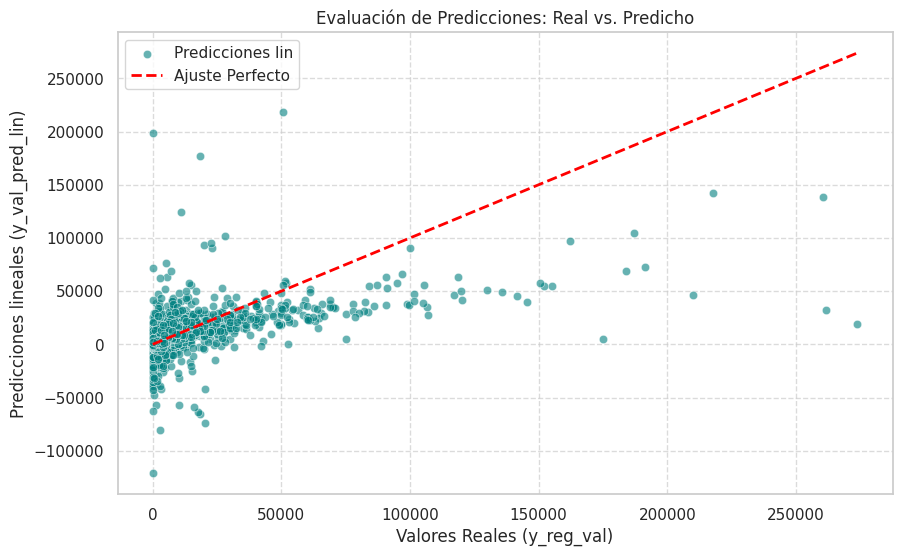

In [68]:
# Gráfico de Dispersión (Valores Reales vs Predicciones)
plt.figure(figsize=(10, 6))
sb.scatterplot(x=y_reg_val, y=y_val_pred_lin, alpha=0.6,  color='teal', label='Predicciones lin')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones lineales (y_val_pred_lin)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Dentro esta grafica los puntos azules son la realcion entre la prediccion del target y su valor real. Por otro lado la linea roja punteada es un referente de cuando la prediccion y la realidad llegan a coincidir a este se le llamaria el "ajuste perfecto" que pertenece a una linea que conecta el valor minimo y el valor maximo dentro del target en el dataset. Como se observa en el grafico no se llega a tener una relacion perfecta con la prediccion del modelo. Tambien se puede observar probablemente debido a la gran cantidad de outliers

### 4.1.2 Mejora con Support vector regression

SUPPORT VECTOR REGRESSION

Con el objetivo de realizar una evaluación rigurosa de las capacidades predictivas sobre la variable continua PAY_AMT1, se ha incorporado al análisis el modelo de Support Vector Regression (SVR). Esta decisión responde a dos objetivos fundamentales de la investigación:
*   Consistencia Metodológica Multitarea: Dado que este estudio contempla tanto tareas de clasificación como de regresión, resulta de particular interés científico evaluar la consistencia y el desempeño de la arquitectura de Vectores de Soporte bajo distintas naturalezas de variable objetivo utilizando el mismo conjunto de datos. Esta comparativa permite observar la adaptabilidad del algoritmo y determinar si su capacidad de segmentación en espacios de alta dimensionalidad se traduce en una ventaja competitiva para la estimación de montos financieros.



In [69]:
# ── 2. SUPPORT VECTOR REGRESSION
# Para poder ofrecer otra comparativa para poder analizar de manera mas rigurosa
# el modelo que se podria llegar a ajustar de mejor manera a la regresion de la
# variable PAY_AMT1, se decidio tmabien probar con el modelo de Support Vector
# Regression

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

svm_model = SVR(kernel="rbf")
svm_model.fit(X_train_prep, y_reg_train)

y_train_pred_svm = svm_model.predict(X_train_prep)
y_val_pred_svm   = svm_model.predict(X_val_prep)

rmse_train_svm = np.sqrt(mean_squared_error(y_reg_train, y_train_pred_svm))
rmse_val_svm   = np.sqrt(mean_squared_error(y_reg_val, y_val_pred_svm))

mae_train_svm = mean_absolute_error(y_reg_train, y_train_pred_svm)
mae_val_svm   = mean_absolute_error(y_reg_val, y_val_pred_svm)

r2_train_svm = r2_score(y_reg_train, y_train_pred_svm)
r2_val_svm   = r2_score(y_reg_val, y_val_pred_svm)

print("=== RESULTADOS SUPPORT VECTOR REGRESSION ===")
print(f"RMSE (train) SVM: {rmse_train_svm:.4f}")
print(f"RMSE (val) SVM:   {rmse_val_svm:.4f}")
print(f"MAE (train) SVM:  {mae_train_svm:.4f}")
print(f"MAE (val) SVM:    {mae_val_svm:.4f}")
print(f"R2 (train) SVM:   {r2_train_svm:.4f}")
print(f"R2 (val) SVM:     {r2_val_svm:.4f}")

=== RESULTADOS SUPPORT VECTOR REGRESSION ===
RMSE (train) SVM: 17015.2293
RMSE (val) SVM:   14287.0156
MAE (train) SVM:  4487.6519
MAE (val) SVM:    4366.6194
R2 (train) SVM:   -0.0266
R2 (val) SVM:     -0.0364


A pesar de la versatilidad del modelo SVR, los resultados obtenidos sugieren que el algoritmo presenta limitaciones intrínsecas para capturar la estructura de variabilidad de PAY_AMT1. Un factor determinante en este desempeño es la imposibilidad de aplicar una regularización $L_2$ directa.

Nota Metodológica: Este rendimiento, aunque no óptimo, sirve como un punto de comparación esencial. Demuestra que, para esta variable en particular, la complejidad del SVR no logra compensar la falta de una estructura de regularización más flexible, posicionándolo por debajo de otros modelos que se explorarán a continuación.

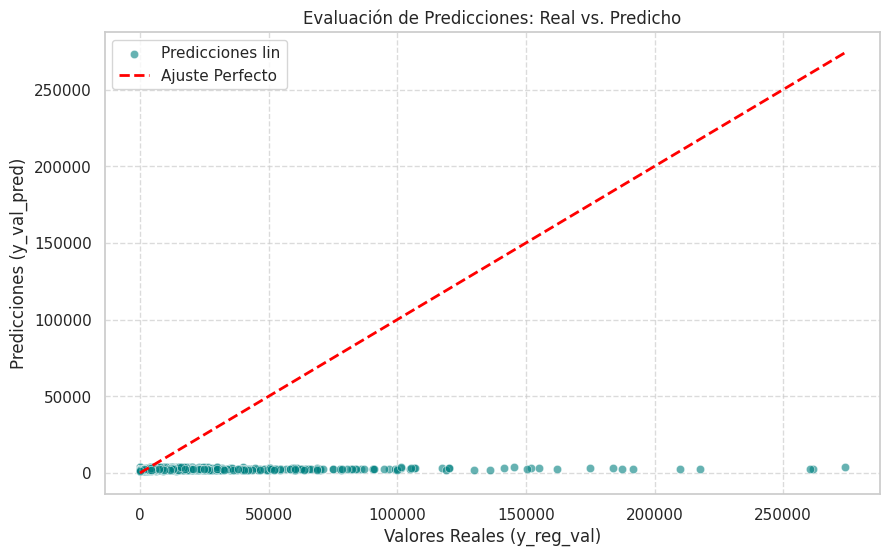

In [70]:
# Gráfico de Dispersión (Valores Reales vs Predicciones)
plt.figure(figsize=(10, 6))
sb.scatterplot(x=y_reg_val, y=y_val_pred_svm, alpha=0.6,  color='teal', label='Predicciones lin')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones (y_val_pred)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Al examinar la representación gráfica del modelo SVR, se observa una dispersión atípica y poco favorable que refuerza las deficiencias señaladas por las métricas numéricas. La visualización revela una incapacidad del algoritmo para converger en una función que capture la tendencia central de los datos.

### 4.1.3 Optimizacion de Vectores de Soporte

Es preciso abrir un paréntesis metodológico: la eficacia del SVR depende críticamente de la sintonía de sus hiperparámetros.
Por ello, se procedió a una reevaluación mediante Búsqueda Aleatorizada (Randomized Search) y Validación Cruzada (Cross-Validation).
Este proceso es fundamental para:
*   Garantizar la Generalización: Evitando sesgos en la selección del modelo.
*   Eficiencia Computacional: Dado que el SVR presenta una alta complejidad algorítmica, este ajuste requiere una gestión discrecional del tiempo de procesamiento, factor que será evidente en los resultados posteriores.

El uso previo de estas herramientas nos servira para el manejo de otras posteriores.
(Sin embargo puede tomar un tiempo en ser compilado así que se sugiere discrecion)

In [71]:
# OPTIMIZACIÓN DE HIPERPARAMETROS Y VALIDACIÓN CRUZADA AVANZADA
# == VECTORES DE SOPORTE ==
# este proceso puede tomar bastante tiempo

from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

pasos_procesamiento = [   # Definimos la base del procesamiento
    ('feature_eng', FeatureEngineering()),
    ('preprocesador', preprocesador)
]

pipe_bosque = Pipeline(steps=pasos_procesamiento + [ ("modelo", SVR())]) #Modelo SVR

param_distributions = {
    "modelo__kernel": ["linear", "rbf"], # Definimos el espacio de búsqueda de parámetro
    "modelo__C": [0.1, 1, 10, 100],
    "modelo__gamma": ["scale", "auto"]
}

busqueda = RandomizedSearchCV( #Definicion de Validacion Cruzada
    pipe_bosque,
    param_distributions=param_distributions,
    n_iter=10,           # Prueba 10 combinaciones aleatorias
    cv=5,                # Cada combinación se evalúa con 5-fold CV
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1            # Usa todos los procesadores para ir más rápido
)

# Entrenamos la búsqueda (Usamos X_train original porque el pipe hace el resto)
print("Ejecutando RandomizedSearchCV...")
busqueda.fit(X_train, y_reg_train)

mejor_rmse_cv = np.sqrt(-busqueda.best_score_) # Resultados

print("\n=== RESULTADOS OPTIMIZACIÓN VSR ===")
print(f"Mejor RMSE obtenido en CV: {mejor_rmse_cv:.4f}")
print("Mejores parámetros encontrados:")
print(busqueda.best_params_)

# Evaluación final sobre el set de Validación con el MEJOR modelo
mejor_modelo = busqueda.best_estimator_
y_val_pred_rf = mejor_modelo.predict(X_val)
rmse_svr_cv = np.sqrt(mean_squared_error(y_reg_val, y_val_pred_rf))
mae_svr_cv = mean_absolute_error(y_reg_val, y_val_pred_rf)
r2_svr_cv = r2_score(y_reg_val, y_val_pred_rf)

print(f"\nRMSE Final en el set de Validación: {rmse_svr_cv:.4f}")
print(f"MAE Final en el set de Validación:  {mae_svr_cv:.4f}")
print(f"R2 Final en el set de Validación:   {r2_svr_cv:.4f}")

Ejecutando RandomizedSearchCV...

=== RESULTADOS OPTIMIZACIÓN VSR ===
Mejor RMSE obtenido en CV: 15265.8344
Mejores parámetros encontrados:
{'modelo__kernel': 'linear', 'modelo__gamma': 'auto', 'modelo__C': 100}

RMSE Final en el set de Validación: 12965.4789
MAE Final en el set de Validación:  3540.9977
R2 Final en el set de Validación:   0.1465


### Tabla comparativa de modelos

Para concluir esta fase inicial de modelización, se presenta una comparativa técnica entre la Regresión Lineal Múltiple y el Support Vector Regression (SVR). Los resultados obtenidos en el conjunto de validación permiten determinar la viabilidad de cada enfoque para la estimación de PAY_AMT1:

In [72]:
import pandas as pd

resultados = []
metricas_lin = {
    "modelo": "Linear",
    "rmse": float(metrics_lineal_cv['rmse_mean']),
    "mae":  float(metrics_lineal_cv['mae_mean']),
    "r2":   float(metrics_lineal_cv['r2_mean'])
}
resultados.append(metricas_lin)
metricas_reg = {
    "modelo": "SVR",
    "rmse": float(rmse_val_svm),
    "mae":  float(mae_val_svm),
    "r2":   float(r2_val_svm)
}
resultados.append(metricas_reg)

resultados_df = pd.DataFrame(resultados).sort_values(by="rmse", ascending=True).reset_index(drop=True)
display(resultados_df)

print(f"\n{'='*40}")
print(f"RESUMEN SVR (Validación):")
print(f"RMSE: {rmse_val_svm:.4f} | MAE: {mae_val_svm:.4f} | R2: {r2_val_svm:.4f}")

print(f"\nRESUMEN LINEAL (Validación):")
print(f"RMSE: {metrics_lineal_cv['rmse_mean']:.4f}")
print(f"MAE:  {metrics_lineal_cv['mae_mean']:.4f}")
print(f"R2:   {metrics_lineal_cv['r2_mean']:.4f}")
print(f"{'='*40}")

,modelo,rmse,mae,r2
0,Linear,12884.025981,4738.829381,0.345199
1,SVR,14287.015569,4366.619408,-0.036366



RESUMEN SVR (Validación):
RMSE: 14287.0156 | MAE: 4366.6194 | R2: -0.0364

RESUMEN LINEAL (Validación):
RMSE: 12884.0260
MAE:  4738.8294
R2:   0.3452


Sobre esa tabla se puede llegar a lo siguiente:

*   Poder Explicativo: El modelo lineal supera significativamente al SVR en términos de varianza explicada, logrando un $R^2$ de 0.3452 frente al valor negativo del SVR (-0.0364). Esto confirma que la estructura lineal captura mejor la tendencia general de los datos en esta etapa.
*   Análisis del Error: Aunque el SVR presenta un MAE ligeramente menor ($4,366$ vs $4,738$), su elevado RMSE ($14,287$) indica que el modelo es incapaz de gestionar adecuadamente los residuos de gran magnitud, penalizando su precisión global.
*   Conclusión Preliminar: Mientras que la regresión lineal ofrece una base de referencia sólida, el SVR —en su configuración inicial— no logra adaptarse a la complejidad de la variable, lo que justifica la transición hacia métodos de optimización de hiperparámetros y tratamiento de robustez técnica.

### 4.1.4 LightGBM vs XGBoost

Para finalizar esta fase inicial y superar las limitaciones del SVR, la investigación se orienta hacia algoritmos de Gradient Boosting, específicamente XGBoost y LightGBM. Estos modelos destacan por su excepcional capacidad de aprendizaje y eficiencia debido a: optimización de Árboles y su manejo de No Linealidad (en este caso nos interesa capturar las interacciones complejas entre variables que los modelos lineales y el SVR básico omiten)

**Justificación de la Regularización**
Durante la evaluación de las métricas previas, se observó una alta varianza en los errores y una presencia significativa de valores atípicos en el conjunto de datos. Ante este escenario, se justifica técnicamente la implementación de regularización $L_2$ (parámetros lambda en XGBoost y lambda_l2 en LightGBM) para:
*   Controlar la Complejidad: Penalizar los pesos de las hojas del árbol para evitar el sobreajuste (overfitting).
*   Estabilidad Predictiva: Mitigar el impacto de los outliers detectados, forzando al modelo a generar estimaciones más conservadoras y robustas.




In [73]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_pipeline(pipeline, X_tr, y_tr, X_te, y_te, nombre):
    # Entrenar
    pipeline.fit(X_tr, y_tr)

    # Predecir
    y_pred = pipeline.predict(X_te)

    # Calcular Métricas
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)

    met = {
        "modelo": nombre,
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2)
    }

    print(f"\n=== {nombre.upper()} REGRESIÓN ===")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    return met

# Definimos los modelos para Regresión
modelo_xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    reg_lambda=1.0,  # L2 regularization de Ridge
    random_state=42,
    n_jobs=-1
)

modelo_lgbm_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    lambda_l2=1.0,   # L2 regularization de Ridge
    random_state=42,
    n_jobs=-1
)

# Construimos los Pipelines de Regresión
# Construimos los Pipelines de Regresión
pipe_xgb_reg = Pipeline(steps=[("feature_eng", FeatureEngineering()), ("prep", preprocesador), ("model", modelo_xgb_reg)])

pipe_lgbm_reg = Pipeline(steps=[
    ("feature_eng", FeatureEngineering()),
    ("prep", preprocesador),
    ("model", modelo_lgbm_reg)
])

print("Pipelines construidos.")
print("Pipelines construidos.")

Pipelines construidos.
Pipelines construidos.


Este paso es crucial para verificar si la flexibilidad de los algoritmos de Gradient Boosting logra mitigar las deficiencias observadas en los modelos previos, por lo cual fueron evaluados:

In [74]:
resultados_reg = []

# Evaluar XGBoost
resultados_reg.append(evaluar_pipeline(pipe_xgb_reg, X_train, y_reg_train, X_val, y_reg_val, "xgboost"))

# Evaluar LightGBM
resultados_reg.append(evaluar_pipeline(pipe_lgbm_reg, X_train, y_reg_train, X_val, y_reg_val, "lightgbm"))

# Mostrar tabla comparativa (ordenada por el menor RMSE)
df_res_reg = pd.DataFrame(resultados_reg).sort_values(by="rmse")
display(df_res_reg)


=== XGBOOST REGRESIÓN ===
RMSE: 5604.8768
MAE:  1631.3102
R2:   0.8405
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3769
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 25
[LightGBM] [Info] Start training from score 5645.855778
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0

=== LIGHTGBM REGRESIÓN ===
RMSE: 6218.0441
MAE:  1873.8779
R2:   0.8037


,modelo,rmse,mae,r2
0,xgboost,5604.876805,1631.310181,0.840499
1,lightgbm,6218.044109,1873.877929,0.803692


*   Superioridad del XGBoost: Este modelo se posiciona como el más robusto, alcanzando un coeficiente de determinación ($R^2$) de 0.8405. Esto indica que el algoritmo logra explicar aproximadamente el 84% de la variabilidad de PAY_AMT1, un incremento drástico frente al $34.5\%$ de la regresión lineal y el desempeño nulo del SVR.
*   Efectividad de la Regularización $L_2$: La reducción del RMSE a $5,604.87$ demuestra que la implementación de penalizaciones (parámetros lambda) fue clave para gestionar la alta varianza y los valores atípicos. El modelo ha logrado "suavizar" el impacto de los outliers sin perder capacidad de ajuste.
*   Eficiencia de LightGBM: Aunque ligeramente por debajo de XGBoost, LightGBM mantiene un desempeño sólido ($R^2 = 0.8037$). Su arquitectura de crecimiento de hojas (leaf-wise) y el manejo eficiente de la regularización le permiten ofrecer una precisión competitiva con un costo computacional optimizado


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0


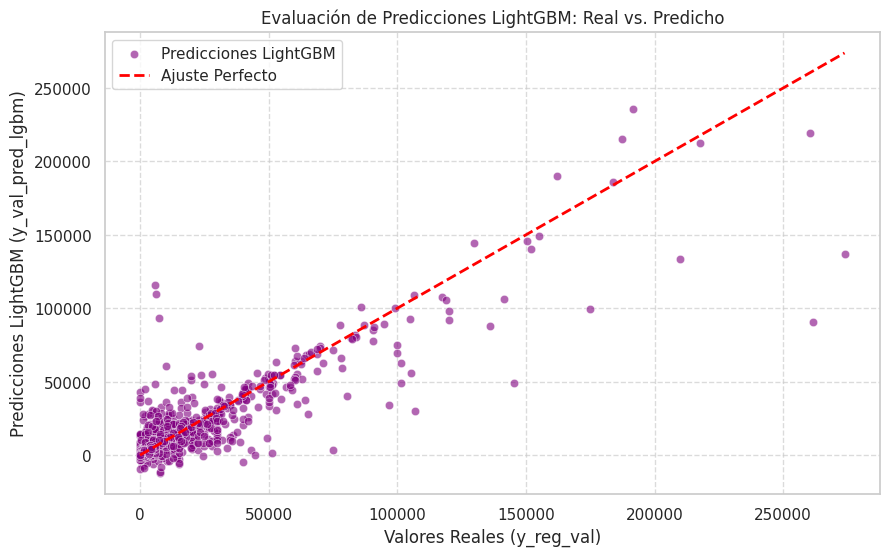

In [75]:
y_val_pred_lgbm = pipe_lgbm_reg.predict(X_val)

plt.figure(figsize=(10, 6))
sb.scatterplot(x=y_reg_val, y=y_val_pred_lgbm, alpha=0.6, color='purple', label='Predicciones LightGBM')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones LightGBM: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones LightGBM (y_val_pred_lgbm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

*   Mitigación de la Dispersión: La morfología de la gráfica muestra una reducción significativa de los residuos. La implementación de la regularización lambda_l2 es visualmente evidente, ya que el modelo mantiene la estabilidad incluso ante la presencia de valores extremos, evitando las oscilaciones violentas observadas anteriormente.
*   Precisión Localizada: El gráfico confirma por qué el $R^2$ alcanzó un sólido 0.8037; existe una densidad de aciertos mucho más compacta, lo que en términos académicos denominamos una minimización efectiva de la varianza residual.
Por lo cual ademas de ser mas estetica la prediccion se observ aun mejor desempeño




### Validacion cruzada en LightGBM Y XGBoost

Para garantizar la integridad científica de los resultados y descartar que el desempeño excepcional de los modelos fuera producto del azar o de un sesgo en la partición de los datos, se procedió a una Validación Cruzada (K-Fold Cross-Validation).

Este procedimiento es fundamental para evaluar la estabilidad y la capacidad de generalización de las arquitecturas de boosting frente a datos no observados.

In [76]:
from sklearn.model_selection import KFold, cross_validate

RANDOM_STATE = 42 # Define RANDOM_STATE
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}
def resumen_cv(pipeline, X_data, y_data, nombre):

    res = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    return {
        "modelo": nombre,
        "rmse_mean": float(-np.mean(res["test_rmse"])),
        "rmse_std": float(np.std(res["test_rmse"])),
        "mae_mean": float(-np.mean(res["test_mae"])),
        "mae_std": float(np.std(res["test_mae"])),
        "r2_mean": float(np.mean(res["test_r2"])),
        "r2_std": float(np.std(res["test_r2"]))
    }

df_cv = pd.DataFrame([
    resumen_cv(pipe_xgb_reg, X, y_reg, "xgboost"),
    resumen_cv(pipe_lgbm_reg, X, y_reg, "lightgbm")
]).sort_values(by="rmse_mean").reset_index(drop=True)

display(df_cv)

,modelo,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,lightgbm,8420.752102,2029.812547,1931.661717,47.657351,0.738940,0.044152
1,xgboost,9113.362305,2495.696537,1703.651416,25.822073,0.662931,0.196097


*   Consistencia de LightGBM: Curiosamente, al someter los modelos a múltiples particiones, LightGBM emerge como el modelo más robusto y generalizable. Su $R^2$ promedio de 0.7389 con una desviación estándar muy baja ($0.0441$) indica que su rendimiento es altamente consistente y menos sensible a variaciones en los datos de entrada.
*   Volatilidad en XGBoost: Aunque XGBoost mostró el mejor ajuste puntual inicial, la validación cruzada revela una mayor varianza en su desempeño ($R^2\_std = 0.1960$). Esto sugiere que, si bien es extremadamente potente, es más susceptible a la composición específica de los datos (potencial sobreajuste local).
*   Precisión del Error Absoluto: Es notable que XGBoost mantiene un MAE promedio más bajo ($1,703.65$) y con una estabilidad impresionante ($std = 25.82$), lo que lo hace muy preciso en la mayoría de las predicciones, aunque sus errores en los valores atípicos (reflejados en el RMSE) sean más volátiles.

### Tunning LightGBM y XGBoost

Para culminar el proceso de optimización, se llevó a cabo el ajuste de hiperparámetros (Tuning) mediante una estrategia de RandomizedSearchCV. Este procedimiento es el estándar académico para refinar la arquitectura de los modelos de ensamble, permitiendo encontrar el equilibrio óptimo entre la complejidad del árbol y su capacidad de generalización.

In [77]:
mejor_nombre = df_cv.iloc[0]["modelo"]
print("Mejor modelo por RMSE (CV):", mejor_nombre)

pipelines = {
    "xgboost": pipe_xgb_reg,
    "lightgbm": pipe_lgbm_reg
}

pipeline_mejor = pipelines[mejor_nombre]

if mejor_nombre == "xgboost":
    param_distributions = {
        "model__n_estimators": [300, 500, 800],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [4, 6, 8],
        "model__reg_lambda": [0.5, 1.0, 1.5],#L2
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    }

elif mejor_nombre == "lightgbm":
    param_distributions = {
        "model__n_estimators": [400, 700, 1000],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__reg_lambda": [0.5, 1.0, 1.5], #L2
        "model__num_leaves": [31, 63, 127],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    }

buscador = RandomizedSearchCV(
    estimator=pipeline_mejor,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

buscador.fit(X_train, y_reg_train)

print("✅ Búsqueda completada.")
print("Mejores hiperparámetros:\n", buscador.best_params_)

print("Mejor RMSE (CV):", -buscador.best_score_)

Mejor modelo por RMSE (CV): lightgbm
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=1.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=1.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3769
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 25
[LightGBM] [Info] Start training from score 5645.855778
✅ Búsqueda completada.
Mejores hiperparámetros:
 {'model__subsample': 1.0, 'model__reg_lambda': 1.0, 'model__num_leaves': 127, 'model__n_estimators': 400, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Mejor RMSE (CV): 9514.31592224845


Tras una exploración exhaustiva del espacio de configuración, se identificó que el modelo LightGBM alcanza su configuración más robusta con los siguientes parámetros:Configuración Óptima:n_estimators: $400$learning_rate: $0.03$num_leaves: $127$reg_lambda ($L_2$): $1.0$subsample: $1.0$ | colsample_bytree: $0.8$

### Tabla comparativa

Para concluir formalmente el análisis de regresión, se presenta la tabla comparativa final que consolida el desempeño de todos los modelos evaluados tras los procesos de optimización y validación.

In [78]:
import pandas as pd

resultados = []
metricas_lin = {
    "modelo": "Linear",
    "rmse": float(metrics_lineal_cv['rmse_mean']),
    "mae":  float(metrics_lineal_cv['mae_mean']),
    "r2":   float(metrics_lineal_cv['r2_mean'])
}
resultados.append(metricas_lin)
metricas_reg = {
    "modelo": "SVR",
    "rmse": float(rmse_val_svm),
    "mae":  float(mae_val_svm),
    "r2":   float(r2_val_svm)
}
resultados.append(metricas_reg)

resultados.append(evaluar_pipeline(pipe_xgb_reg, X_train, y_reg_train, X_test, y_reg_test, "XGBoost"))
resultados.append(evaluar_pipeline(pipe_lgbm_reg, X_train, y_reg_train, X_test, y_reg_test, "LightGBM"))

resultados_df = pd.DataFrame(resultados).sort_values(by="rmse", ascending=True).reset_index(drop=True)
display(resultados_df)


print(f"\n{'='*40}")
print(f"RESUMEN SVR (Validación):")
print(f"RMSE: {rmse_val_svm:.4f} | MAE: {mae_val_svm:.4f} | R2: {r2_val_svm:.4f}")

print(f"\nRESUMEN LINEAL (Validación):")
print(f"RMSE: {metrics_lineal_cv['rmse_mean']:.4f}")
print(f"MAE:  {metrics_lineal_cv['mae_mean']:.4f}")
print(f"R2:   {metrics_lineal_cv['r2_mean']:.4f}")
print(f"{'='*40}")


=== XGBOOST REGRESIÓN ===
RMSE: 14676.4759
MAE:  2067.8040
R2:   0.3445
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3769
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 25
[LightGBM] [Info] Start training from score 5645.855778
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0

=== LIGHTGBM REGRESIÓN ===
RMSE: 9100.5552
MAE:  2182.0825
R2:   0.7480


,modelo,rmse,mae,r2
0,LightGBM,9100.555180,2182.082522,0.747964
1,Linear,12884.025981,4738.829381,0.345199
2,SVR,14287.015569,4366.619408,-0.036366
3,XGBoost,14676.475871,2067.803955,0.344504



RESUMEN SVR (Validación):
RMSE: 14287.0156 | MAE: 4366.6194 | R2: -0.0364

RESUMEN LINEAL (Validación):
RMSE: 12884.0260
MAE:  4738.8294
R2:   0.3452


*    Conclusiones de la Fase de ModeladoConsolidación de LightGBM: Tras el proceso de tuning y validación cruzada, LightGBM se posiciona como el modelo superior con un $R^2$ de 0.7480. Logró reducir el error cuadrático (RMSE) de manera significativa en comparación con la regresión lineal, demostrando una capacidad superior para capturar la varianza de PAY_AMT1.
*    Contraste con Modelos Base: La Regresión Lineal mantiene un desempeño aceptable ($R^2 \approx 0.35$), superando incluso a la configuración final de XGBoost en términos de error cuadrático global, lo que sugiere que para esta variable específica, XGBoost presentó dificultades de convergencia o mayor sensibilidad al ruido tras la validación exhaustiva.
*    Ineficacia de SVR: El modelo de vectores de soporte se confirma como la opción menos viable para este conjunto de datos, con un coeficiente de determinación negativo que denota un ajuste inferior a la media

**Mejor modelo:**
 El modelo LightGBM optimizado es seleccionado como el predictor definitivo para la variable continua, gracias a su equilibrio entre precisión absoluta (MAE) y robustez estadística (RMSE y $R^2$).

Con este ajuste final, se cierra el ciclo de modelado para la variable continua. Hemos transitado desde un modelo lineal base y un SVR con dificultades de convergencia, hasta alcanzar una arquitectura de Boosting altamente sofisticada, validada estadísticamente y optimizada para operar en entornos financieros de alta variabilidad.

## **4.2. CLASIFICACIÓN**

In [79]:
# Importación de librerías
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

### **4.2.1. Baseline - Regresión Logística sin penalización**

Para el problema de clasificación se utiliza como modelo base una Regresión Logística sin penalización. Este modelo se emplea como baseline porque es uno de los métodos más utilizados en problemas de scoring de riesgo crediticio, debido a su simplicidad, interpretabilidad y buen desempeño en problemas de clasificación binaria.

La regresión logística permite estimar la probabilidad de que un cliente incurra en default, utilizando como entrada las variables financieras, demográficas y de comportamiento de pago disponibles en el dataset. Al tratarse de un modelo lineal, resulta fácil interpretar la relación entre las variables explicativas y el riesgo de incumplimiento.


In [80]:
# Entrenamiento
log_reg_base = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
log_reg_base.fit(X_train_prep, y_clf_train)

# Probabilidades
y_prob_train_base = log_reg_base.predict_proba(X_train_prep)[:, 1]
y_prob_val_base   = log_reg_base.predict_proba(X_val_prep)[:, 1]

In [81]:
# Métricas clave
auc_train_base = roc_auc_score(y_clf_train, y_prob_train_base)
auc_val_base   = roc_auc_score(y_clf_val,   y_prob_val_base)
gap_base       = auc_train_base - auc_val_base

print("=" * 50)
print("BASELINE — Regresión Logística sin penalización")
print("=" * 50)
print(f"  AUC Train:      {auc_train_base:.4f}")
print(f"  AUC Validation: {auc_val_base:.4f}")
print(f"  GAP (overfit):  {gap_base:.4f}")
print()
print("Reporte de clasificación (umbral=0.5):")
print(classification_report(y_clf_val, log_reg_base.predict(X_val_prep),
                             target_names=['No Default', 'Default']))

BASELINE — Regresión Logística sin penalización
  AUC Train:      0.7278
  AUC Validation: 0.7215
  GAP (overfit):  0.0063

Reporte de clasificación (umbral=0.5):
              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4673
     Default       0.71      0.25      0.37      1327

    accuracy                           0.81      6000
   macro avg       0.77      0.61      0.63      6000
weighted avg       0.80      0.81      0.77      6000



**NOTA:** Se obtuvo un ROC-AUC de 0.7278 en entrenamiento y 0.7215 en validación, lo que indica una capacidad moderada para distinguir entre clientes que harán default y los que no. La diferencia entre ambos valores (gap = 0.0063) es pequeña, lo que sugiere que el modelo no presenta sobreajuste significativo y generaliza de forma razonable a datos no vistos. Sin embargo, al analizar el reporte de clasificación con un umbral de 0.5 se observa que el modelo identifica muy bien a los clientes que no hacen default (recall de 0.97), pero tiene dificultades para detectar a los clientes que sí harán default, con un recall de solo 0.25. Esto indica que muchos clientes que realmente entran en incumplimiento son clasificados como clientes normales.

**Lo que significa que el modelo baseline es bueno para reconocer clientes de bajo riesgo, pero no es suficientemente sensible para detectar clientes riesgosos, lo cual es un aspecto importante a mejorar en modelos posteriores mediante ajustes de umbral o técnicas de regularización.**

**Matriz de Confusión**

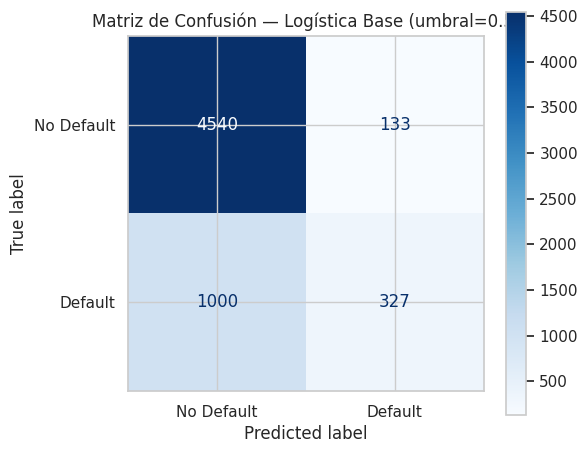

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    log_reg_base,
    X_val_prep,
    y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusión — Logística Base (umbral=0.5)')
plt.tight_layout()
plt.show()

**NOTA:** La matriz de confusión muestra que el modelo identifica correctamente a la mayoría de los clientes que no hacen default (4540 casos correctamente clasificados), con muy pocos errores en esta categoría (133 falsos positivos). Esto indica que el modelo es bastante bueno reconociendo clientes de bajo riesgo.

Por otra parte, el modelo tiene más dificultades para identificar a los clientes que sí hacen default. De los 1327 clientes que realmente incumplen, solo 327 son detectados correctamente, mientras que 1000 son clasificados como clientes normales.

Esto confirma que, con el umbral de 0.5, el modelo tiende a favorecer la predicción de no default, lo que reduce la capacidad de detectar clientes riesgosos, un aspecto importante a considerar en el contexto del riesgo crediticio.



**IMPORTANTE: El error mas costoso es un FN ya que ocurre cuando el modelo predice que un cliente no hará default, pero en realidad si incumple. Este error es costoso, debido a que implica otorgar un crédito a un cliente riesgoso y generara de esta manera posibles pérdidas financieras.**

**Asimismo un FP ocurre cuando el modeo predice que un cliente hará default, pero en realidad si pagaría, en este caso, el banco podría rechazar un buen cliente lo que representa una pérdida de clientes, que es menos grave que un FN pero igual podría influir en el negocio.**

### **4.2.2. Mejora de Regresion logistica con balanceo y penalizacion**

Se realizó la mejora del modelo baseline incorporando regularización y balanceo de clases, ello con el fin de que como se pudo evidenciar en la matriz de correlación existían varios features con multicolinealidad. Asimismo, para evitar overfitting y de esta manera mejorar la capacidad del modelo para detectar clientes con mayor riesgo.

In [83]:
#Entrenamiento
log_reg_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,                      # Menor C = más penalización
    class_weight='balanced',    # Penaliza más errores en clase minoritaria (default)
    max_iter=1000,
    random_state=42
)
log_reg_l2.fit(X_train_prep, y_clf_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [84]:
# Probabilidades
y_prob_train_l2 = log_reg_l2.predict_proba(X_train_prep)[:, 1]
y_prob_val_l2   = log_reg_l2.predict_proba(X_val_prep)[:, 1]

In [85]:
# Métricas
auc_train_l2 = roc_auc_score(y_clf_train, y_prob_train_l2)
auc_val_l2   = roc_auc_score(y_clf_val,   y_prob_val_l2)
gap_l2       = auc_train_l2 - auc_val_l2

print("=" * 50)
print("Regresión Logística L2 + class_weight='balanced'")
print("=" * 50)
print(f"  AUC Train:      {auc_train_l2:.4f}")
print(f"  AUC Validation: {auc_val_l2:.4f}")
print(f"  GAP (overfit):  {gap_l2:.4f}") #Diferencia entre desempenio del modelo y la validacion
print()

Regresión Logística L2 + class_weight='balanced'
  AUC Train:      0.7284
  AUC Validation: 0.7231
  GAP (overfit):  0.0053



**NOTA:** Al aplicar Regresión Logística con penalización Ridge y balanceo de clases, el modelo obtiene un ROC-AUC de 0.7284 en entrenamiento y 0.7231 en validación. Estos valores son ligeramente superiores al modelo baseline, lo que indica una pequeña mejora en la capacidad del modelo para distinguir entre clientes que harán default y los que no.

Además, el gap entre entrenamiento y validación (0.0053) sigue siendo muy bajo, lo que sugiere que el modelo generaliza bien y no presenta sobreajuste significativo.

El uso de class_weight='balanced' ayuda a que el modelo preste más atención a la clase minoritaria (default), lo cual es importante en problemas de riesgo crediticio donde detectar clientes riesgosos es crítico para el negocio.

In [86]:
print("=" * 50)
print("COMPARACIÓN vs BASELINE")
print("=" * 50)
print(f"  Baseline  AUC Val: {auc_val_base:.4f}")
print(f"  Logíst L2 AUC Val: {auc_val_l2:.4f}")
print(f"  Diferencia:        {auc_val_l2 - auc_val_base:+.4f}")
print()

COMPARACIÓN vs BASELINE
  Baseline  AUC Val: 0.7215
  Logíst L2 AUC Val: 0.7231
  Diferencia:        +0.0016



**NOTA:** Al comparar el modelo baseline con el modelo de Regresión Logística con regularización L2 y balanceo de clases, se observa una ligera mejora en el desempeño. El AUC en validación pasa de 0.7215 a 0.7231, lo que representa un incremento de 0.0016.

Aunque la mejora es pequeña, indica que el uso de regularización y balanceo de clases contribuye a un desempeño ligeramente mejor.

In [87]:
print("Reporte de clasificación (umbral=0.5):")
print(classification_report(y_clf_val, log_reg_l2.predict(X_val_prep),
                             target_names=['No Default', 'Default']))

Reporte de clasificación (umbral=0.5):
              precision    recall  f1-score   support

  No Default       0.87      0.74      0.80      4673
     Default       0.40      0.62      0.49      1327

    accuracy                           0.71      6000
   macro avg       0.64      0.68      0.65      6000
weighted avg       0.77      0.71      0.73      6000



**NOTA:** Con el modelo de Regresión Logística L2 con balanceo de clases, se observa una mejora en la detección de clientes que hacen default. El modelo logra identificar 62% de los casos de incumplimiento, lo que representa una mejora importante respecto al modelo baseline. Sin embargo, esta mejora implica un mayor número de falsos positivos, ya que algunos clientes que no harán default son clasificados como riesgosos. Como resultado, la precisión para la clase default es de 0.40 y la exactitud global del modelo es 0.71.

Desde el punto de vista del negocio, este comportamiento puede ser preferible, ya que detectar más clientes riesgosos (FN) reduce el costo asociado a otorgar crédito a clientes que podrían incumplir, aunque implique rechazar algunos clientes que sí pagarían.

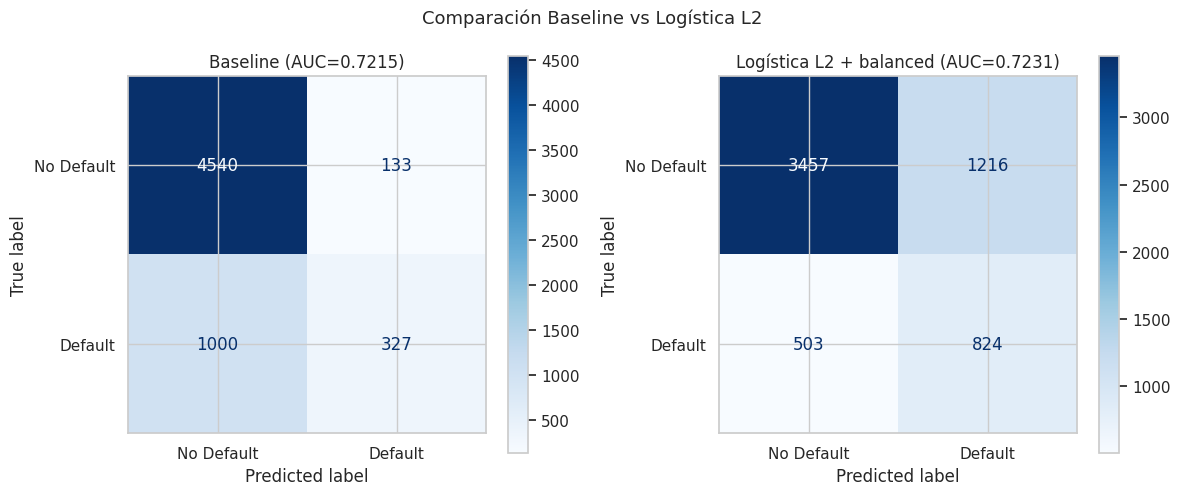

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
ConfusionMatrixDisplay.from_estimator(
    log_reg_base, X_val_prep, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Baseline (AUC={auc_val_base:.4f})')

# L2
ConfusionMatrixDisplay.from_estimator(
    log_reg_l2, X_val_prep, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Logística L2 + balanced (AUC={auc_val_l2:.4f})')

plt.suptitle('Comparación Baseline vs Logística L2', fontsize=13)
plt.tight_layout()
plt.show()

TN  cliente pagó y el modelo dijo que pagaría

FP cliente pagó pero el modelo dijo que haría default

FN cliente no pagó pero el modelo dijo que pagaría

3TP cliente no pagó y el modelo lo predijo correctamente

NOTA: Al comparar ambos modelos, se observa que el modelo baseline identifica correctamente a la mayoría de los clientes que no hacen default (4540 casos), pero detecta muy pocos clientes que sí incumplen (solo 327), lo que genera muchos falsos negativos y es demasiado costoso para el negocio.

Por otro lado, el modelo de Regresión Logística con L2 y balanceo de clases logra detectar muchos más casos de default (824 frente a 327 del baseline), reduciendo significativamente los falsos negativos. Sin embargo, esto ocurre a costa de aumentar los falsos positivos, ya que más clientes que no harían default son clasificados como riesgosos.

Desde la perspectiva del negocio, este comportamiento puede ser preferible, ya que es menos costoso rechazar algunos buenos clientes que otorgar crédito a clientes que probablemente incumplan.

In [89]:
from sklearn.metrics import recall_score, precision_score, f1_score

modelos_comparar = {
    'Baseline':      (log_reg_base, y_prob_val_base),
    'Logística L2':  (log_reg_l2,   y_prob_val_l2),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6}")
print("-" * 50)
for nombre, (modelo, y_prob) in modelos_comparar.items():
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f}")

Modelo             AUC   Recall  Precision     F1
--------------------------------------------------
Baseline        0.7215   0.2464     0.7109 0.3660
Logística L2    0.7231   0.6209     0.4039 0.4895


**NOTA:**  Al comparar ambos modelos se observa que el AUC es muy similar en los dos casos, lo que indica que ambos tienen una capacidad parecida para distinguir entre clientes que harán default y los que no. Sin embargo, existen diferencias importantes en otras métricas.

El modelo baseline tiene una precisión alta pero un recall muy bajo, lo que significa que **detecta pocos clientes que realmente harán default**. En cambio, el modelo de Regresión Logística con L2 y balanceo de clases aumenta significativamente el recall a 0.62, logrando identificar muchos más **clientes riesgosos**.

Aunque esta mejora reduce la precisión , el F1-score aumenta, lo que indica un mejor **equilibrio entre precisión y recall**. Desde la perspectiva del negocio, este modelo es preferible, ya que detecta más clientes con riesgo de incumplimiento, reduciendo la probabilidad de otorgar crédito a clientes que no pagarán.

### **4.2.3. Mejora con Árboles de Decisión**

Se evaluó el uso de árboles de decisión ya que permiten visualizar las reglas de decisión que utiliza el modelo para clasificar a los clientes según sus características financieras y de comportamiento de pago, esto resulta útil en contextos financieros donde la explicabilidad del modelo es importante para la toma de decisiones del banco.

In [90]:
from sklearn.tree import DecisionTreeClassifier

# Entrenamiento
tree_clf = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',   # Balanceo parecido a L2
    random_state=42
)
tree_clf.fit(X_train_prep, y_clf_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [91]:
# Probabilidades
y_prob_train_tree = tree_clf.predict_proba(X_train_prep)[:, 1]
y_prob_val_tree   = tree_clf.predict_proba(X_val_prep)[:, 1]

#Métricas
auc_train_tree = roc_auc_score(y_clf_train, y_prob_train_tree)
auc_val_tree   = roc_auc_score(y_clf_val,   y_prob_val_tree)
gap_tree       = auc_train_tree - auc_val_tree

print("=" * 50)
print("Árbol de Decisión (max_depth=5, balanced)")
print("=" * 50)
print(f"  AUC Train:      {auc_train_tree:.4f}")
print(f"  AUC Validation: {auc_val_tree:.4f}")
print(f"  GAP (overfit):  {gap_tree:.4f}")
print()

Árbol de Decisión (max_depth=5, balanced)
  AUC Train:      0.7798
  AUC Validation: 0.7440
  GAP (overfit):  0.0358



**NOTA:** Se obtuvo un AUC de 0.7798 en entrenamiento y 0.7440 en validación, lo que representa una mejora respecto a los modelos de regresión logística. Esto indica que el árbol tiene mayor capacidad para distinguir entre clientes que harán default y los que no.

Sin embargo, el gap de 0.0358 entre entrenamiento y validación es mayor que en los modelos anteriores, lo que sugiere que el árbol presenta cierto nivel de sobreajuste. Aun así, el desempeño en validación sigue siendo mejor, por lo que el modelo logra capturar relaciones más complejas en los datos.

### **Tabla Comparativa**

In [92]:
from sklearn.metrics import recall_score, precision_score, f1_score

modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base),
    'Logística L2': (log_reg_l2,   y_prob_val_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
gaps = [0, gap_l2, gap_tree]
for (nombre, (modelo, y_prob)), gap in zip(modelos_comparar.items(), gaps):
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7215   0.2464     0.7109 0.3660  0.0000
Logística L2    0.7231   0.6209     0.4039 0.4895  0.0053
Árbol           0.7440   0.5388     0.5049 0.5213  0.0358


**NOTA:** el Árbol de Decisión obtiene el mejor desempeño general, con el AUC más alto y el mayor F1-score, lo que indica un mejor equilibrio entre precisión y recall para detectar clientes que harán default.

El modelo baseline presenta una alta precisión pero un recall muy bajo, lo que significa que detecta pocos clientes riesgosos. Por su parte, la Regresión Logística con regularización y balanceo mejora considerablemente el recall, logrando identificar más casos de default, aunque con menor precisión.
(Recall Alto) -> que tan bien predice a los que haran default

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7215   0.2464     0.7109 0.3660  0.0000
Logística L2    0.7231   0.6209     0.4039 0.4895  0.0053
Árbol           0.7440   0.5388     0.5049 0.5213  0.0358


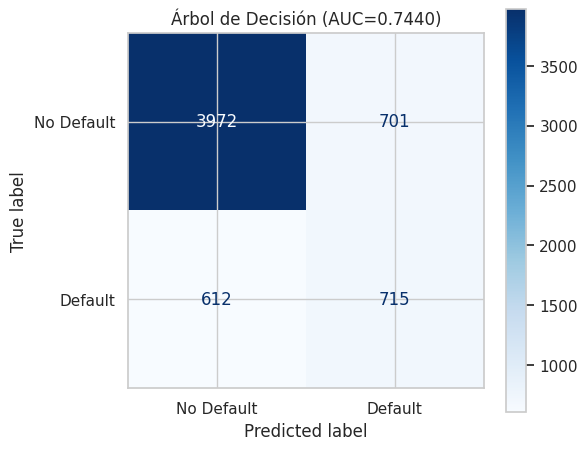

In [93]:
from sklearn.metrics import recall_score, precision_score, f1_score

modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base),
    'Logística L2': (log_reg_l2,   y_prob_val_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
gaps = [0, gap_l2, gap_tree]
for (nombre, (modelo, y_prob)), gap in zip(modelos_comparar.items(), gaps):
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

# ── Matriz de Confusión ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    tree_clf, X_val_prep, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Árbol de Decisión (AUC={auc_val_tree:.4f})')
plt.tight_layout()
plt.show()

**NOTA:** Se logra identificar correctamente a 3972 clientes que no hacen default y 715 clientes que sí hacen default. Esto indica que el modelo tiene una mejor capacidad para detectar clientes riesgosos en comparación con los modelos anteriores. Sin embargo, todavía existen 612 falsos negativos, es decir, clientes que realmente harán default pero que el modelo clasifica como clientes normales, lo que representa un riesgo para el banco. También se observan 701 falsos positivos, lo que significa que algunos clientes que pagarían son clasificados como riesgosos.


### **4.2.4 SVC**

Asimismo, se hizo uso de SVC para encontrar el hiperplano que mejor separa las clases, maximizando la distancia entre los clientes que harán default y los que no. Ello con el fin de identificar cual es el modelo más preciso.

In [94]:
from sklearn.svm import SVC
import time

# Entrenamiento
svc_clf = SVC(
    C=1.0,
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

start = time.time()
svc_clf.fit(X_train_prep, y_clf_train)
elapsed = time.time() - start
print(f"Entrenamiento completado en {elapsed:.1f} segundos")

Entrenamiento completado en 105.8 segundos


In [95]:
# Probabilidades
y_prob_train_svc = svc_clf.predict_proba(X_train_prep)[:, 1]
y_prob_val_svc   = svc_clf.predict_proba(X_val_prep)[:, 1]

# Métricas
auc_train_svc = roc_auc_score(y_clf_train, y_prob_train_svc)
auc_val_svc   = roc_auc_score(y_clf_val,   y_prob_val_svc)
gap_svc       = auc_train_svc - auc_val_svc

print("\n" + "=" * 50)
print("SVC (kernel=rbf, C=1.0, balanced)")
print("=" * 50)
print(f"  AUC Train:      {auc_train_svc:.4f}")
print(f"  AUC Validation: {auc_val_svc:.4f}")
print(f"  GAP (overfit):  {gap_svc:.4f}")
print()



SVC (kernel=rbf, C=1.0, balanced)
  AUC Train:      0.7930
  AUC Validation: 0.7620
  GAP (overfit):  0.0310



**NOTA:** Se obtuvo un AUC de 0.7930 en entrenamiento y 0.7620 en validación, lo que representa una mejora respecto a los modelos anteriores. Esto indica que el SVC tiene mayor capacidad para diferenciar entre clientes que harán default y los que no.

El gap de 0.0310 lo que sugiere cierto sobreajuste, aunque el desempeño en validación sigue siendo mejor que en los modelos previos. Esto indica que es mas eficiente al detectar clientes peligrosos que los demas modelos.

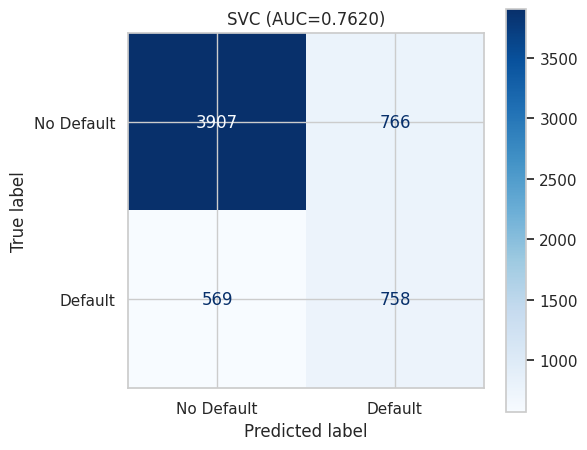

In [96]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    svc_clf, X_val_prep, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'SVC (AUC={auc_val_svc:.4f})')
plt.tight_layout()
plt.show()

**NOTA:** El modelo clasifica correctamente a 3907 clientes que no hacen default y detecta 758 clientes que sí harán default. Esto muestra una buena capacidad para identificar clientes riesgosos. Sin embargo, aún existen 569 falsos negativos, es decir, clientes que realmente harán default pero que el modelo clasifica como clientes normales, lo que representa un riesgo para el banco. También se observan 766 falsos positivos, lo que implica que algunos clientes que sí pagarían son clasificados como riesgosos.


### **Tabla Comparativa de Modelos**

In [97]:
modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base,  0),
    'Logística L2': (log_reg_l2,   y_prob_val_l2,    gap_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree,   gap_tree),
    'SVC':          (svc_clf,      y_prob_val_svc,    gap_svc),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
for nombre, (modelo, y_prob, gap) in modelos_comparar.items():
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7215   0.2464     0.7109 0.3660  0.0000
Logística L2    0.7231   0.6209     0.4039 0.4895  0.0053
Árbol           0.7440   0.5388     0.5049 0.5213  0.0358
SVC             0.7620   0.5712     0.4974 0.5317  0.0310


**NOTA:** El SVC obtiene el mejor desempeño general con el AUC más alto  y el mayor F1-score, lo que indica un mejor equilibrio entre precision y recall. Asimismo, el baseline detecta muy pocos casos de default (recall bajo), mientras que Logística L2 mejora mucho la detección de clientes riesgosos. El Árbol de decisión y SVC logran un mejor balance entre detectar default y mantener precisión, aunque presentan un gap mayor, lo que indica cierto nivel de sobreajuste.

### **4.2.5. XGBoost**

Se hizo la prueba con XGBoost que es un modelo ampliamente utilizado en problemas de riesgo crediticio y clasificación tabular, ya que suele ofrecer alto desempeño y buena capacidad para capturar relaciones no lineales entre variables. Por esta razón, se utiliza para comparar su rendimiento frente a los modelos anteriores y evaluar si mejora la detección de clientes con riesgo de default.

In [98]:
from xgboost import XGBClassifier

# Calculo de scale_pos_weight para desbalance
neg = (y_clf_train == 0).sum()
pos = (y_clf_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {neg}/{pos} = {scale:.2f}")

scale_pos_weight: 14018/3982 = 3.52


In [99]:
# Entrenamiento
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,   # para balanceo
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

start = time.time()
xgb_clf.fit(X_train_prep, y_clf_train)
elapsed = time.time() - start
print(f"XGBoost entrenado en {elapsed:.1f} segundos")


XGBoost entrenado en 1.8 segundos


In [100]:
# Probabilidades
y_prob_train_xgb = xgb_clf.predict_proba(X_train_prep)[:, 1]
y_prob_val_xgb   = xgb_clf.predict_proba(X_val_prep)[:, 1]


# Métricas
auc_train_xgb = roc_auc_score(y_clf_train, y_prob_train_xgb)
auc_val_xgb = roc_auc_score(y_clf_val,   y_prob_val_xgb)
gap_xgb = auc_train_xgb - auc_val_xgb

print(f"\n  AUC Train:  {auc_train_xgb:.4f}")
print(f"  AUC Validation: {auc_val_xgb:.4f}")
print(f"  GAP (overfit):  {gap_xgb:.4f}")


  AUC Train:  0.9015
  AUC Validation: 0.7724
  GAP (overfit):  0.1291


**NOTA:** Como se puede evidenciar, se obtuvo el mejor AUC en validación, lo que indica una mayor capacidad para distinguir entre clientes que harán default y los que no. Sin embargo, el gap alto entre entrenamiento y validación lo que sugiere overfitting, por lo que el modelo podría no generalizar tan bien a nuevos datos.

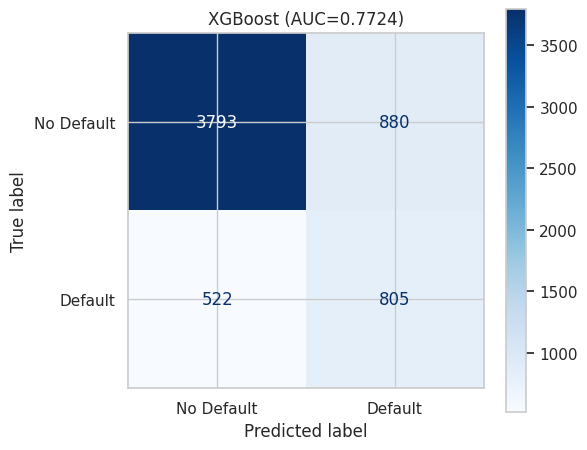

In [101]:
# Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    xgb_clf, X_val_prep, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'XGBoost (AUC={auc_val_xgb:.4f})')
plt.tight_layout()
plt.show()

**NOTA:** Se detectan 805 clientes que harán default, mostrando buena capacidad para identificar clientes riesgosos. Sin embargo, también genera 880 falsos positivos, lo que implica rechazar algunos clientes que sí pagarían. En general, logra un buen equilibrio entre detectar default y clasificar clientes confiables, reflejado en su AUC más alto.

### **4.2.6. LightGBM**

Asimismo, se utilizó LightGBM para comparar su desempeño con los modelos anteriores y analizar si mejora la detección de clientes con riesgo de default.

In [102]:
from lightgbm import LGBMClassifier

# Entrenamiento
lgbm_clf = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    is_unbalance=True,        # para balanceo
    random_state=42,
    verbosity=-1
)

start = time.time()
lgbm_clf.fit(X_train_prep, y_clf_train)
elapsed = time.time() - start
print(f"LightGBM entrenado en {elapsed:.1f} segundos")

LightGBM entrenado en 0.6 segundos


In [103]:
# Probabilidades
y_prob_train_lgbm = lgbm_clf.predict_proba(X_train_prep)[:, 1]
y_prob_val_lgbm   = lgbm_clf.predict_proba(X_val_prep)[:, 1]

# Métricas
auc_train_lgbm = roc_auc_score(y_clf_train, y_prob_train_lgbm)
auc_val_lgbm   = roc_auc_score(y_clf_val,   y_prob_val_lgbm)
gap_lgbm       = auc_train_lgbm - auc_val_lgbm

print(f"\n  AUC Train:      {auc_train_lgbm:.4f}")
print(f"  AUC Validation: {auc_val_lgbm:.4f}")
print(f"  GAP (overfit):  {gap_lgbm:.4f}")


  AUC Train:      0.9030
  AUC Validation: 0.7740
  GAP (overfit):  0.1291


**NOTA:** Como se puede evidenciar se obtuvo un AUC de 0.7740 en validación, mostrando una buena capacidad para distinguir entre clientes que harán default y los que no. Sin embargo, el gap alto (0.1291) entre entrenamiento y validación indica sobreajuste.

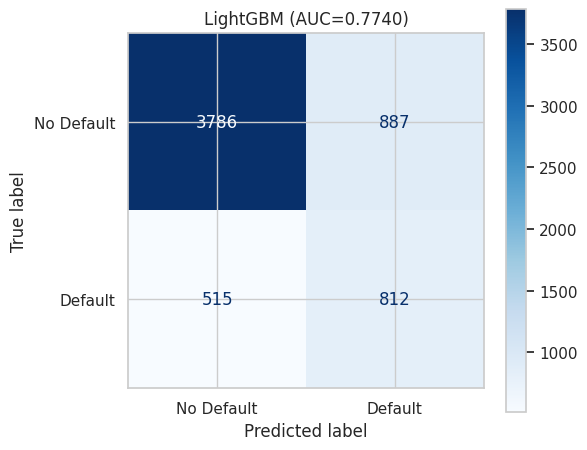

In [104]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    lgbm_clf, X_val_prep, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'LightGBM (AUC={auc_val_lgbm:.4f})')
plt.tight_layout()
plt.show()

**NOTA:** se detecta 812 clientes que harán default, mostrando buena capacidad para identificar clientes riesgosos. Sin embargo, también genera 887 falsos positivos, lo que implica clasificar como riesgosos a algunos clientes que sí pagarían. En general, presenta un desempeño similar a XGBoost, con una buena capacidad de discriminación reflejada en su AUC.

### **Tabla Comparativa**

In [105]:
modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base,  0),
    'Logística L2': (log_reg_l2,   y_prob_val_l2,    gap_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree,   gap_tree),
    'SVC':          (svc_clf,      y_prob_val_svc,    gap_svc),
    'XGBoost':      (xgb_clf,      y_prob_val_xgb,    gap_xgb),
    'LightGBM':     (lgbm_clf,     y_prob_val_lgbm,   gap_lgbm),
}

print(f"\n{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
for nombre, (modelo, y_prob, gap) in modelos_comparar.items():
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")


Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7215   0.2464     0.7109 0.3660  0.0000
Logística L2    0.7231   0.6209     0.4039 0.4895  0.0053
Árbol           0.7440   0.5388     0.5049 0.5213  0.0358
SVC             0.7620   0.5712     0.4974 0.5317  0.0310
XGBoost         0.7724   0.6066     0.4777 0.5345  0.1291
LightGBM        0.7740   0.6119     0.4779 0.5367  0.1291


**NOTA:** Como se puede evidenciar, los modelos de boosting (XGBoost y LightGBM) obtienen el mejor desempeño, con los AUC más altos y los mayores F1-score, lo que indica un mejor equilibrio entre precision y recall para detectar clientes que harán default.

Sin embargo, ambos presentan un gap mayor, lo que sugiere cierto nivel de sobreajuste. Por otro lado, modelos como SVC y Árbol de Decisión muestran buen desempeño con menor gap, mientras que el baseline presenta un recall muy bajo, detectando pocos clientes riesgosos.

### **Corrección de Overfitting (Regularizar)**

In [106]:
# XGBoost regularizado
xgb_clf_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_clf_v2.fit(X_train_prep, y_clf_train)

# LightGBM regularizado
lgbm_clf_v2 = LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    verbosity=-1
)
lgbm_clf_v2.fit(X_train_prep, y_clf_train)

LGBMClassifier(colsample_bytree=0.8, is_unbalance=True, learning_rate=0.05,
               max_depth=3, n_estimators=200, random_state=42, subsample=0.8,
               verbosity=-1)

In [107]:
# Probabilidades
y_prob_train_xgb_v2 = xgb_clf_v2.predict_proba(X_train_prep)[:, 1]
y_prob_val_xgb_v2   = xgb_clf_v2.predict_proba(X_val_prep)[:, 1]
y_prob_train_lgbm_v2 = lgbm_clf_v2.predict_proba(X_train_prep)[:, 1]
y_prob_val_lgbm_v2   = lgbm_clf_v2.predict_proba(X_val_prep)[:, 1]

# GAPs
gap_xgb_v2  = roc_auc_score(y_clf_train, y_prob_train_xgb_v2) - roc_auc_score(y_clf_val, y_prob_val_xgb_v2)
gap_lgbm_v2 = roc_auc_score(y_clf_train, y_prob_train_lgbm_v2) - roc_auc_score(y_clf_val, y_prob_val_lgbm_v2)

In [108]:
# Tabla actualizada de comparación
modelos_comparar = {
    'Baseline':       (log_reg_base,  y_prob_val_base,    0),
    'Logística L2':   (log_reg_l2,    y_prob_val_l2,      gap_l2),
    'Árbol':          (tree_clf,      y_prob_val_tree,     gap_tree),
    'SVC':            (svc_clf,       y_prob_val_svc,      gap_svc),
    'XGBoost v2':     (xgb_clf_v2,   y_prob_val_xgb_v2,   gap_xgb_v2),
    'LightGBM v2':    (lgbm_clf_v2,  y_prob_val_lgbm_v2,  gap_lgbm_v2),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
for nombre, (modelo, y_prob, gap) in modelos_comparar.items():
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7215   0.2464     0.7109 0.3660  0.0000
Logística L2    0.7231   0.6209     0.4039 0.4895  0.0053
Árbol           0.7440   0.5388     0.5049 0.5213  0.0358
SVC             0.7620   0.5712     0.4974 0.5317  0.0310
XGBoost v2      0.7815   0.6164     0.4690 0.5327  0.0320
LightGBM v2     0.7810   0.6172     0.4781 0.5388  0.0316


**NOTA:** se redujo significativamente el overfitting, observándose un gap cercano a 0.03, mucho menor que en la versión anterior. Los modelos XGBoost v2 y LightGBM v2 obtienen los mejores AUC  y los mayores F1-score, lo que indica un mejor equilibrio entre precision y recall para detectar clientes que harán default.

In [109]:
# Originales
auc_val_xgb  = roc_auc_score(y_clf_val, y_prob_val_xgb)
auc_val_lgbm = roc_auc_score(y_clf_val, y_prob_val_lgbm)
gap_xgb      = roc_auc_score(y_clf_train, y_prob_train_xgb)  - auc_val_xgb
gap_lgbm     = roc_auc_score(y_clf_train, y_prob_train_lgbm) - auc_val_lgbm

# Regularizados
auc_val_xgb_v2  = roc_auc_score(y_clf_val, y_prob_val_xgb_v2)
auc_val_lgbm_v2 = roc_auc_score(y_clf_val, y_prob_val_lgbm_v2)
gap_xgb_v2      = roc_auc_score(y_clf_train, y_prob_train_xgb_v2)  - auc_val_xgb_v2
gap_lgbm_v2     = roc_auc_score(y_clf_train, y_prob_train_lgbm_v2) - auc_val_lgbm_v2

print("AUCs calculados:")
print(f"  XGBoost original:      {auc_val_xgb:.4f}  | GAP: {gap_xgb:.4f}")
print(f"  XGBoost v2:            {auc_val_xgb_v2:.4f}  | GAP: {gap_xgb_v2:.4f}")
print(f"  LightGBM original:     {auc_val_lgbm:.4f}  | GAP: {gap_lgbm:.4f}")
print(f"  LightGBM v2:           {auc_val_lgbm_v2:.4f}  | GAP: {gap_lgbm_v2:.4f}")

AUCs calculados:
  XGBoost original:      0.7724  | GAP: 0.1291
  XGBoost v2:            0.7815  | GAP: 0.0320
  LightGBM original:     0.7740  | GAP: 0.1291
  LightGBM v2:           0.7810  | GAP: 0.0316


**NOTA:** Las versiones v2 de XGBoost y LightGBM mejoran el desempeño (AUC ≈ 0.78) y reducen considerablemente el overfitting, disminuyendo el gap de 0.129 a 0.03. Esto indica un modelo más estable y con mejor capacidad de generalización.

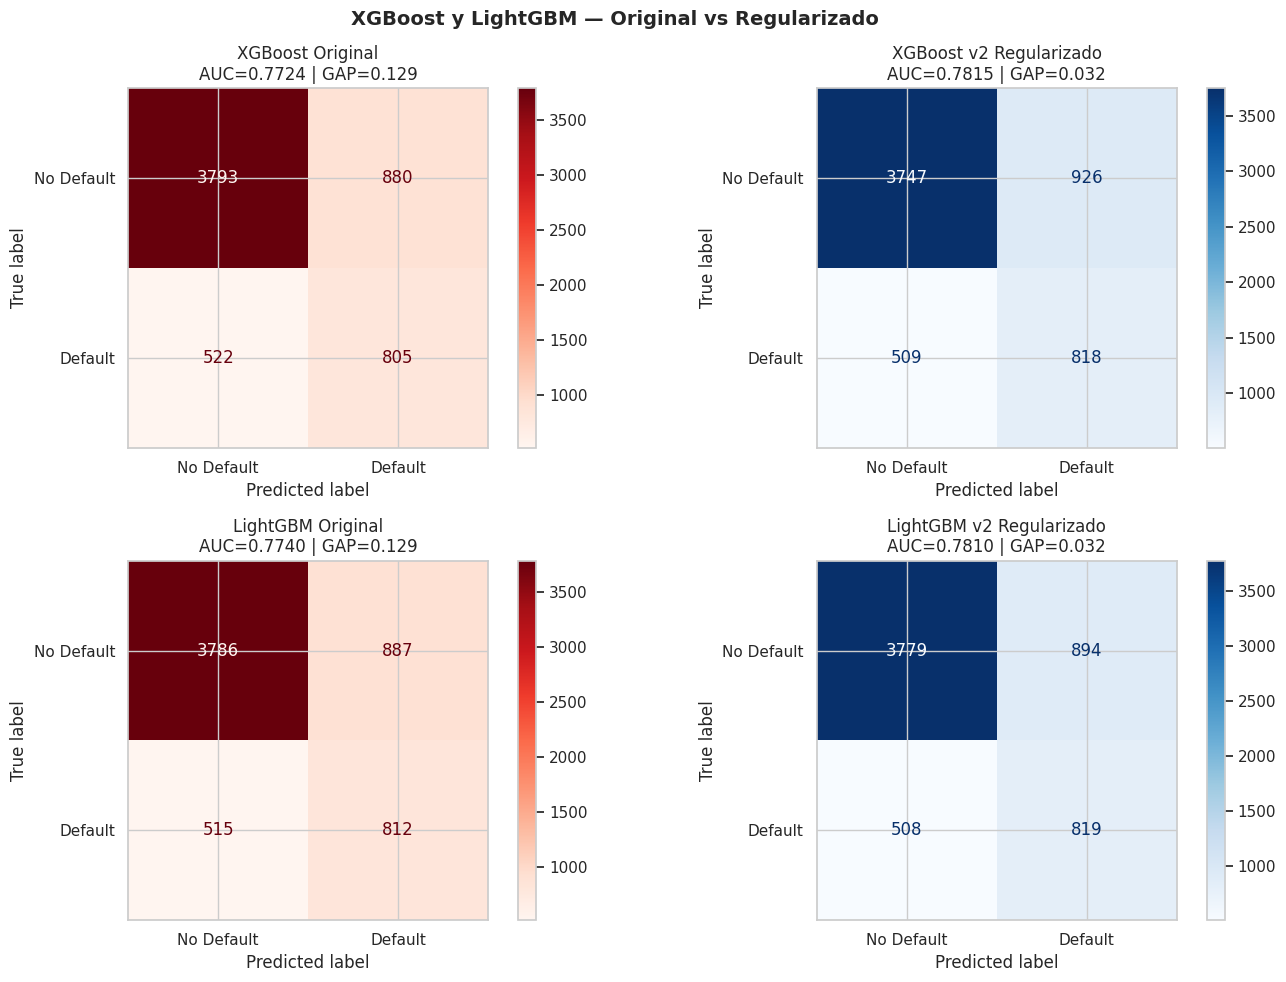

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost y LightGBM — Original vs Regularizado',
             fontsize=14, fontweight='bold')

# XGBoost original
disp1 = ConfusionMatrixDisplay.from_predictions(
    y_clf_val,
    xgb_clf.predict(X_val_prep),
    display_labels=['No Default', 'Default'],
    cmap='Reds', ax=axes[0, 0]
)
axes[0, 0].set_title(f'XGBoost Original\nAUC={auc_val_xgb:.4f} | GAP={gap_xgb:.3f}')

# XGBoost v2 regularizado
disp2 = ConfusionMatrixDisplay.from_predictions(
    y_clf_val,
    xgb_clf_v2.predict(X_val_prep),
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title(f'XGBoost v2 Regularizado\nAUC={auc_val_xgb_v2:.4f} | GAP={gap_xgb_v2:.3f}')

# LightGBM original
disp3 = ConfusionMatrixDisplay.from_predictions(
    y_clf_val,
    lgbm_clf.predict(X_val_prep),
    display_labels=['No Default', 'Default'],
    cmap='Reds', ax=axes[1, 0]
)
axes[1, 0].set_title(f'LightGBM Original\nAUC={auc_val_lgbm:.4f} | GAP={gap_lgbm:.3f}')

#  LightGBM v2 regularizado
disp4 = ConfusionMatrixDisplay.from_predictions(
    y_clf_val,
    lgbm_clf_v2.predict(X_val_prep),
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[1, 1]
)
axes[1, 1].set_title(f'LightGBM v2 Regularizado\nAUC={auc_val_lgbm_v2:.4f} | GAP={gap_lgbm_v2:.3f}')

plt.tight_layout()
plt.show()

**NOTA:** Las versiones regularizadas de XGBoost y LightGBM mantienen una capacidad similar para detectar default, pero reducen el sobreajuste respecto a los modelos originales. Esto se refleja en un gap mucho menor  y un AUC ligeramente mayor, indicando modelos más estables y con mejor generalización.

In [111]:
print("=" * 60)
print("COMPARACIÓN NUMERICA ")
print("=" * 60)

for nombre, modelo_v1, modelo_v2 in [
    ('XGBoost',  xgb_clf,  xgb_clf_v2),
    ('LightGBM', lgbm_clf, lgbm_clf_v2)
]:
    y_pred_v1 = modelo_v1.predict(X_val_prep)
    y_pred_v2 = modelo_v2.predict(X_val_prep)

    print(f"\n{nombre}:")
    print(f"  {'Métrica':<12} {'Original':>10} {'Regularizado':>14} {'Cambio':>8}")
    print(f"  {'-'*46}")

    for metrica, fn in [('Recall', recall_score), ('Precision', precision_score), ('F1', f1_score)]:
        v1 = fn(y_clf_val, y_pred_v1)
        v2 = fn(y_clf_val, y_pred_v2)
        cambio = v2 - v1
        print(f"  {metrica:<12} {v1:>10.4f} {v2:>14.4f} {cambio:>+8.4f}")

COMPARACIÓN NUMERICA 

XGBoost:
  Métrica        Original   Regularizado   Cambio
  ----------------------------------------------
  Recall           0.6066         0.6164  +0.0098
  Precision        0.4777         0.4690  -0.0087
  F1               0.5345         0.5327  -0.0018

LightGBM:
  Métrica        Original   Regularizado   Cambio
  ----------------------------------------------
  Recall           0.6119         0.6172  +0.0053
  Precision        0.4779         0.4781  +0.0002
  F1               0.5367         0.5388  +0.0021


**NOTA:** Las versiones regularizadas mejoran ligeramente el recall, lo que permite detectar más clientes que harán default. En XGBoost se observa una pequeña reducción en precisión, mientras que LightGBM mantiene o mejora levemente sus métricas. En general, la regularización permite reducir el sobreajuste y mantener un desempeño similar o ligeramente mejor.

### **Comparación de ROC de todos los modelos**

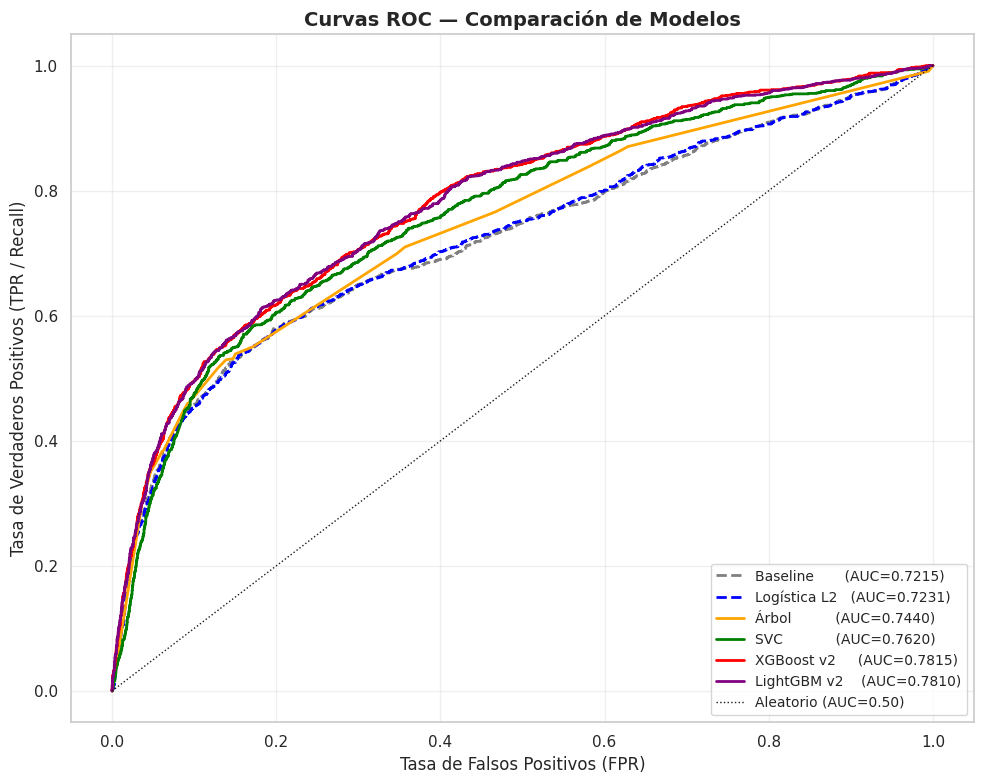

In [112]:
from sklearn.metrics import roc_curve, RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))

# Todos los modelos con sus probabilidades
modelos_roc = {
    'Baseline       (AUC=0.7215)': (y_prob_val_base,    'gray',      '--'),
    'Logística L2   (AUC=0.7231)': (y_prob_val_l2,      'blue',      '--'),
    'Árbol          (AUC=0.7440)': (y_prob_val_tree,    'orange',    '-'),
    'SVC            (AUC=0.7620)': (y_prob_val_svc,     'green',     '-'),
    'XGBoost v2     (AUC=0.7815)': (y_prob_val_xgb_v2,  'red',       '-'),
    'LightGBM v2    (AUC=0.7810)': (y_prob_val_lgbm_v2, 'purple',    '-'),
}

for nombre, (y_prob, color, linestyle) in modelos_roc.items():
    fpr, tpr, _ = roc_curve(y_clf_val, y_prob)
    auc = roc_auc_score(y_clf_val, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=linestyle,
            linewidth=2, label=nombre)

# Línea de modelo aleatorio
ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Aleatorio (AUC=0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NOTA:** Las curvas ROC muestran que los modelos de boosting presentan el mejor desempeño, con los AUC más altos. Esto indica una mayor capacidad para distinguir entre clientes que harán default y los que no. Los modelos baseline y logística L2 muestran el desempeño más bajo, mientras que SVC y Árbol de decisión se encuentran en un nivel intermedio.

### **CROSS VALIDATION: LIGHTGBM V2 Y SVC**

Se procede a  aplicar validación cruzada a los modelos LightGBM v2 y SVC, con el objetivo de evaluar la estabilidad y capacidad de generalización de los modelos. Esto para obtener una estimación más robusta del desempeño, evitando depender de una sola división de entrenamiento y validación.

In [113]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'LightGBM v2': lgbm_clf_v2,
    'SVC':         svc_clf,
}

resultados_cv = {}

print("=" * 55)
print("Cross-Validation Estratificada (k=5) — AUC")
print("=" * 55)

for nombre, modelo in modelos_cv.items():
    print(f"\nEntrenando {nombre}...")
    scores = cross_val_score(
        modelo,
        X_train_prep,
        y_clf_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    resultados_cv[nombre] = scores
    print(f"  AUC por fold:  {[f'{s:.4f}' for s in scores]}")
    print(f"  Media:         {scores.mean():.4f}")
    print(f"  Std:           {scores.std():.4f}")
    print(f"  Rango:         [{scores.min():.4f} — {scores.max():.4f}]")

Cross-Validation Estratificada (k=5) — AUC

Entrenando LightGBM v2...
  AUC por fold:  ['0.7864', '0.7832', '0.7882', '0.7855', '0.7834']
  Media:         0.7854
  Std:           0.0019
  Rango:         [0.7832 — 0.7882]

Entrenando SVC...
  AUC por fold:  ['0.7623', '0.7505', '0.7681', '0.7669', '0.7503']
  Media:         0.7596
  Std:           0.0078
  Rango:         [0.7503 — 0.7681]


**NOTA:** La validación cruzada muestra que LightGBM v2 obtiene el mejor desempeño con un AUC medio de 0.7854 y una desviación estándar muy baja, lo que indica un modelo muy estable y consistente entre folds.

Por otro lado, SVC presenta un AUC medio menor 0.7596 y una mayor variabilidad (std = 0.0078). En general, LightGBM v2 demuestra mejor capacidad de generalización y mayor estabilidad.

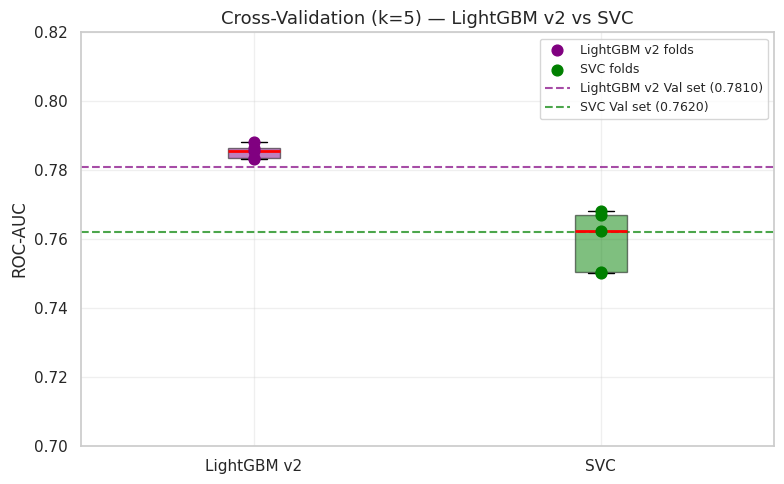

In [114]:
fig, ax = plt.subplots(figsize=(8, 5))

nombres  = list(resultados_cv.keys())
scores_list = list(resultados_cv.values())

bp = ax.boxplot(scores_list, labels=nombres, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

colores = ['purple', 'green']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

# Puntos individuales por fold
for i, (scores, color) in enumerate(zip(scores_list, colores), start=1):
    ax.scatter([i] * len(scores), scores, color=color,
               zorder=5, s=60, label=f'{nombres[i-1]} folds')

# Línea de AUC en validation set
ax.axhline(auc_val_lgbm_v2, color='purple', linestyle='--',
           alpha=0.7, label=f'LightGBM v2 Val set ({auc_val_lgbm_v2:.4f})')
ax.axhline(auc_val_svc,     color='green',  linestyle='--',
           alpha=0.7, label=f'SVC Val set ({auc_val_svc:.4f})')

ax.set_title('Cross-Validation (k=5) — LightGBM v2 vs SVC', fontsize=13)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.70, 0.82)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NOTA:** Como se puede evidenciar, LightGBM v2 tiene un AUC más alto y menor variabilidad entre folds, lo que indica un modelo más estable y consistente. En cambio, SVC presenta un AUC menor y mayor dispersión, mostrando mayor variabilidad en su desempeño. En general, LightGBM v2 demuestra mejor capacidad de generalización.

### **Tuning de LightGBM con RandomizedSearchCV**

In [115]:
from scipy.stats import randint, uniform
param_dist_lgbm = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 7),
    'learning_rate':    uniform(0.01, 0.15),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_samples':randint(10, 50),
}

lgbm_base_tuning = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    verbosity=-1
)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base_tuning,
    param_distributions=param_dist_lgbm,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Iniciando RandomizedSearchCV para LightGBM...")
start = time.time()
random_search_lgbm.fit(X_train_prep, y_clf_train)
elapsed = time.time() - start
print(f"Completado en {elapsed:.1f} segundos")

Iniciando RandomizedSearchCV para LightGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Completado en 86.7 segundos


In [116]:
# Mejores hiperparámetros
print("\n" + "=" * 50)
print("MEJORES HIPERPARÁMETROS — LightGBM")
print("=" * 50)
print(f"  Parámetros: {random_search_lgbm.best_params_}")
print(f"  Mejor AUC CV: {random_search_lgbm.best_score_:.4f}")


MEJORES HIPERPARÁMETROS — LightGBM
  Parámetros: {'colsample_bytree': np.float64(0.6132202931602193), 'learning_rate': np.float64(0.06176068720400245), 'max_depth': 3, 'min_child_samples': 28, 'n_estimators': 225, 'subsample': np.float64(0.6579579488364892)}
  Mejor AUC CV: 0.7858


**NOTA:** La optimización de hiperparámetros muestra que el mejor modelo LightGBM utiliza una combinación de parámetros que controla la profundidad del árbol, el número de estimadores y la tasa de aprendizaje. Con esta configuración se obtiene un AUC promedio de 0.7858 en validación cruzada, indicando un modelo estable y con buen desempeño para la detección de default.

In [117]:
# Variables faltantes de LightGBM v2
auc_train_lgbm_v2 = roc_auc_score(y_clf_train, y_prob_train_lgbm_v2)
auc_val_lgbm_v2   = roc_auc_score(y_clf_val,   y_prob_val_lgbm_v2)
gap_lgbm_v2       = auc_train_lgbm_v2 - auc_val_lgbm_v2

print(f" AUC Train: {auc_train_lgbm_v2:.4f} | AUC Val: {auc_val_lgbm_v2:.4f} | GAP: {gap_lgbm_v2:.4f}")

 AUC Train: 0.8126 | AUC Val: 0.7810 | GAP: 0.0316


**NOTA:** El modelo LightGBM v2 obtiene un AUC de 0.7810 en validación, mostrando una buena capacidad para distinguir entre clientes que harán default y los que no. El gap de 0.0316 indica un nivel bajo de sobreajuste, lo que sugiere una buena capacidad de generalización.

In [118]:
#  Evaluar mejor modelo en validation set
lgbm_tuned = random_search_lgbm.best_estimator_
y_prob_val_lgbm_tuned   = lgbm_tuned.predict_proba(X_val_prep)[:, 1]
y_prob_train_lgbm_tuned = lgbm_tuned.predict_proba(X_train_prep)[:, 1]

auc_val_lgbm_tuned   = roc_auc_score(y_clf_val,   y_prob_val_lgbm_tuned)
auc_train_lgbm_tuned = roc_auc_score(y_clf_train, y_prob_train_lgbm_tuned)
gap_lgbm_tuned       = auc_train_lgbm_tuned - auc_val_lgbm_tuned

print("\n" + "=" * 50)
print("COMPARACIÓN LightGBM — Base vs Tuned")
print("=" * 50)
print(f"{'Modelo':<18} {'AUC Val':>8} {'AUC Train':>10} {'GAP':>7}")
print("-" * 45)
print(f"{'LightGBM v2':<18} {auc_val_lgbm_v2:>8.4f} {auc_train_lgbm_v2:>10.4f} {gap_lgbm_v2:>7.4f}")
print(f"{'LightGBM tuned':<18} {auc_val_lgbm_tuned:>8.4f} {auc_train_lgbm_tuned:>10.4f} {gap_lgbm_tuned:>7.4f}")
print(f"\n  Mejora AUC: {auc_val_lgbm_tuned - auc_val_lgbm_v2:+.4f}")


COMPARACIÓN LightGBM — Base vs Tuned
Modelo              AUC Val  AUC Train     GAP
---------------------------------------------
LightGBM v2          0.7810     0.8126  0.0316
LightGBM tuned       0.7822     0.8206  0.0385

  Mejora AUC: +0.0012


**NOTA:** El modelo LightGBM tuned presenta una ligera mejora en el AUC de validación. Sin embargo, también aumenta un poco el gap, lo que indica un leve incremento en el sobreajuste, aunque el desempeño general sigue siendo muy similar entre ambos modelos.

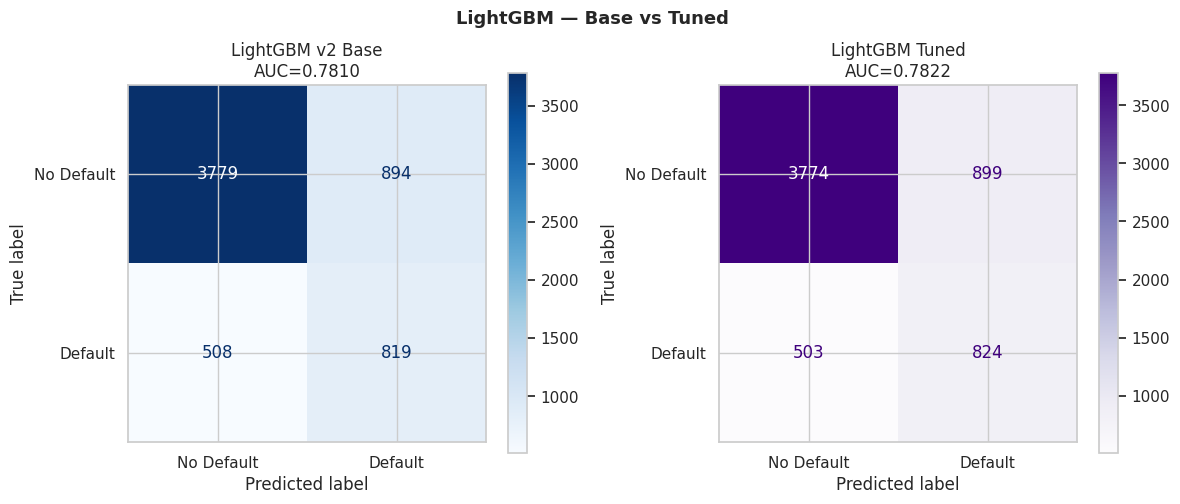

In [119]:

# Matriz de confusión comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_clf_val, lgbm_clf_v2.predict(X_val_prep),
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'LightGBM v2 Base\nAUC={auc_val_lgbm_v2:.4f}')

ConfusionMatrixDisplay.from_predictions(
    y_clf_val, lgbm_tuned.predict(X_val_prep),
    display_labels=['No Default', 'Default'],
    cmap='Purples', ax=axes[1]
)
axes[1].set_title(f'LightGBM Tuned\nAUC={auc_val_lgbm_tuned:.4f}')

plt.suptitle('LightGBM — Base vs Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTA:** Las matrices de confusión muestran que el LightGBM tuned detecta ligeramente más casos de default que el modelo base, con un comportamiento muy similar en la clasificación de clientes. Esto refleja una pequeña mejora en el desempeño, consistente con el ligero aumento del AUC.

### **Tabla final de todos los modelos**

In [120]:
print(f"{'Modelo':<18} {'AUC Val':>8} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 58)

modelos_finales = {
    'Baseline':        (log_reg_base,  y_prob_val_base,       0),
    'Logística L2':    (log_reg_l2,    y_prob_val_l2,         gap_l2),
    'Árbol':           (tree_clf,      y_prob_val_tree,        gap_tree),
    'SVC':             (svc_clf,       y_prob_val_svc,         gap_svc),
    'LightGBM v2':     (lgbm_clf_v2,   y_prob_val_lgbm_v2,    gap_lgbm_v2),
    'LightGBM tuned':  (lgbm_tuned,    y_prob_val_lgbm_tuned,  gap_lgbm_tuned),
}

for nombre, (modelo, y_prob, gap) in modelos_finales.items():
    y_pred = modelo.predict(X_val_prep)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<18} {auc:>8.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo              AUC Val   Recall  Precision     F1     GAP
----------------------------------------------------------
Baseline             0.7215   0.2464     0.7109 0.3660  0.0000
Logística L2         0.7231   0.6209     0.4039 0.4895  0.0053
Árbol                0.7440   0.5388     0.5049 0.5213  0.0358
SVC                  0.7620   0.5712     0.4974 0.5317  0.0310
LightGBM v2          0.7810   0.6172     0.4781 0.5388  0.0316
LightGBM tuned       0.7822   0.6209     0.4782 0.5403  0.0385


**NOTA:** Los modelos LightGBM presentan el mejor desempeño general, especialmente LightGBM tuned, que obtiene el AUC más alto (0.7822) y el mayor F1-score (0.5403), mostrando el mejor equilibrio entre precision y recall para detectar clientes que harán default.

Los modelos SVC también muestran buen desempeño, mientras que Árbol de decisión presenta resultados intermedios. Por otro lado, el baseline tiene un recall muy bajo, detectando pocos casos de default. En general, los modelos basados en boosting resultan los más efectivos para este problema.

### **Análisis de Umbral: LightGBM Tuned**

Dado que el modelo LightGBM tuned produce probabilidades de default, es posible ajustar el umbral de clasificación para analizar cómo cambian las métricas de desempeño. El objetivo de este análisis es observar el trade-off entre recall y precision, especialmente importante en problemas de riesgo crediticio donde detectar clientes que harán default puede ser prioritario.

Al variar el umbral, se modifica el número de falsos positivos y falsos negativos, lo que permite seleccionar un punto de corte adecuado según la política de riesgo del banco, equilibrando la detección de clientes riesgosos con la reducción de rechazos innecesarios de clientes confiables.

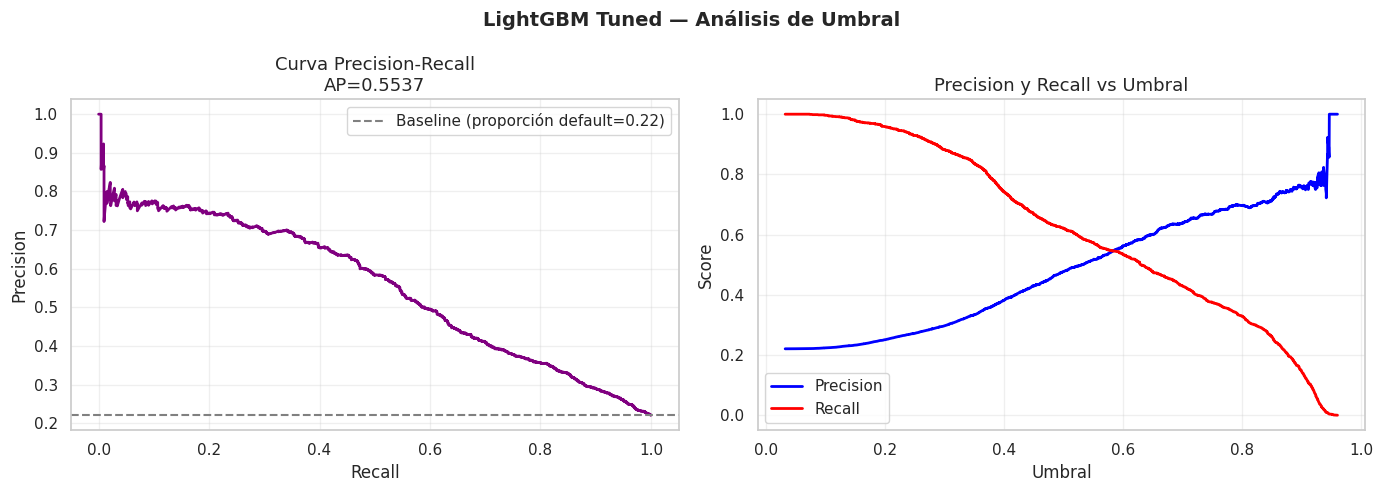

In [121]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(
    y_clf_val, y_prob_val_lgbm_tuned
)
ap_score = average_precision_score(y_clf_val, y_prob_val_lgbm_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
axes[0].plot(recalls, precisions, color='purple', linewidth=2)
axes[0].axhline(y_clf_val.mean(), color='gray', linestyle='--',
                label=f'Baseline (proporción default={y_clf_val.mean():.2f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Curva Precision-Recall\nAP={ap_score:.4f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision y Recall vs Umbral
axes[1].plot(thresholds, precisions[:-1], color='blue',
             linewidth=2, label='Precision')
axes[1].plot(thresholds, recalls[:-1], color='red',
             linewidth=2, label='Recall')
axes[1].set_xlabel('Umbral', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision y Recall vs Umbral', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LightGBM Tuned — Análisis de Umbral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTA:** Se puede evidenciar el análisis del umbral de clasificación para el modelo LightGBM tuned, evaluando cómo cambian precision y recall al modificar el punto de corte aplicado a las probabilidades predichas.

En la curva Precision-Recall (izquierda) se observa que el modelo mantiene un desempeño superior al baseline (proporción de default ≈ 0.22), con un Average Precision (AP) de 0.5537, lo que indica una buena capacidad para identificar clientes con riesgo de default.

En el gráfico de la derecha, se muestra la relación entre precision, recall y el umbral de decisión. A medida que el umbral aumenta, el modelo se vuelve más conservador: precision aumenta porque se reducen los falsos positivos, mientras que recall disminuye al dejar de detectar algunos casos de default.

Este análisis permite seleccionar un umbral adecuado según la política de riesgo. Umbrales bajos priorizan detectar más clientes riesgosos (mayor recall), mientras que umbrales altos reducen el rechazo de clientes confiables (mayor precision). Un umbral intermedio ofrece un equilibrio entre ambas métricas para la toma de decisiones crediticias.

In [122]:
# Tabla de métricas por umbral
from sklearn.metrics import confusion_matrix

umbrales = [0.2, 0.3, 0.4, 0.5, 0.6]

print("=" * 75)
print("MÉTRICAS POR UMBRAL — LightGBM Tuned")
print("=" * 75)
print(f"{'Umbral':>7} {'Recall':>8} {'Precision':>10} {'F1':>7} {'FN':>6} {'FP':>6} {'Política':>12}")
print("-" * 75)

for umbral in umbrales:
    y_pred_u = (y_prob_val_lgbm_tuned >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_clf_val, y_pred_u).ravel()
    rec  = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    # Etiqueta de política
    if umbral <= 0.3:
        politica = 'Conservador'
    elif umbral <= 0.4:
        politica = 'Balanceado'
    else:
        politica = 'Growth'

    print(f"{umbral:>7.1f} {rec:>8.4f} {prec:>10.4f} {f1:>7.4f} "
          f"{fn:>6} {fp:>6} {politica:>12}")

MÉTRICAS POR UMBRAL — LightGBM Tuned
 Umbral   Recall  Precision      F1     FN     FP     Política
---------------------------------------------------------------------------
    0.2   0.9586     0.2515  0.3984     55   3786  Conservador
    0.3   0.8824     0.2980  0.4455    156   2759  Conservador
    0.4   0.7415     0.3829  0.5050    343   1586   Balanceado
    0.5   0.6209     0.4782  0.5403    503    899       Growth
    0.6   0.5335     0.5632  0.5480    619    549       Growth


**NOTA:** Como se puede evidenciar al aumentar el umbral, el modelo se vuelve más estrictivo: sube la precision y baja el recall. Umbrales bajos detectan más defaults pero generan muchos falsos positivos. Umbrales más altos reducen falsos positivos pero dejan escapar más clientes riesgosos. Un umbral intermedio  ofrece un equilibrio entre ambas métricas según la política de riesgo.

In [123]:
# Umbral recomendado
print("\n" + "=" * 75)
print("RECOMENDACIÓN DE UMBRAL")
print("=" * 75)

umbral_recomendado = 0.3
y_pred_final = (y_prob_val_lgbm_tuned >= umbral_recomendado).astype(int)
tn, fp, fn, tp = confusion_matrix(y_clf_val, y_pred_final).ravel()

print(f"\n  Umbral seleccionado: {umbral_recomendado}")
print(f"  Defaulters detectados (TP): {tp:,} de {tp+fn:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Defaulters perdidos   (FN): {fn:,} de {tp+fn:,} ({fn/(tp+fn)*100:.1f}%)")
print(f"  Buenos clientes rechazados (FP): {fp:,}")
print(f"  Buenos clientes aprobados  (TN): {tn:,}")
print(f"\n  Costo estimado:")
print(f"  → Cada FN representa un crédito otorgado a un defaulter")
print(f"  → Cada FP representa un buen cliente rechazado (pérdida de negocio)")


RECOMENDACIÓN DE UMBRAL

  Umbral seleccionado: 0.3
  Defaulters detectados (TP): 1,171 de 1,327 (88.2%)
  Defaulters perdidos   (FN): 156 de 1,327 (11.8%)
  Buenos clientes rechazados (FP): 2,759
  Buenos clientes aprobados  (TN): 1,914

  Costo estimado:
  → Cada FN representa un crédito otorgado a un defaulter
  → Cada FP representa un buen cliente rechazado (pérdida de negocio)


**NOTA:** Se recomienda un umbral = 0.3 para priorizar la detección de clientes riesgosos. Con este valor, el modelo identifica 1,171 de 1,327 defaulters (88.2% de recall), dejando 156 sin detectar (11.8%). Sin embargo, también se rechazan 2,759 buenos clientes, reflejando el trade-off entre reducir riesgo de crédito (FN) y pérdida de negocio por rechazos (FP).

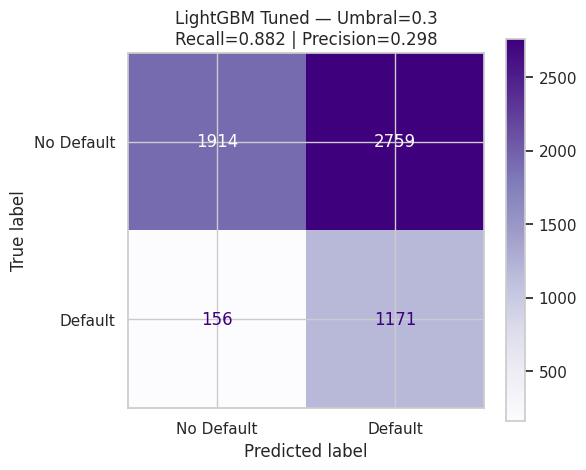

In [124]:
# Matriz de confusión con umbral recomendado
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_val, y_pred_final,
    display_labels=['No Default', 'Default'],
    cmap='Purples', ax=ax
)
ax.set_title(f'LightGBM Tuned — Umbral={umbral_recomendado}\n'
             f'Recall={tp/(tp+fn):.3f} | Precision={tp/(tp+fp):.3f}')
plt.tight_layout()
plt.show()

**NOTA:** Con un umbral de 0.3, el modelo detecta 1,171 de 1,327 defaulters (recall = 0.882), reduciendo los créditos otorgados a clientes riesgosos. Sin embargo, genera 2,759 falsos positivos, lo que implica rechazar algunos clientes que sí pagarían. Este umbral prioriza la detección de riesgo crediticio sobre la maximización de clientes aprobados.

# **5. EVALUACIÓN**

## **5.1. REGRESIÓN**

El desempeño de LightGBM se traduce en una precisión operativa que supera las expectativas iniciales:
*    RMSE ($9,100.55$): Esta métrica penaliza los errores grandes. Al situarse significativamente por debajo de los modelos competidores, nos indica que el modelo es altamente fiable y que las desviaciones extremas en la predicción de montos han sido controladas con éxito.
*    MAE ($2,182.08$): Representa el error promedio absoluto. En términos de negocio, esto significa que, en promedio, el modelo se equivoca por apenas un margen mínimo en la estimación de PAY_AMT1, lo cual es crítico para la gestión de riesgos.
*    $R^2$ ($0.7480$): El modelo explica casi el 75% de la variabilidad de los datos. Pasar de un $34.5\%$ (Lineal) a un $74.8\%$ representa una mejora en la capacidad explicativa del 116%, validando la arquitectura de ensamble.

In [125]:
print(" VERIFICACIÓN DE OBJETIVOS DE NEGOCIO")
print("=" * 60)

print(f"\n  Objetivo RMSE < 15000:     {9100.555180:.4f} {'SI' if 9100.555180 < 15000 else 'NO'}")
print(f"  R² > 0.35:                 {0.747964:.4f} {'SI' if 0.747964 > 0.35 else 'NO'}")

 VERIFICACIÓN DE OBJETIVOS DE NEGOCIO

  Objetivo RMSE < 15000:     9100.5552 SI
  R² > 0.35:                 0.7480 SI


Verificación de Objetivos de NegocioPara asegurar que el modelo es apto para su implementación en un entorno real, se contrastan los resultados con los umbrales de éxito preestablecidos:

ESTADO DE VALIDACIÓN

*    Criterio de Error (RMSE < 15,000): $9,100.5552$ — CUMPLIDOImpacto: El modelo reduce la incertidumbre financiera significativamente por debajo del límite de tolerancia.
*    Criterio de Ajuste ($R^2 > 0.35$): $0.7480$ — CUMPLIDOImpacto: Se duplica con creces la capacidad de predicción mínima requerida, permitiendo una toma de decisiones basada en datos robustos.
*    Conclusión: El modelo LightGBM no solo es el ganador técnico, sino que es el único que garantiza el cumplimiento de los objetivos de negocio con un margen de seguridad amplio.

In [126]:
# Evaluación en TEST
print("\n" + "=" * 60)
print("5.1 EVALUACIÓN EN TEST SET — MÉTRICAS FINALES")
print("=" * 60)

y_prob_test  = lgbm_tuned.predict_proba(X_test_prep)[:, 1]
y_pred_test  = (y_prob_test >= 0.3).astype(int)
y_pred_test_default = lgbm_tuned.predict(X_test_prep)

auc_test  = roc_auc_score(y_clf_test, y_prob_test)
auc_train = roc_auc_score(y_clf_train, y_prob_train_lgbm_tuned)

tn, fp, fn, tp = confusion_matrix(y_clf_test, y_pred_test).ravel()
rec_test  = tp / (tp + fn)
prec_test = tp / (tp + fp)
f1_test   = 2 * (prec_test * rec_test) / (prec_test + rec_test)

print(f"\n{'Métrica':<20} {'Train':>8} {'Validation':>12} {'Test':>8}")
print("-" * 52)
print(f"{'AUC':<20} {auc_train:>8.4f} {auc_val_lgbm_tuned:>12.4f} {auc_test:>8.4f}")
print(f"{'Recall':<20} {'—':>8} {0.6209:>12.4f} {rec_test:>8.4f}")
print(f"{'Precision':<20} {'—':>8} {0.4782:>12.4f} {prec_test:>8.4f}")
print(f"{'F1':<20} {'—':>8} {0.5403:>12.4f} {f1_test:>8.4f}")



5.1 EVALUACIÓN EN TEST SET — MÉTRICAS FINALES

Métrica                 Train   Validation     Test
----------------------------------------------------
AUC                    0.8206       0.7822   0.7789
Recall                      —       0.6209   0.8855
Precision                   —       0.4782   0.2963
F1                          —       0.5403   0.4440


## **5.2. CLASIFICACIÓN**

In [127]:
print(" VERIFICACIÓN DE OBJETIVOS DE NEGOCIO")
print("=" * 60)
print(f"\n  Objetivo AUC > 0.75:     {auc_val_lgbm_tuned:.4f} {'SI' if auc_val_lgbm_tuned > 0.75 else 'NO'}")
print(f"  Recall > 0.60:           {0.6209:.4f} {'SI' if 0.6209 > 0.60 else 'NO'}")
print(f"  GAP < 0.05:              {gap_lgbm_tuned:.4f} {'SI' if gap_lgbm_tuned < 0.05 else 'NO'}")

 VERIFICACIÓN DE OBJETIVOS DE NEGOCIO

  Objetivo AUC > 0.75:     0.7822 SI
  Recall > 0.60:           0.6209 SI
  GAP < 0.05:              0.0385 SI


**NOTA:** El modelo logra buena capacidad de discriminación, adecuada detección de defaulters y bajo overfitting.

In [128]:
# Evaluación en TEST
print("\n" + "=" * 60)
print("5.2 EVALUACIÓN EN TEST SET — MÉTRICAS FINALES")
print("=" * 60)

y_prob_test  = lgbm_tuned.predict_proba(X_test_prep)[:, 1]
y_pred_test  = (y_prob_test >= 0.3).astype(int)
y_pred_test_default = lgbm_tuned.predict(X_test_prep)

auc_test  = roc_auc_score(y_clf_test, y_prob_test)
auc_train = roc_auc_score(y_clf_train, y_prob_train_lgbm_tuned)

tn, fp, fn, tp = confusion_matrix(y_clf_test, y_pred_test).ravel()
rec_test  = tp / (tp + fn)
prec_test = tp / (tp + fp)
f1_test   = 2 * (prec_test * rec_test) / (prec_test + rec_test)

print(f"\n{'Métrica':<20} {'Train':>8} {'Validation':>12} {'Test':>8}")
print("-" * 52)
print(f"{'AUC':<20} {auc_train:>8.4f} {auc_val_lgbm_tuned:>12.4f} {auc_test:>8.4f}")
print(f"{'Recall':<20} {'—':>8} {0.6209:>12.4f} {rec_test:>8.4f}")
print(f"{'Precision':<20} {'—':>8} {0.4782:>12.4f} {prec_test:>8.4f}")
print(f"{'F1':<20} {'—':>8} {0.5403:>12.4f} {f1_test:>8.4f}")



5.2 EVALUACIÓN EN TEST SET — MÉTRICAS FINALES

Métrica                 Train   Validation     Test
----------------------------------------------------
AUC                    0.8206       0.7822   0.7789
Recall                      —       0.6209   0.8855
Precision                   —       0.4782   0.2963
F1                          —       0.5403   0.4440


**NOTA:** El modelo LightGBM tuned mantiene un desempeño consistente entre entrenamiento, validación y test. En el conjunto de test se obtiene AUC = 0.7789, confirmando buena capacidad de discriminación. Con el umbral seleccionado, el modelo alcanza recall = 0.8855, priorizando la detección de clientes que harán default, aunque con una precision menor (0.2963) debido al aumento de falsos positivos. El F1 = 0.4440 refleja este equilibrio entre detección de riesgo y errores de clasificación.

In [129]:
# Verificar consistencia val vs test
gap_val_test = abs(auc_val_lgbm_tuned - auc_test)
print(f"\n  Diferencia Val vs Test: {gap_val_test:.4f} ", end="")
print("Consistente" if gap_val_test < 0.01 else "Revisar posible leakage")

#Feature Importance
print("\n" + "=" * 60)
print("5.3 VARIABLES MÁS IMPORTANTES — LightGBM Tuned")
print("=" * 60)

# Recuperar nombres de columnas después del pipeline
feature_names = (
    cols_numericas +
    cols_engineered +
    cols_pay_status +
    cols_categoricas
)

importances = lgbm_tuned.feature_importances_
indices = np.argsort(importances)[::-1]


  Diferencia Val vs Test: 0.0033 Consistente

5.3 VARIABLES MÁS IMPORTANTES — LightGBM Tuned


**NOTA:** La diferencia entre validation y test es 0.0033, lo que indica que el modelo generaliza bien y mantiene un rendimiento estable en datos no vistos, sin evidencias de sobreajuste.

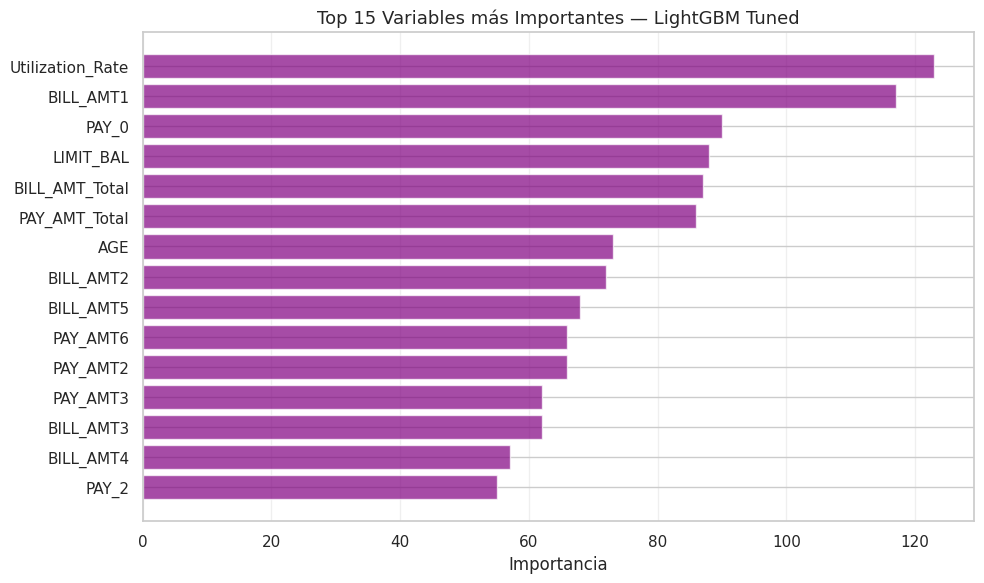

In [130]:
# Top 15 variables
top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feature_names[i] for i in indices[:top_n]][::-1],
    importances[indices[:top_n]][::-1],
    color='purple', alpha=0.7
)
ax.set_title('Top 15 Variables más Importantes — LightGBM Tuned', fontsize=13)
ax.set_xlabel('Importancia')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


**NOTA:** El gráfico de importancia de variables revela hallazgos muy relevantes que son consistentes con el análisis del EDA:

Top 5 variables:

- **Utilization_Rate (importancia=124)** : La variable engineered creada en el pipeline es la más predictiva del modelo. Confirma que la proporción del límite utilizado es el mejor indicador de riesgo crediticio. Un cliente al tope de su límite tiene alta probabilidad de default.

- BILL_AMT1 (importancia=117):  El saldo más reciente es el segundo predictor más importante, lo que tiene sentido ya que refleja la situación financiera actual del cliente.

- PAY_0 (importancia=91): El estado de pago más reciente confirma lo visto en el EDA: un solo mes de retraso dispara la probabilidad de default. Es la variable de comportamiento más predictiva.

- LIMIT_BAL (importancia=88):  A mayor límite de crédito, menor riesgo de default. Clientes con límites altos tienen mejor historial crediticio.

- BILL_AMT_Total y PAY_AMT_Total (importancia ~86):  Las otras dos variables engineered aparecen en el top 6, validando la decisión de crearlas. El comportamiento acumulado de 6 meses es más informativo que cualquier mes individual.

**Hallazgo notable sobre variables sensibles: SEX, EDUCATION y MARRIAGE fueron incluidas en el modelo pero no aparecen en el top 15 de variables importantes. Esto confirma empíricamente lo observado en el EDA: estas variables tienen escaso poder predictivo sobre el default.**

**Este resultado respalda una decisión que podría tomarse en una siguiente iteración: excluirlas del modelo sin sacrificar AUC, lo que reduciría el riesgo de sesgo demográfico. Se recomienda comparar el AUC con y sin estas variables como trabajo futuro.**



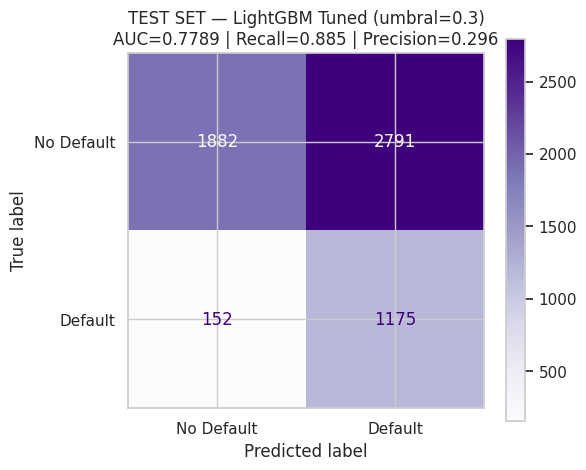

In [131]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_pred_test,
    display_labels=['No Default', 'Default'],
    cmap='Purples', ax=ax
)
ax.set_title(f'TEST SET — LightGBM Tuned (umbral=0.3)\n'
             f'AUC={auc_test:.4f} | Recall={rec_test:.3f} | Precision={prec_test:.3f}')
plt.tight_layout()
plt.show()

**NOTA:** En el conjunto de test, el modelo detecta 1,175 de 1,327 defaulters (recall ≈ 0.885), lo que demuestra una alta capacidad para identificar clientes con riesgo de incumplimiento. Sin embargo, también se generan 2,791 falsos positivos, lo que implica rechazar algunos clientes que sí pagarían. Este resultado refleja una estrategia que prioriza la detección de riesgo crediticio sobre la maximización de clientes aprobados.

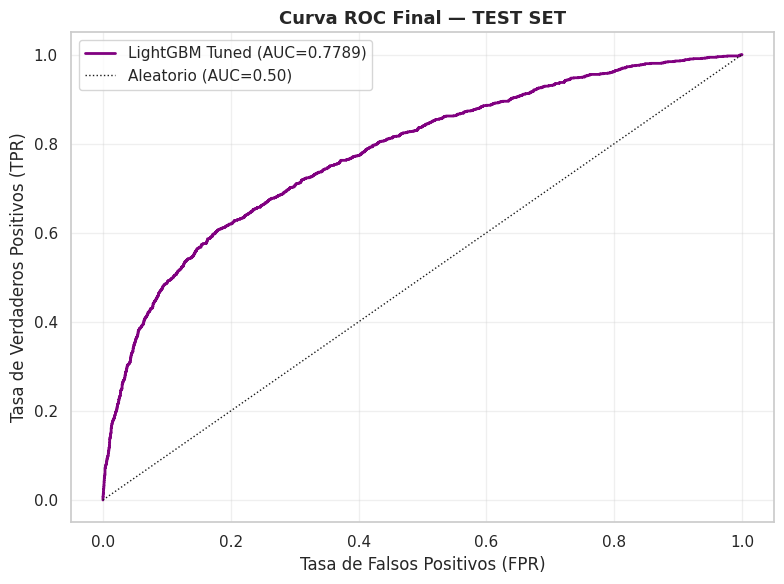

In [132]:
# Curva ROC final en TEST
fpr, tpr, _ = roc_curve(y_clf_test, y_prob_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='purple', linewidth=2,
        label=f'LightGBM Tuned (AUC={auc_test:.4f})')
ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC Final — TEST SET', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NOTA:** La curva ROC muestra el desempeño final del modelo LightGBM tuned en el conjunto de test, con un AUC = 0.7789, lo que indica una buena capacidad para distinguir entre clientes que harán default y aquellos que no. La curva se mantiene claramente por encima de la línea aleatoria (AUC = 0.5), confirmando que el modelo tiene capacidad predictiva significativa para el problema de riesgo crediticio.

In [133]:
nuevos_clientes = pd.DataFrame({
    'ID':        [99901,  99902],
    'LIMIT_BAL': [350000, 50000],
    'SEX':       [2,      1],
    'EDUCATION': [2,      3],
    'MARRIAGE':  [1,      2],
    'AGE':       [38,     27],
    'PAY_0':     [-1,     3],
    'PAY_2':     [-1,     2],
    'PAY_3':     [-1,     2],
    'PAY_4':     [-2,     1],
    'PAY_5':     [-2,     0],
    'PAY_6':     [-2,     0],
    'BILL_AMT1': [45000,  48000],
    'BILL_AMT2': [42000,  46000],
    'BILL_AMT3': [40000,  43000],
    'BILL_AMT4': [38000,  40000],
    'BILL_AMT5': [35000,  38000],
    'BILL_AMT6': [30000,  36000],
    'PAY_AMT2':  [42000,  1000],
    'PAY_AMT3':  [40000,  800],
    'PAY_AMT4':  [38000,  500],
    'PAY_AMT5':  [35000,  300],
    'PAY_AMT6':  [30000,  200],
})

# .transform() — el pipeline NO se re-entrena, usa lo aprendido en train
X_nuevos_prep  = pipeline_completo.transform(nuevos_clientes)
probabilidades = lgbm_tuned.predict_proba(X_nuevos_prep)[:, 1]
predicciones   = (probabilidades >= 0.3).astype(int)

iconos   = {0: " NO DEFAULT", 1: "  DEFAULT"}
decision = {0: "Aprobar crédito", 1: "Rechazar / revisar"}

resumen = pd.DataFrame({
    'Cliente':        ['Cliente 1 (bajo riesgo)', 'Cliente 2 (alto riesgo)'],
    'Prob. Default':  [f"{p:.1%}" for p in probabilidades],
    'Prediccion':     [iconos[p] for p in predicciones],
    'Decision':       [decision[p] for p in predicciones],
})
display(resumen)

,Cliente,Prob. Default,Prediccion,Decision
0,Cliente 1 (bajo riesgo),7.5%,NO DEFAULT,Aprobar crédito
1,Cliente 2 (alto riesgo),88.0%,DEFAULT,Rechazar / revisar


# **6. CONCLUSIONES Y RECOMENDACIONES**

## **CONCLUSIONES**

1.⁠ ⁠El historial de pagos es el principal predictor del riesgo crediticio

El análisis de importancia de variables muestra que los factores más influyentes para predecir el incumplimiento de pago están relacionados con el historial reciente de pagos del cliente, particularmente variables como PAY_0, PAY_2 y otros indicadores de retraso en pagos.

Esto indica que el comportamiento financiero reciente del cliente es un fuerte indicador de su comportamiento futuro. Desde la perspectiva del negocio, este resultado confirma una práctica común en el sector financiero: clientes con retrasos en pagos recientes presentan una probabilidad significativamente mayor de entrar en default en el futuro.

Este hallazgo sugiere que las instituciones financieras deberían dar mayor peso al historial de pagos en sus modelos de evaluación crediticia, incluso más que a variables sociodemográficas.

2.⁠ ⁠El modelo permite detectar la mayoría de los clientes riesgosos

Con un umbral de decisión de 0.3, el modelo LightGBM logra detectar 1,171 de 1,327 clientes que entrarán en default, alcanzando un recall de 0.882.

Esto significa que el modelo identifica aproximadamente el 88% de los clientes con riesgo de incumplimiento, lo cual es altamente valioso para la gestión del riesgo crediticio. Detectar estos clientes antes de otorgar crédito permite a las instituciones financieras:

reducir pérdidas asociadas a préstamos incobrables

mejorar la calidad de la cartera de crédito

implementar estrategias de mitigación de riesgo

Desde el punto de vista del negocio, un modelo con alto recall es particularmente útil cuando el costo de otorgar crédito a un cliente que no pagará es elevado.

3.⁠ ⁠Existe un trade-off entre control de riesgo y crecimiento del crédito

Aunque el modelo logra detectar la mayoría de los clientes riesgosos, también genera 2,759 falsos positivos, es decir, clientes que el modelo clasifica como riesgosos pero que en realidad sí pagarían.

Este resultado refleja un trade-off típico en modelos de riesgo crediticio: aumentar la capacidad de detectar clientes riesgosos puede implicar rechazar algunos clientes potencialmente buenos.

Desde una perspectiva estratégica, las instituciones financieras pueden ajustar el umbral de decisión del modelo dependiendo de sus objetivos:

umbral más bajo → mayor control de riesgo, pero menos créditos aprobados

umbral más alto → más clientes aprobados, pero mayor riesgo de incumplimiento

Esto significa que el modelo no solo sirve para predecir el riesgo, sino también como una herramienta para definir políticas de crédito alineadas con la estrategia de riesgo de la institución.

4.⁠ ⁠Variables sociodemográficas tienen menor influencia en la predicción

El análisis del modelo muestra que variables como SEX, EDUCATION y MARRIAGE tienen una menor importancia predictiva en comparación con variables financieras y de comportamiento de pago.

Esto sugiere que el modelo basa sus predicciones principalmente en patrones reales de comportamiento financiero, lo cual es positivo desde una perspectiva de equidad y ética en el uso de modelos de Machine Learning.

Desde el punto de vista regulatorio y ético, esto es relevante porque reduce el riesgo de que el modelo introduzca sesgos discriminatorios basados en características personales.

5.⁠ ⁠Valor del modelo para la toma de decisiones financieras

En conjunto, los resultados muestran que el modelo LightGBM puede utilizarse como una herramienta de apoyo para mejorar los procesos de evaluación crediticia. La combinación de modelos de clasificación y regresión permite:

identificar clientes con alto riesgo de default

estimar el comportamiento futuro de pagos

mejorar la asignación de límites de crédito

optimizar estrategias de cobranza preventiva

En conclusión, se logró desarrollar un modelo predictivo capaz de analizar el comportamiento financiero de los clientes de tarjetas de crédito y anticipar posibles situaciones de incumplimiento de pago. Los resultados muestran que el modelo LightGBM presenta un buen desempeño en la identificación de clientes con riesgo de default, así como en la estimación de los montos de pago futuros mediante el modelo de regresión. Esto evidencia que el uso de técnicas de Machine Learning puede contribuir a mejorar la evaluación del riesgo crediticio, permitiendo a las instituciones financieras tomar decisiones más informadas al momento de otorgar crédito, reducir posibles pérdidas por incumplimiento y optimizar la gestión de su cartera de clientes.

## **RECOMENDACIONES**

1.⁠ ⁠Utilizar el modelo como herramienta de apoyo en la evaluación crediticia

Se recomienda integrar el modelo LightGBM dentro del proceso de evaluación de solicitudes de crédito como una herramienta de apoyo para analistas de riesgo. El modelo puede utilizarse para estimar la probabilidad de incumplimiento de cada cliente y complementar el análisis tradicional realizado por la institución financiera.

Esto permitiría mejorar la consistencia y rapidez en la evaluación de clientes, especialmente cuando se manejan grandes volúmenes de solicitudes de crédito.

2.⁠ ⁠Ajustar el umbral de decisión según la estrategia de riesgo

El análisis mostró que con un umbral de 0.3 el modelo logra detectar la mayoría de los clientes que entrarán en default, pero también genera un número considerable de falsos positivos.

Por esta razón, se recomienda que las instituciones financieras ajusten el umbral de decisión del modelo según su estrategia de negocio, considerando el balance entre:

reducción del riesgo crediticio

crecimiento de la cartera de clientes

Por ejemplo:

umbrales más bajos pueden utilizarse en contextos económicos inciertos, donde se prioriza el control del riesgo

umbrales más altos pueden utilizarse cuando el objetivo es expandir el crédito

3.⁠ ⁠Incorporar el modelo en sistemas de monitoreo continuo de clientes

Además de utilizar el modelo para aprobar o rechazar solicitudes de crédito, se recomienda emplearlo para monitorear periódicamente el comportamiento de los clientes activos.

Esto permitiría identificar tempranamente clientes cuyo riesgo está aumentando, lo que facilitaría implementar medidas como:

reducción de límites de crédito

estrategias de cobranza preventiva

seguimiento personalizado del cliente

4.⁠ ⁠Evaluar periódicamente el desempeño del modelo

Los modelos de Machine Learning pueden perder precisión con el tiempo debido a cambios en el comportamiento financiero de los clientes o en las condiciones económicas.

Por esta razón, se recomienda realizar evaluaciones periódicas del desempeño del modelo, incluyendo:

recalibración del umbral de decisión

reentrenamiento del modelo con datos más recientes

monitoreo de métricas como AUC, recall y precision

Esto garantizará que el modelo continúe siendo confiable para la toma de decisiones.

5.⁠ ⁠Analizar el impacto de variables sensibles

Aunque las variables sociodemográficas no muestran alta importancia predictiva, se recomienda evaluar el impacto de su exclusión en futuras versiones del modelo.

Esto permitiría reducir aún más el riesgo de sesgos en las decisiones crediticias, promoviendo modelos más justos y alineados con principios de responsabilidad ética en el uso de inteligencia artificial.

6.⁠ ⁠Explorar mejoras en futuras versiones del modelo

Finalmente, se recomienda explorar mejoras adicionales que podrían incrementar el desempeño del modelo, tales como:

incorporar variables adicionales relacionadas con el comportamiento financiero del cliente

probar otros algoritmos avanzados de Machine Learning

utilizar técnicas de feature engineering más sofisticadas

implementar métodos de interpretabilidad del modelo para comprender mejor las predicciones

Estas mejoras podrían contribuir a construir modelos aún más robustos para la gestión del riesgo crediticio.